In [1]:
import time; t0 = time.time();
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import matplotlib.image as mpimg
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (2.5,2.5)

import itertools
import upsetplot as us
import seaborn as sns
import scipy
import scipy.stats as ss
import statsmodels.api as sm
import statsmodels.formula.api as smf
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="upsetplot")

print(mpl.__version__, pd.__version__)

3.10.9 2.3.3


# Data loading

In [2]:
anno_f = 'release/ml-burden.variants.parquet'
sumstat_f = 'release/ml-burden.sumstats.parquet'

genebass_f = 'data/genebass_burden_associations_1e-4.tsv.gz'
s_het_f = 'data/s_het_estimates.genebayes.tsv'
loeuf_f = 'data/gnomad.v4.1.constraint_metrics.tsv'


ANNO_ORDER = ['ESM1B','AM','GPN','CADD16','CADD17']
TEST_ORDER1 = ['BURDEN','SKAT-O','SKAT','ACATV']
TEST_ORDER2 = ['COAST_O','BURDEN-SBAT','BURDEN-ACAT','SKATO-ACAT','ACATV-ACAT','GENE_P']
TEST_ORDER = TEST_ORDER1 + TEST_ORDER2
GROUP_ORDER = ['Ocular','Pulmonary','Anthropometric','Height']

## Variant scores

In [3]:
vs = pd.read_parquet(anno_f)

# this polarizes these two to be like the other three
vs['-gpn'] = -vs['gpn']
vs['-esm1b_pred'] = -vs['esm1b_pred']

# convenience
vs['mis'] = vs['conseq'].str.contains('missense_variant')
vs['syn'] = vs['conseq'].str.contains('synonymous_variant')
vs['mis_str'] = vs['mis'].apply(lambda mis: 'Missense' if mis else 'Synonymous')

display(
    vs['conseq'].value_counts(), 
    vs[['mis','syn']].value_counts(), 
    vs.columns, 
    vs.tail()
)

conseq
missense_variant                                    6163737
synonymous_variant                                  3040657
missense_variant,splice_region_variant               173567
splice_region_variant,synonymous_variant              80411
splice_donor_5th_base_variant,synonymous_variant          2
splice_donor_region_variant,synonymous_variant            1
missense_variant,splice_donor_5th_base_variant            1
missense_variant,splice_donor_region_variant              1
start_lost,synonymous_variant                             1
Name: count, dtype: int64

mis    syn  
True   False    6337306
False  True     3121072
Name: count, dtype: int64

Index(['chrom', 'pos', 'varid', 'ref', 'alt', 'maf', 'obs_ct', 'transcript_id',
       'aa', 'am_pathogenicity', 'am_class', 'gene_id', 'feature', 'conseq',
       'biotype', 'symbol', 'impact', 'gpn', 'cadd16_raw', 'cadd16_phred',
       'cadd17_raw', 'cadd17_phred', 'esm1b_pred', 'gene_name', 'TSS',
       'am_annot', 'esm_annot', 'gpn_annot', 'cadd16_annot', 'cadd17_annot',
       'coast_am_score', 'coast_esm_score', 'coast_gpn_score',
       'coast_cadd16_score', 'coast_cadd17_score', '-gpn', '-esm1b_pred',
       'mis', 'syn', 'mis_str'],
      dtype='object')

,chrom,pos,varid,ref,alt,maf,obs_ct,transcript_id,aa,am_pathogenicity,...,coast_am_score,coast_esm_score,coast_gpn_score,coast_cadd16_score,coast_cadd17_score,-gpn,-esm1b_pred,mis,syn,mis_str
9458432,22,50777967,22_50777967_A_C,A,C,0.000001,821052,ENST00000395598,F41C,0.9782,...,3,3,3,3,3,9.81,8.894,True,False,Missense
9458433,22,50777972,22_50777972_C_T,C,T,0.000000,821054,ENST00000354869,None,0.0000,...,1,1,2,2,2,3.46,-0.000,False,True,Synonymous
9458434,22,50777972,22_50777972_C_A,C,A,0.000005,821054,ENST00000395598,E39D,0.9358,...,3,2,3,3,3,9.82,7.108,True,False,Missense
9458435,22,50777975,22_50777975_C_T,C,T,0.000015,821054,ENST00000395598,M38I,0.6980,...,3,1,3,3,3,8.78,2.959,True,False,Missense
9458436,22,50777977,22_50777977_T_C,T,C,0.000004,821054,ENST00000395598,M38V,0.1561,...,1,2,2,2,2,4.67,3.078,True,False,Missense


### Unique variant set

In [4]:
v_uniq = pd.DataFrame(index = vs['varid'].unique())

vs_gbv = vs.groupby('varid')
cs2lab = dict(zip(range(1,4), ['ben','mod','del']))

for score in tqdm(['cadd16','cadd17','am','esm','gpn']):
    v_uniq[score.upper() + ('1B' if score == 'esm' else '')] = vs_gbv['coast_' + score + '_score'].max().apply(cs2lab.get)

v_uniq['maf'] = vs_gbv['maf'].first()
v_uniq['mis'] = vs_gbv['mis'].max()
v_uniq['mis_str'] = v_uniq['mis'].apply(lambda mis: 'Missense' if mis else 'Synonymous')

display(v_uniq.head(), v_uniq.shape)

100%|██████████| 5/5 [00:28<00:00,  5.67s/it]


,CADD16,CADD17,AM,ESM1B,GPN,maf,mis,mis_str
1_925946_C_G,del,del,del,del,del,0.000000,True,Missense
1_925947_C_T,mod,mod,ben,ben,mod,0.000009,False,Synonymous
1_925948_A_C,del,del,del,del,del,0.000062,True,Missense
1_925949_A_C,del,del,del,del,del,0.000000,True,Missense
1_925950_G_C,del,del,del,del,del,0.000001,True,Missense


(9335541, 8)

### Label thresholds

In [5]:
for score, annot in {
    'am_pathogenicity':'am_annot', 
    'esm1b_pred':'esm_annot', 
    'gpn':'gpn_annot', 
    'cadd16_phred':'cadd16_annot', 
    'cadd17_phred':'cadd17_annot'
}.items():
    
    print(annot)
    for level in ['ben','mod','del']:
        print(
            level,
            vs.loc[vs[annot] == level, score].apply(
                np.abs if 'esm' in score or 'gpn' in score else lambda x: x
            ).quantile([0, 1]).values
        )

am_annot
ben [0.   0.34]
mod [0.34  0.564]
del [0.564 1.   ]
esm_annot
ben [0.    2.999]
mod [3. 8.]
del [ 8.001 22.299]
gpn_annot
ben [0.   2.99]
mod [3. 8.]
del [ 8.01 13.99]
cadd16_annot
ben [1.000e-03 9.999e+00]
mod [10.   19.99]
del [20. 63.]
cadd17_annot
ben [1.000e-03 9.999e+00]
mod [10.   19.99]
del [20. 65.]


## Summary statistics

In [6]:
# summary stats
sumstats = pd.read_parquet(sumstat_f).dropna(subset=['anno'])

sumstats['anno'] = sumstats['anno'].str.upper()
sumstats['anno'] = sumstats['anno'].replace({'ESM':'ESM1B'})

pheno_groups = {
    'height': 'Height',
    'weight': 'Anthropometric',
    'bmi': 'Anthropometric',
    'fev1': 'Pulmonary',
    'fvc': 'Pulmonary',
    'fev1_fvc_ratio': 'Pulmonary',
    'iop-R': 'Ocular',
    'iop-L': 'Ocular',
    'iop-G-R': 'Ocular',
    'iop-G-L': 'Ocular',
    'ch-R': 'Ocular',
    'ch-L': 'Ocular',
    'crf-R': 'Ocular',
    'crf-L': 'Ocular'
}

sumstats['pheno_group'] = sumstats['pheno'].apply(pheno_groups.get)

sumstats.head(3)

,CHROM,GENPOS,GENE,gene_id,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,pheno,anno,mask,test_keys,pop_sample,pheno_group
0,1.0,925946.0,SAMD11,ENSG00000187634,NaN,282956,ADD-ACATV,NaN,NaN,0.801595,0.431075,fev1_fvc_ratio,CADD16,del,ACATV,related,Pulmonary
1,1.0,925946.0,SAMD11,ENSG00000187634,NaN,282956,ADD-SKAT,NaN,NaN,1.944740,0.787401,fev1_fvc_ratio,CADD16,del,SKAT,related,Pulmonary
2,1.0,925946.0,SAMD11,ENSG00000187634,NaN,282956,ADD-SKATO-ACAT,NaN,NaN,1.909740,0.777305,fev1_fvc_ratio,CADD16,del,SKAT-O,related,Pulmonary


## Gene constraint

In [7]:
s_het = pd.read_csv(s_het_f, sep='\t')
lower_s, upper_s = s_het.query('ensg.isin(@sumstats.gene_id)')['post_mean'].quantile([0.25, 0.75])
print(lower_s, upper_s)

s_het_d = dict(s_het[['ensg','post_mean']].values)
for df in [sumstats, vs]:
    df['s_het'] = df['gene_id'].apply(s_het_d.get)
    df['1/s_het'] = 1./df['s_het']
    df['s_het_high'] = (df['s_het'] > upper_s)
    df['s_het_low']  = (df['s_het'] < lower_s)

0.00216671 0.0489018


In [8]:
loeuf = pd.read_csv(loeuf_f, sep='\t')
lower_l, upper_l = loeuf.query('mane_select & gene_id.isin(@sumstats.gene_id)')['lof.oe_ci.upper'].quantile([0.25, 0.75])
print(lower_l, upper_l)

loeuf_d = dict(loeuf[['gene_id','lof.oe_ci.upper']].values)
for df in [sumstats, vs]:
    df['loeuf'] = df['gene_id'].apply(loeuf_d.get) 
    df['1/loeuf'] = 1./df['loeuf']
    df['loeuf_high'] = (df['loeuf'] > upper_l)
    df['loeuf_low']  = (df['loeuf'] < lower_l)

0.647 1.2767499999999998


In [9]:
scores = ['-esm1b_pred', 'am_pathogenicity', '-gpn', 'cadd16_phred', 'cadd17_phred', 's_het', '1/loeuf']

v_uniq[scores] = vs.set_index('varid')[scores].abs().groupby('varid').max()

## LoF burden tests

In [10]:
lofs = pd.read_csv(genebass_f, sep='\t')

pheno2code = {
    'bmi': '21001',
    'ch-L': '5264',
    'ch-R': '5256',
    'crf-L': '5265',
    'crf-R': '5257',
    'fev1': '3063',
    'fev1_fvc_ratio': '20258',
    'fvc': '3062',
    'height': '50',
    'iop-G-L': '5263', 
    'iop-G-R': '5255',
    'iop-L': '5262',
    'iop-R': '5254',
    'weight': '21002',
}

lofs.tail()

,gene_id,gene_symbol,annotation,interval,n_cases,n_controls,heritability,inv_normalized,trait_type,phenocode,...,Pvalue,Pvalue_Burden,Pvalue_SKAT,BETA_Burden,SE_Burden,Pvalue.NA,Pvalue_Burden.NA,Pvalue_SKAT.NA,BETA_Burden.NA,SE_Burden.NA
125301,ENSG00000288645,AC084756.2,missense|LC,chr15:50648618-50686660,1445,393338.0,0.097158,False,categorical,20002,...,0.000031,0.000235,0.000050,0.087122,0.023687,1.053431e-10,2.382998e-06,9.745560e-11,0.143261,0.030366
125302,ENSG00000288645,AC084756.2,missense|LC,chr15:50648618-50686660,254,394529.0,0.000000,False,categorical,20003,...,0.000094,0.001137,0.000090,0.156282,0.048024,1.207478e-13,4.936487e-07,8.581952e-14,0.375890,0.074748
125303,ENSG00000288645,AC084756.2,missense|LC,chr15:50648618-50686660,298,394543.0,0.086570,False,categorical,41200,...,0.000098,0.001836,0.000063,0.145954,0.046848,8.319337e-17,4.319005e-06,1.687980e-17,0.317495,0.069090
125304,ENSG00000288645,AC084756.2,missense|LC,chr15:50648618-50686660,256,394585.0,0.000000,False,categorical,41200,...,0.000031,0.000077,0.000116,0.168851,0.042695,4.136805e-26,5.582762e-12,7.499139e-26,0.512401,0.074370
125305,ENSG00000288645,AC084756.2,pLoF|missense|LC,chr15:50648618-50686660,1445,393338.0,0.097158,False,categorical,20002,...,0.000006,0.000040,0.000011,0.083134,0.020232,1.126236e-13,4.789474e-09,2.527502e-12,0.168753,0.028825


# Computation

## Genomic inflation and discovery rate

In [11]:
burden_ixs = ['test_keys','pop_sample','anno','mask','pheno','pheno_group']

sumstats_gbt = sumstats.groupby(burden_ixs)

burden = pd.DataFrame()

burden[r'$\lambda_{GC}$'] = sumstats_gbt['CHISQ'].median().divide(
    scipy.stats.chi2(df = 1).isf(0.5)
)

burden['lambda_gc'] = burden[r'$\lambda_{GC}$']

for p_star in [0.01, 0.001, 0.0001]:
    burden['(p < {})'.format(p_star)] = sumstats_gbt['LOG10P'].agg(
        lambda b: (b > -np.log10(p_star)).sum()
    )

burden = burden.reset_index()
burden['Annotation'] = burden['anno']
burden['Test'] = burden['test_keys']
burden['Population'] = burden['pop_sample']
burden['Trait'] = burden['pheno']
burden['Trait category'] = burden['pheno_group']

burden.tail()

,test_keys,pop_sample,anno,mask,pheno,pheno_group,$\lambda_{GC}$,lambda_gc,(p < 0.01),(p < 0.001),(p < 0.0001),Annotation,Test,Population,Trait,Trait category
2515,SKATO-ACAT,unrelated,GPN,bdm,iop-G-L,Ocular,1.036932,1.036932,205,19,4,GPN,SKATO-ACAT,unrelated,iop-G-L,Ocular
2516,SKATO-ACAT,unrelated,GPN,bdm,iop-G-R,Ocular,1.017608,1.017608,196,33,5,GPN,SKATO-ACAT,unrelated,iop-G-R,Ocular
2517,SKATO-ACAT,unrelated,GPN,bdm,iop-L,Ocular,1.015283,1.015283,187,17,2,GPN,SKATO-ACAT,unrelated,iop-L,Ocular
2518,SKATO-ACAT,unrelated,GPN,bdm,iop-R,Ocular,0.984636,0.984636,189,23,3,GPN,SKATO-ACAT,unrelated,iop-R,Ocular
2519,SKATO-ACAT,unrelated,GPN,bdm,weight,Anthropometric,1.254538,1.254538,392,75,22,GPN,SKATO-ACAT,unrelated,weight,Anthropometric


## Distributional calibration and power

In [12]:
# wasserstein distances
w1 = pd.concat(
    [
        # calibration error
        sumstats.query('mask == "ben"').groupby(
            ['anno','test_keys','pop_sample','pheno']
        )['CHISQ'].apply(
            lambda x2: 
            np.mean(np.abs( 
                np.sort(x2) - # faster than scipy.stats.wasserstein_distance  
                np.sort(scipy.stats.chi2(df = 1).ppf(np.arange(len(x2)) / len(x2) + 1/(2*len(x2))))
            ))       
        ).rename('Calibration error'),
        
        # signal separation
        sumstats.query('mask == "ben" | mask == "del"').groupby(
            ['anno','test_keys','pop_sample','pheno']
        ).apply(
            lambda df: scipy.stats.wasserstein_distance(
                np.sort(df.query('mask == "del" & LOG10P >= 3')['CHISQ']), 
                np.sort(
                    df.loc[
                        df['gene_id'].isin(
                            df.query('mask == "del" & LOG10P >= 3')['gene_id']
                        ) & (df['mask'] == "ben")
                    , 
                        'CHISQ'
                    ]
                )
            )
        ).rename('Signal separation')
    ], 
    axis = 1
).reset_index()

w1['pheno_group'] = w1['pheno'].apply(pheno_groups.get)
w1['Annotation'] = w1['anno']
w1['Test'] = w1['test_keys']
w1['Population'] = w1['pop_sample']
w1['test_keys_cat'] = pd.Categorical(w1['test_keys'], ordered = True, categories = TEST_ORDER)
w1 = w1.sort_values('test_keys_cat')

w1.head(3)

/tmp/slurmjob.58107830/ipykernel_1775164/1049700988.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


,anno,test_keys,pop_sample,pheno,Calibration error,Signal separation,pheno_group,Annotation,Test,Population,test_keys_cat
279,CADD17,BURDEN,unrelated,weight,0.056377,15.352512,Anthropometric,CADD17,BURDEN,unrelated,BURDEN
368,ESM1B,BURDEN,related,crf-R,0.028790,13.259384,Ocular,ESM1B,BURDEN,related,BURDEN
367,ESM1B,BURDEN,related,crf-L,0.037494,13.789252,Ocular,ESM1B,BURDEN,related,BURDEN


## Constraint enrichment

In [13]:
burden = burden.set_index(burden_ixs)

for p_star in [0.01, 0.001, 0.0001]:
    for name, stat in zip([r'$s_\text{het}$', 'LOEUF'], ['s_het', 'loeuf']):
        for hl in ['high','low']:                
            burden['{0} {1} (p < {2})'.format(
                hl, stat, p_star
            )] = sumstats.query(
                stat+'_'+hl
            ).groupby(
                burden_ixs
            )['LOG10P'].agg(
                lambda b: (b > -np.log10(p_star)).sum()
            )

burden = burden.reset_index()
burden.tail(2)

,test_keys,pop_sample,anno,mask,pheno,pheno_group,$\lambda_{GC}$,lambda_gc,(p < 0.01),(p < 0.001),...,high loeuf (p < 0.01),low loeuf (p < 0.01),high s_het (p < 0.001),low s_het (p < 0.001),high loeuf (p < 0.001),low loeuf (p < 0.001),high s_het (p < 0.0001),low s_het (p < 0.0001),high loeuf (p < 0.0001),low loeuf (p < 0.0001)
2518,SKATO-ACAT,unrelated,GPN,bdm,iop-R,Ocular,0.984636,0.984636,189,23,...,60,37,6,5,7,3,0,1,0,0
2519,SKATO-ACAT,unrelated,GPN,bdm,weight,Anthropometric,1.254538,1.254538,392,75,...,101,77,31,13,14,18,10,1,4,6


In [14]:
burden_gbt = burden.groupby(burden_ixs[:4])

enrich = pd.DataFrame()

for p_star in [0.01, 0.001, 0.0001]:

    enrich['No. of gene-trait pairs (p < {})'.format(p_star)] = burden_gbt['(p < {})'.format(p_star)].sum()
    
    enrich['LoF-Intolerant Enrichment ({0}, {1})'.format(r'$s_{het}$', p_star)] = \
        burden_gbt['high s_het (p < {})'.format(p_star)].sum().divide(
            burden_gbt['low s_het (p < {})'.format(p_star)].sum()
        )
    
    enrich['LoF-Intolerant Enrichment (LOEUF, {})'.format(p_star)] = \
        burden_gbt['low loeuf (p < {})'.format(p_star)].sum().divide(
            burden_gbt['high loeuf (p < {})'.format(p_star)].sum()
        )

enrich['LoF-Intolerant Enrichment ({0})'.format(r'$s_{het}$')] = enrich['LoF-Intolerant Enrichment ({0}, {1})'.format(r'$s_{het}$', p_star)]
enrich['LoF-Intolerant Enrichment (LOEUF)'] = enrich['LoF-Intolerant Enrichment (LOEUF, {})'.format(p_star)]

enrich = enrich.reset_index()
enrich.tail(2)

,test_keys,pop_sample,anno,mask,No. of gene-trait pairs (p < 0.01),"LoF-Intolerant Enrichment ($s_{het}$, 0.01)","LoF-Intolerant Enrichment (LOEUF, 0.01)",No. of gene-trait pairs (p < 0.001),"LoF-Intolerant Enrichment ($s_{het}$, 0.001)","LoF-Intolerant Enrichment (LOEUF, 0.001)",No. of gene-trait pairs (p < 0.0001),"LoF-Intolerant Enrichment ($s_{het}$, 0.0001)","LoF-Intolerant Enrichment (LOEUF, 0.0001)",LoF-Intolerant Enrichment ($s_{het}$),LoF-Intolerant Enrichment (LOEUF)
178,SKATO-ACAT,unrelated,ESM1B,bdm,4482,1.330526,0.663462,967,1.706897,0.958140,369,1.815385,1.061728,1.815385,1.061728
179,SKATO-ACAT,unrelated,GPN,bdm,4472,1.221000,0.658946,1009,1.575758,0.861925,344,2.188679,0.938272,2.188679,0.938272


## Paired trait replication

In [15]:
pheno_pairs = {
    ('ch-R','ch-L'): 'Ocular', 
    ('crf-R','crf-L'): 'Ocular',
    ('iop-R','iop-L'): 'Ocular',
    ('iop-G-R','iop-G-L'): 'Ocular',
    ('fev1', 'fev1_fvc_ratio'): 'Pulmonary',
    ('fev1_fvc_ratio', 'fvc'): 'Pulmonary',
    ('weight','bmi'): 'Anthropometric',
    ('bmi','height'): 'Anthropometric',
}

In [16]:
gb = sumstats.query(
    '(mask == "del")'
).sort_values(
    'LOG10P',
    ascending = False
).groupby(
    ['test_keys', 'pop_sample','anno']
)

cumul_enrich = pd.concat(
    [
        gb.apply(
            lambda row: (row['mask']).notnull().cumsum(),
            include_groups = False,
        ).rename('top_k'),
        
        gb.apply(
            lambda row: row['s_het_high'].cumsum() / row['s_het_low'].cumsum(),
            include_groups = False,
        ).rename('s_het_enrich'),
        
        gb.apply(
            lambda row: row['loeuf_low'].cumsum() / row['loeuf_high'].cumsum(),
            include_groups = False,
        ).rename('loeuf_enrich'),
    ],
    axis=1
)
                         
cumul_enrich.head()

top_k  s_het_enrich  loeuf_enrich
test_keys pop_sample anno                                            
ACATV     related    AM   12593743      1           inf           inf
                          12509431      2           inf           inf
                          12634388      3           inf           inf
                          12694051      4           inf           inf
                          12638804      5           inf           inf

In [17]:
gb2 = sumstats.query(
    '(mask == "bdm")'
).sort_values(
    'LOG10P',
    ascending = False
).groupby(
    ['test_keys', 'pop_sample','anno']
)

cumul_enrich2 = pd.concat(
    [
        gb2.apply(
            lambda row: (row['mask'] == "bdm").cumsum(),
            include_groups = False,
        ).rename('top_k'),
        
        gb2.apply(
            lambda row: row['s_het_high'].cumsum() / row['s_het_low'].cumsum(),
            include_groups = False,
        ).rename('s_het_enrich'),
        
        gb2.apply(
            lambda row: row['loeuf_low'].cumsum() / row['loeuf_high'].cumsum(),
            include_groups = False,
        ).rename('loeuf_enrich'),
    ],
    axis=1
)
                         
cumul_enrich2.head()

top_k  s_het_enrich  loeuf_enrich
test_keys  pop_sample anno                                            
ACATV-ACAT related    AM   12634402      1           NaN           NaN
                           12719435      2           inf           inf
                           12593757      3           inf           inf
                           12588042      4           inf           inf
                           12509445      5           inf           inf

In [18]:
# count
hits = sumstats.query(
    '(mask == "del" | mask == "bdm") & LOG10P >= 4 & pop_sample == "unrelated"'
).groupby(
    ['test_keys','anno','mask','gene_id']
)['pheno'].sum().apply(
    lambda s: sum(a in s and b in s for (a,b) in pheno_pairs.keys())
).reset_index().groupby(
    ['test_keys','anno','mask']
)['pheno'].sum().rename('total')

# temporary
q = sumstats.query(
    '(mask == "del" | mask == "bdm") & LOG10P >= 4 & pop_sample == "unrelated"'
).groupby(
    ['test_keys','anno','mask','pheno']
)['gene_id'].agg(set).reset_index()

# iou
ious = pd.concat(
    [
        pd.concat([
            q.loc[(q['pheno'] == l)].drop(
                columns='pheno'
            ).set_index(
                ['test_keys','anno','mask']
            ).rename(
                columns={'gene_id':l}
            ),
        
            q.loc[(q['pheno'] == r)].drop(
                columns='pheno'
            ).set_index(
                ['test_keys','anno','mask']
            ).rename(
                columns={'gene_id':r}
            ),
        ], axis=1).apply(
            lambda row: len(row[l] & row[r]) / len(row[l] | row[r]) 
                if type(row[l]) == set and type(row[r]) == set 
            else 0, 
            axis=1
        ).rename(
            ':'.join([r, l])
        ) 
        for (r,l) in pheno_pairs.keys()
    ], axis=1
)
ious['iou'] = ious[[':'.join(k) for k in pheno_pairs.keys()]].mean(axis=1)

traits = pd.concat([hits, ious], axis=1).reset_index()

traits['primary'] = (traits['mask'] == 'del')

traits.head()

,test_keys,anno,mask,total,ch-R:ch-L,crf-R:crf-L,iop-R:iop-L,iop-G-R:iop-G-L,fev1:fev1_fvc_ratio,fev1_fvc_ratio:fvc,weight:bmi,bmi:height,iou,primary
0,ACATV,AM,del,34,0.000000,0.400000,0.166667,0.125000,0.0,0.028571,0.235294,0.000000,0.119442,True
1,ACATV,CADD16,del,64,0.181818,0.384615,0.166667,0.200000,0.0,0.016667,0.217391,0.006289,0.146681,True
2,ACATV,CADD17,del,61,0.250000,0.384615,0.333333,0.250000,0.0,0.017241,0.240000,0.006289,0.185185,True
3,ACATV,ESM1B,del,25,0.000000,0.285714,0.333333,0.285714,0.0,0.035714,0.461538,0.000000,0.175252,True
4,ACATV,GPN,del,25,0.250000,0.333333,0.250000,0.142857,0.0,0.040000,0.125000,0.000000,0.142649,True


## LoF burden test replication

In [19]:
reps = pd.DataFrame(index = sumstats.query('(mask == "del" | mask == "bdm")')[['anno','test_keys','mask']].value_counts().index)

s1 = sumstats.query('(LOG10P >= 4) & (pop_sample == "unrelated") & (mask == "del" | mask == "bdm")')

for pheno,code in pheno2code.items():
    if code in lofs['phenocode'].values:
        lof_genebass_genes = lofs.query('phenocode == @code & annotation == "pLoF"')['gene_symbol'].unique()
        print(pheno, len(lof_genebass_genes))
    else:
        continue
    
    s2 = s1.query('(pheno == @pheno)').groupby(['anno','test_keys','mask'])
    
    reps[pheno + '_overlap_n'] = s2['GENE'].apply(lambda v: v.isin(lof_genebass_genes).sum())
    reps[pheno + '_overlap_rate'] = s2['GENE'].apply(lambda v: v.isin(lof_genebass_genes).sum() / len(v))

reps['total'] = reps.iloc[:,[0,2,4,6,8]].sum(axis=1)
reps['iou'] = reps.iloc[:,[1,3,5,7,9]].mean(axis=1)
reps = reps.reset_index()

reps.iloc[:5,[0,1,2,-2,-1]]

bmi 19
fev1 64
fvc 79
height 175
weight 40


,anno,test_keys,mask,total,iou
0,AM,ACATV-ACAT,bdm,34,0.072399
1,AM,BURDEN-ACAT,bdm,43,0.139629
2,AM,SKATO-ACAT,bdm,41,0.067212
3,AM,BURDEN-SBAT,bdm,46,0.170810
4,AM,GENE_P,bdm,49,0.087390


# Drawings

## Figure 3A

0.46965937950874453
0.44059290571374465


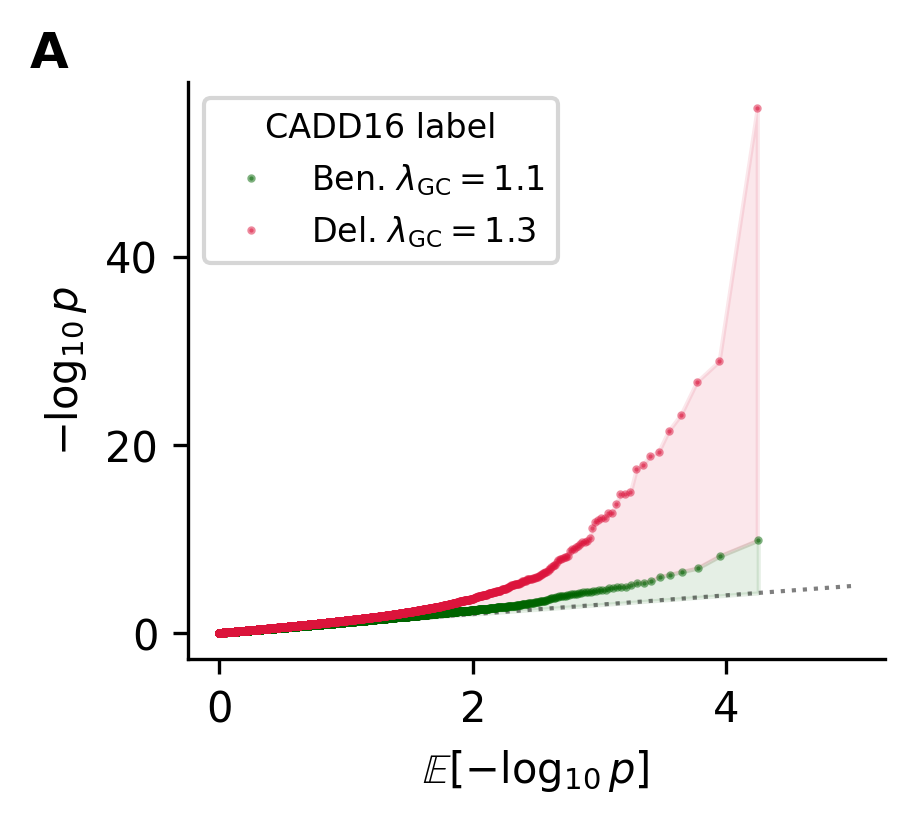

In [20]:
fig, ax = plt.subplots(1, 1, figsize = (3, 2.5));

ax.plot([0,5],[0,5],'k:',alpha=0.5,linewidth=1);

anno, test, pheno = 'CADD16','BURDEN','height'

b = sumstats.query(
    'anno == @anno & test_keys == @test & pop_sample == "unrelated" & pheno == @pheno & mask == "ben"'
)
d = sumstats.query(
    'anno == @anno & test_keys == @test & pop_sample == "unrelated" & pheno == @pheno & mask == "del"'
)
x_b = -np.log10(1/b.shape[0] + np.linspace(0, 1, b.shape[0]))
x_d = -np.log10(1/d.shape[0] + np.linspace(0, 1, d.shape[0]))

for mask, df in zip(['Ben.', 'Del.'], [b,d]):

    if mask == 'mod':
        continue

    ax.plot(
        -np.log10(1/df.shape[0] + np.linspace(0, 1, df.shape[0])),
        df['LOG10P'].sort_values()[::-1],
        '.',
        color = 'darkgreen' if mask == 'Ben.' else 'crimson',
        alpha = 0.5,
        ms = 2,
        label = '{0} {1}{2:.1f}'.format(mask, r'$\lambda_\text{GC}=$', (df['CHISQ'].median() / 0.455)),
    );
    print(10**-df['LOG10P'].median())

ax.fill_between(
    x_d,
    b['LOG10P'].sort_values()[::-1].iloc[:d.shape[0]],
    d['LOG10P'].sort_values()[::-1],
    color = 'crimson',
    alpha = 0.1,
    interpolate=True,
);
ax.fill_between(
    x_b,
    x_b,
    b['LOG10P'].sort_values()[::-1],
    color = 'darkgreen',
    alpha = 0.1,
    interpolate=True,
)
    

ax.legend(loc='upper left', title=anno + ' label', fontsize=8, title_fontsize=8);
#ax.set_title(' '.join([pheno, test.lower(), 'test']).title(), fontsize=10);
fig.text(-0.05, 0.95, 'A', ha='left', va='top', fontsize=12, fontweight='bold')

ax.set_xlabel(r'$\mathbb{E}[-\log_{10}p]$');
ax.set_ylabel(r'$-\log_{10}p$');
sns.despine();

fig.savefig('png/Fig3A.png', bbox_inches='tight');

## Wasserstein scenarios

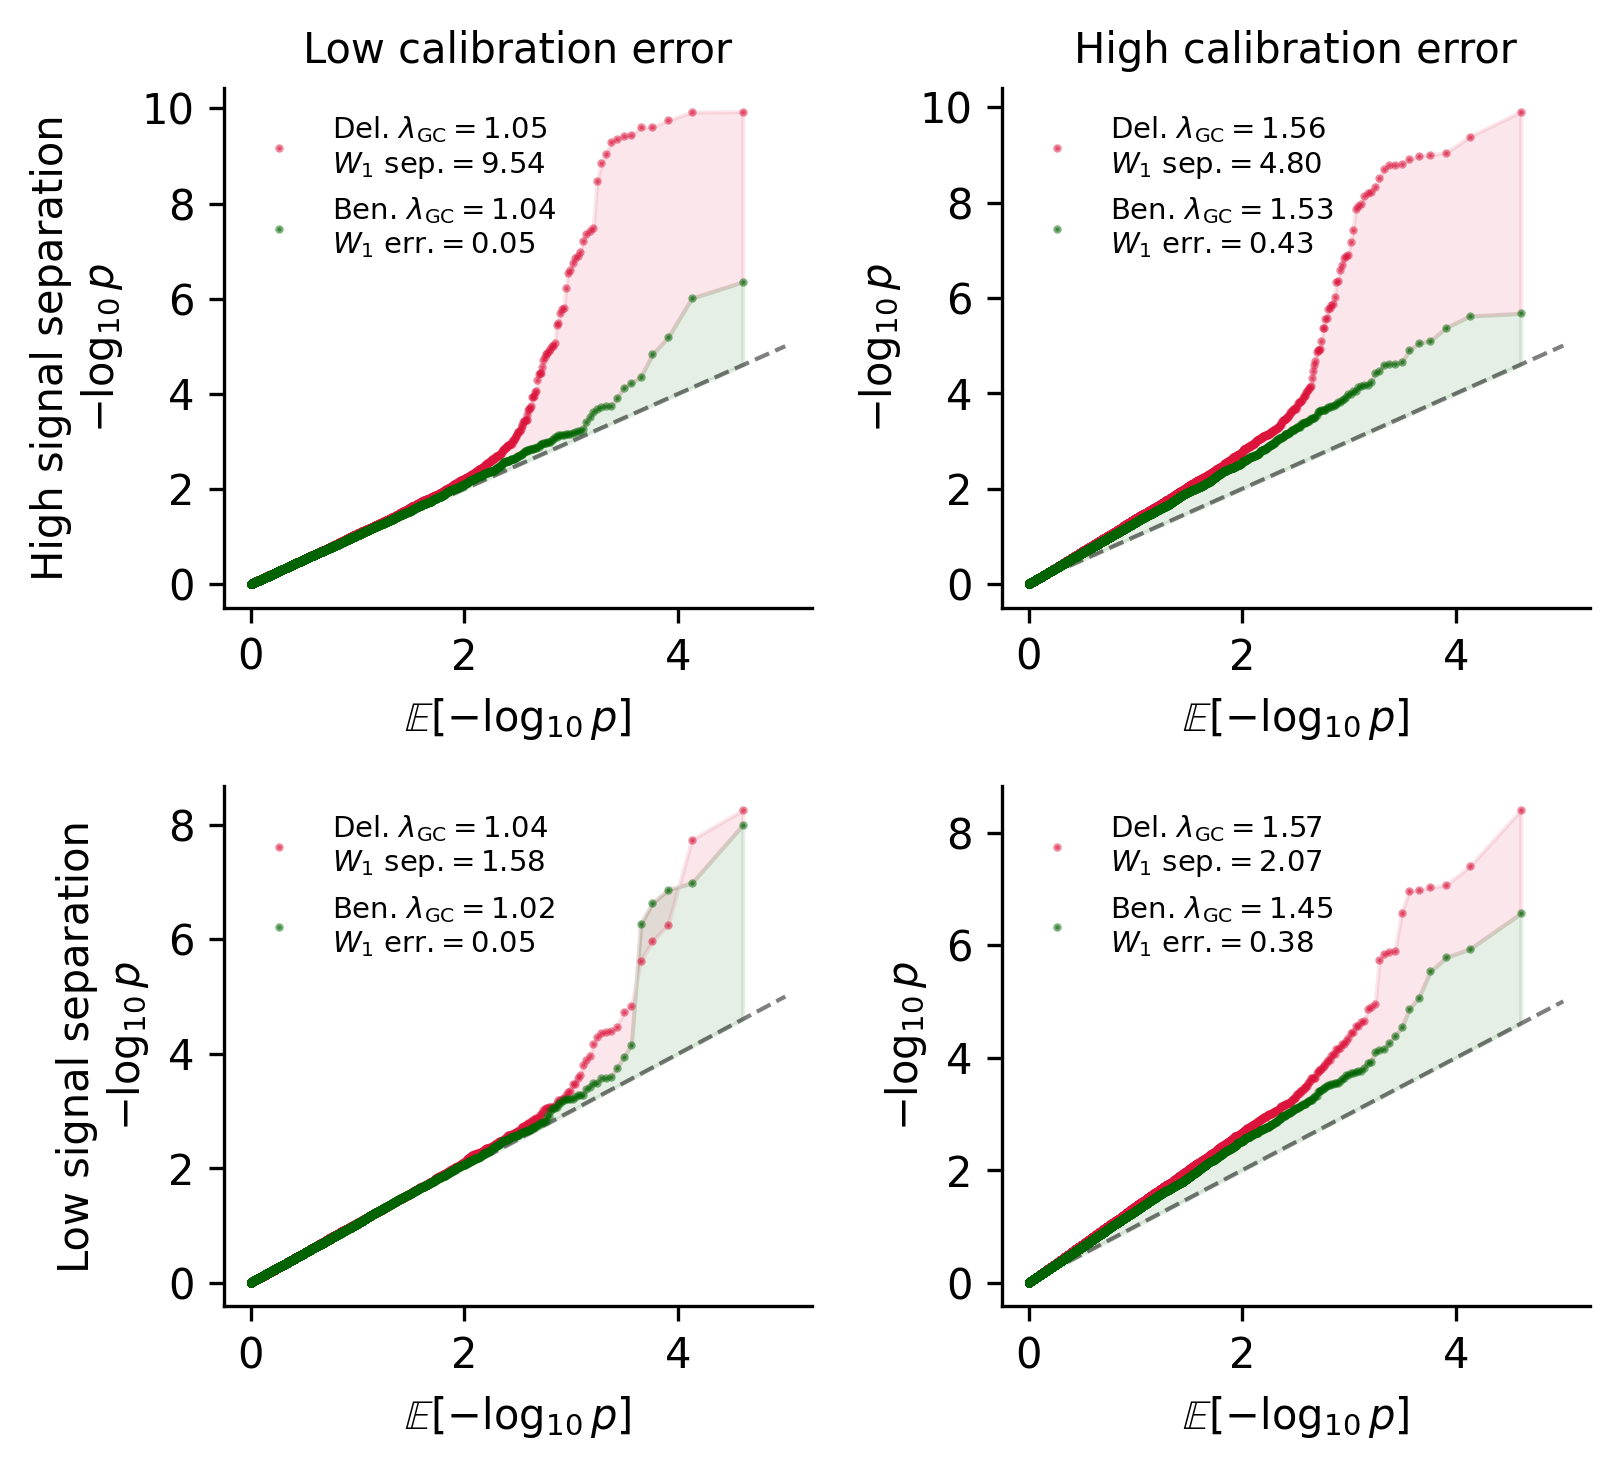

In [21]:
fig, axs = plt.subplots(2, 2, figsize = (5.5, 5));

m = 20000
e_p = -np.log10(1/(2*m) + np.linspace(0, 1 - 1/(2*m), m))


ax = axs[1,0]
ax.set_ylabel('Low signal separation\n' + r'$-\log_{10}p$');
ax.set_xlabel(r'$\mathbb{E}[-\log_{10}p]$');# + '\nLow calibration error');

b_p = -np.log10(np.sort(
    np.hstack([
        ss.chi2(df=1).sf(ss.ncx2(df=1, nc=0.04).rvs(size=m - 10)),
        10**np.random.uniform(-2, -8, size=10)
    ])
))
d_p = -np.log10(np.sort(
    np.hstack([
        ss.chi2(df=1).sf(ss.ncx2(df=1, nc=0.05).rvs(size=m - 10)),
        10**np.random.uniform(-3, -8.5, size=10)
    ])
))
w1e = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p), ss.chi2(df=1).isf(10**-e_p))
w1s = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p[d_p > 3]), ss.chi2(df=1).isf(10**-d_p[d_p > 3]))
# w1s = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p), ss.chi2(df=1).isf(10**-d_p))

ax.plot([0,5],[0,5],'k--',alpha=0.5,linewidth=1);

for mask, o_p, w1_lab, w1_stat in zip(['Del.', 'Ben.'], [d_p, b_p], [r'$W_{1}$ sep.$=$', r'$W_{1}$ err.$=$'], [w1s, w1e]):
    ax.plot(
        e_p,
        o_p,
        '.',
        color = 'darkgreen' if mask == 'Ben.' else 'crimson',
        alpha = 0.5,
        ms = 2,
        label = '{0} {1}{2:.2f}\n{3}{4:.2f}'.format(
            mask, 
            r'$\lambda_\text{GC}=$', 
            (ss.chi2(df=1).isf(np.median(10**-o_p)) / 0.455),
            w1_lab,
            w1_stat
        ),
    );

ax.fill_between(e_p, b_p, d_p, color = 'crimson', alpha = 0.1, interpolate=True);
ax.fill_between(e_p, e_p, b_p, color = 'darkgreen', alpha = 0.1, interpolate=True);

ax.legend(loc='upper left', frameon=0, fontsize=7, title_fontsize=8);
    


ax = axs[0,0]
ax.set_title('Low calibration error', fontsize=10);
ax.set_ylabel('High signal separation\n' + r'$-\log_{10}p$');
ax.set_xlabel(r'$\mathbb{E}[-\log_{10}p]$'); # low calibration error

b_p = -np.log10(np.sort(
    np.hstack([
        ss.chi2(df=1).sf(ss.ncx2(df=1, nc=0.04).rvs(size=m - 10)),
        10**np.random.uniform(-2, -6.5, size=10)
    ])
))
d_p = -np.log10(np.sort(
    np.hstack([
        ss.chi2(df=1).sf(ss.ncx2(df=1, nc=0.05).rvs(size=m - 50)),
        10**np.random.uniform(-3, -10, size=50)
    ])
))
w1e = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p), ss.chi2(df=1).isf(10**-e_p))
w1s = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p[d_p > 3]), ss.chi2(df=1).isf(10**-d_p[d_p > 3]))
# w1s = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p), ss.chi2(df=1).isf(10**-d_p))

ax.plot([0,5],[0,5],'k--',alpha=0.5,linewidth=1);

for mask, o_p, w1_lab, w1_stat in zip(['Del.', 'Ben.'], [d_p, b_p], [r'$W_{1}$ sep.$=$', r'$W_{1}$ err.$=$'], [w1s, w1e]):
    ax.plot(
        e_p,
        o_p,
        '.',
        color = 'darkgreen' if mask == 'Ben.' else 'crimson',
        alpha = 0.5,
        ms = 2,
        label = '{0} {1}{2:.2f}\n{3}{4:.2f}'.format(
            mask, 
            r'$\lambda_\text{GC}=$', 
            (ss.chi2(df=1).isf(np.median(10**-o_p)) / 0.455),
            w1_lab,
            w1_stat
        ),
    );

ax.fill_between(e_p, b_p, d_p, color = 'crimson', alpha = 0.1, interpolate=True);
ax.fill_between(e_p, e_p, b_p, color = 'darkgreen', alpha = 0.1, interpolate=True);

ax.legend(loc='upper left', frameon=0, fontsize=7, title_fontsize=8);



ax = axs[1,1]
ax.set_ylabel(r'$-\log_{10}p$'); # low signal separation
ax.set_xlabel(r'$\mathbb{E}[-\log_{10}p]$');# + '\nHigh calibration error'); # high calibration error

b_p = -np.log10(np.sort(
    np.hstack([
        ss.chi2(df=1).sf(ss.ncx2(df=1, nc=0.4).rvs(size=m - 10)),
        10**np.random.uniform(-2, -8, size=10)
    ])
))
d_p = -np.log10(np.sort(
    np.hstack([
        ss.chi2(df=1).sf(ss.ncx2(df=1, nc=0.5).rvs(size=m - 10)),
        10**np.random.uniform(-3, -8.5, size=10)
    ])
))
w1e = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p), ss.chi2(df=1).isf(10**-e_p))
w1s = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p[d_p > 3]), ss.chi2(df=1).isf(10**-d_p[d_p > 3]))
# w1s = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p), ss.chi2(df=1).isf(10**-d_p))

ax.plot([0,5],[0,5],'k--',alpha=0.5,linewidth=1);

for mask, o_p, w1_lab, w1_stat in zip(['Del.', 'Ben.'], [d_p, b_p], [r'$W_{1}$ sep.$=$', r'$W_{1}$ err.$=$'], [w1s, w1e]):
    ax.plot(
        e_p,
        o_p,
        '.',
        color = 'darkgreen' if mask == 'Ben.' else 'crimson',
        alpha = 0.5,
        ms = 2,
        label = '{0} {1}{2:.2f}\n{3}{4:.2f}'.format(
            mask, 
            r'$\lambda_\text{GC}=$', 
            (ss.chi2(df=1).isf(np.median(10**-o_p)) / 0.455),
            w1_lab,
            w1_stat
        ),
    );

ax.fill_between(e_p, b_p, d_p, color = 'crimson', alpha = 0.1, interpolate=True);
ax.fill_between(e_p, e_p, b_p, color = 'darkgreen', alpha = 0.1, interpolate=True);

ax.legend(loc='upper left', frameon=0, fontsize=7, title_fontsize=8);


ax = axs[0,1]
ax.set_title('High calibration error', fontsize=10);
ax.set_ylabel(r'$-\log_{10}p$'); # High signal separation
ax.set_xlabel(r'$\mathbb{E}[-\log_{10}p]$'); # High calibration error

b_p = -np.log10(np.sort(
    np.hstack([
        ss.chi2(df=1).sf(ss.ncx2(df=1, nc=0.4).rvs(size=m - 10)),
        10**np.random.uniform(-2, -6.5, size=10)
    ])
))
d_p = -np.log10(np.sort(
    np.hstack([
        ss.chi2(df=1).sf(ss.ncx2(df=1, nc=0.5).rvs(size=m - 50)),
        10**np.random.uniform(-3, -10, size=50)
    ])
))
w1e = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p), ss.chi2(df=1).isf(10**-e_p))
w1s = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p[d_p > 3]), ss.chi2(df=1).isf(10**-d_p[d_p > 3]))
# w1s = ss.wasserstein_distance(ss.chi2(df=1).isf(10**-b_p), ss.chi2(df=1).isf(10**-d_p))

ax.plot([0,5],[0,5],'k--',alpha=0.5,linewidth=1);

for mask, o_p, w1_lab, w1_stat in zip(['Del.', 'Ben.'], [d_p, b_p], [r'$W_{1}$ sep.$=$', r'$W_{1}$ err.$=$'], [w1s, w1e]):
    ax.plot(
        e_p,
        o_p,
        '.',
        color = 'darkgreen' if mask == 'Ben.' else 'crimson',
        alpha = 0.5,
        ms = 2,
        label = '{0} {1}{2:.2f}\n{3}{4:.2f}'.format(
            mask, 
            r'$\lambda_\text{GC}=$', 
            (ss.chi2(df=1).isf(np.median(10**-o_p)) / 0.455),
            w1_lab,
            w1_stat
        ),
    );

ax.fill_between(e_p, b_p, d_p, color = 'crimson', alpha = 0.1, interpolate=True);
ax.fill_between(e_p, e_p, b_p, color = 'darkgreen', alpha = 0.1, interpolate=True);

ax.legend(loc='upper left', frameon=0, fontsize=7, title_fontsize=8);


fig.tight_layout();
sns.despine();

fig.savefig('png/supplement/w1_qq.png', bbox_inches='tight');

# Figures and Tables

## Variant scores

### Label counts

In [22]:
for i in v_uniq.columns[:5]:
    print(v_uniq[i].value_counts())

CADD16
del    3990960
ben    3305115
mod    2039466
Name: count, dtype: int64
CADD17
del    3842781
ben    3378498
mod    2114262
Name: count, dtype: int64
AM
ben    7292908
del    1395111
mod     647522
Name: count, dtype: int64
ESM1B
mod    4226330
ben    3919421
del    1189790
Name: count, dtype: int64
GPN
mod    4612966
ben    2916348
del    1806227
Name: count, dtype: int64


In [23]:
(v_uniq[ANNO_ORDER] == 'del').value_counts().head(15)

ESM1B  AM     GPN    CADD16  CADD17
False  False  False  False   False     5050969
                     True    True      1366438
              True   True    True       607346
True   True   True   True    True       555001
False  True   True   True    True       415576
       False  False  True    False      274851
True   False  False  True    True       217195
       True   False  True    True       171328
False  True   False  True    True       167030
True   False  True   True    True       157841
False  False  False  False   True       150481
True   False  False  False   False       39095
False  True   False  False   False       30475
       False  True   False   False       20763
                             True        17674
Name: count, dtype: int64

In [24]:
for q in ['mis','~mis']:
    for l in ['del','mod','ben']:
        print(q, l, (v_uniq.query(q)[ANNO_ORDER] == l).any(axis=1).sum())

mis del 4240678
mis mod 5310920
mis ben 4367688
~mis del 43894
~mis mod 1550046
~mis ben 3116962


In [25]:
555001 / v_uniq['mis'].sum()

np.float64(0.08924884607882283)

In [26]:
counts = pd.concat(
    [v_uniq[['mis_str', i]].value_counts().sort_index().rename(i) for i in v_uniq.columns[:5]], 
    axis=1
).T.fillna(0).astype(int)

counts = counts.rename(columns={'ben':'Benign', 'del':'Deleterious', 'mod':'Moderate'}, level=1).iloc[:, [1,2,0,4,5,3]]

display(counts)

print(counts.to_latex())

mis_str    Missense                    Synonymous                  
        Deleterious Moderate   Benign Deleterious Moderate   Benign
CADD16      3961418  1346419   910742       29542   693047  2394373
CADD17      3817213  1515204   886162       25568   599058  2492336
AM          1395111   647522  4175946           0        0  3116962
ESM1B       1189790  4226330   802459           0        0  3116962
GPN         1797620  3281333  1139626        8607  1331633  1776722

\begin{tabular}{lrrrrrr}
\toprule
mis_str & \multicolumn{3}{r}{Missense} & \multicolumn{3}{r}{Synonymous} \\
 & Deleterious & Moderate & Benign & Deleterious & Moderate & Benign \\
\midrule
CADD16 & 3961418 & 1346419 & 910742 & 29542 & 693047 & 2394373 \\
CADD17 & 3817213 & 1515204 & 886162 & 25568 & 599058 & 2492336 \\
AM & 1395111 & 647522 & 4175946 & 0 & 0 & 3116962 \\
ESM1B & 1189790 & 4226330 & 802459 & 0 & 0 & 3116962 \\
GPN & 1797620 & 3281333 & 1139626 & 8607 & 1331633 & 1776722 \\
\bottomrule
\end{tabular}



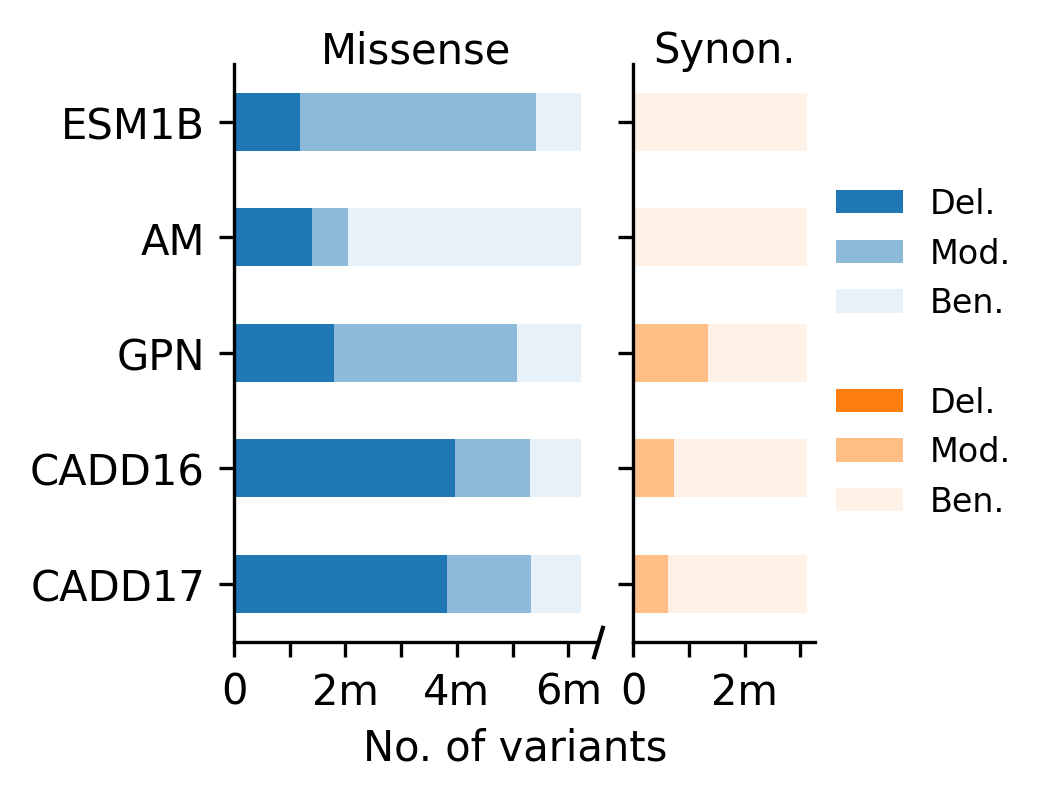

In [27]:
fig, (axm, axs) = plt.subplots(
    1, 2, figsize=(2.5,2.5), sharey=True, gridspec_kw={'width_ratios': [6.2, 3.1]}
)

# Missense variants
barm = counts.swaplevel(1, 0, axis=1).loc[ANNO_ORDER[::-1],:].iloc[:,:3].plot.barh(
    stacked = 1,
    color = {
        ('Deleterious','Missense'): (31/255., 119/255., 180/255., 1.0), 
        ('Moderate','Missense'): (31/255., 119/255., 180/255., 0.5),
        ('Benign','Missense'): (31/255., 119/255., 180/255., 0.1),
    },
    ax = axm,
    legend = 0,
);

axm.set_title('Missense', fontsize=10, y=0.96);
axm.set_xticks([0, 1e6, 2e6, 3e6, 4e6, 5e6, 6e6], ['0','','2m','','4m','','6m']);

# Synonymous variants
bars = counts.swaplevel(1, 0, axis=1).loc[ANNO_ORDER[::-1],:].iloc[:,-3:].plot.barh(
    stacked = 1,
    color = {
        ('Deleterious','Synonymous'): (255/255., 127/255., 14/255., 1.0),
        ('Moderate','Synonymous'): (255/255., 127/255., 14/255., 0.5),
        ('Benign','Synonymous'): (255/255., 127/255., 14/255., 0.1),
    },
    ax = axs,
    legend = 1,
);

axs.set_title('Synon.', fontsize=10, y=0.96);
axs.set_xticks([0, 1e6, 2e6, 3e6], ['0','','2m','']);
axs.legend(
    axm.get_legend_handles_labels()[0] + [mpl.lines.Line2D([], [], color='none')] + axs.get_legend_handles_labels()[0],
    ['Del.','Mod.','Ben.'] + ['', 'Del.','Mod.','Ben.'], 
    frameon=0, fontsize=8, bbox_to_anchor=(0.95, 0.5), loc='center left'
);

# Hack together the axis break
d = 1/.3  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(
    marker=[(-1, -d), (1, d)], 
    markersize=8,
    linestyle="none",
    color='k', 
    mec='k', 
    mew=1, 
    clip_on=False
)
axm.plot([1], [0], transform=axm.transAxes, **kwargs);

fig.subplots_adjust(wspace=0.13) 
fig.supxlabel('No. of variants', fontsize=10, y=-0.06);

sns.despine();

fig.savefig('png/Fig1a.png', bbox_inches='tight');

### Set intersection

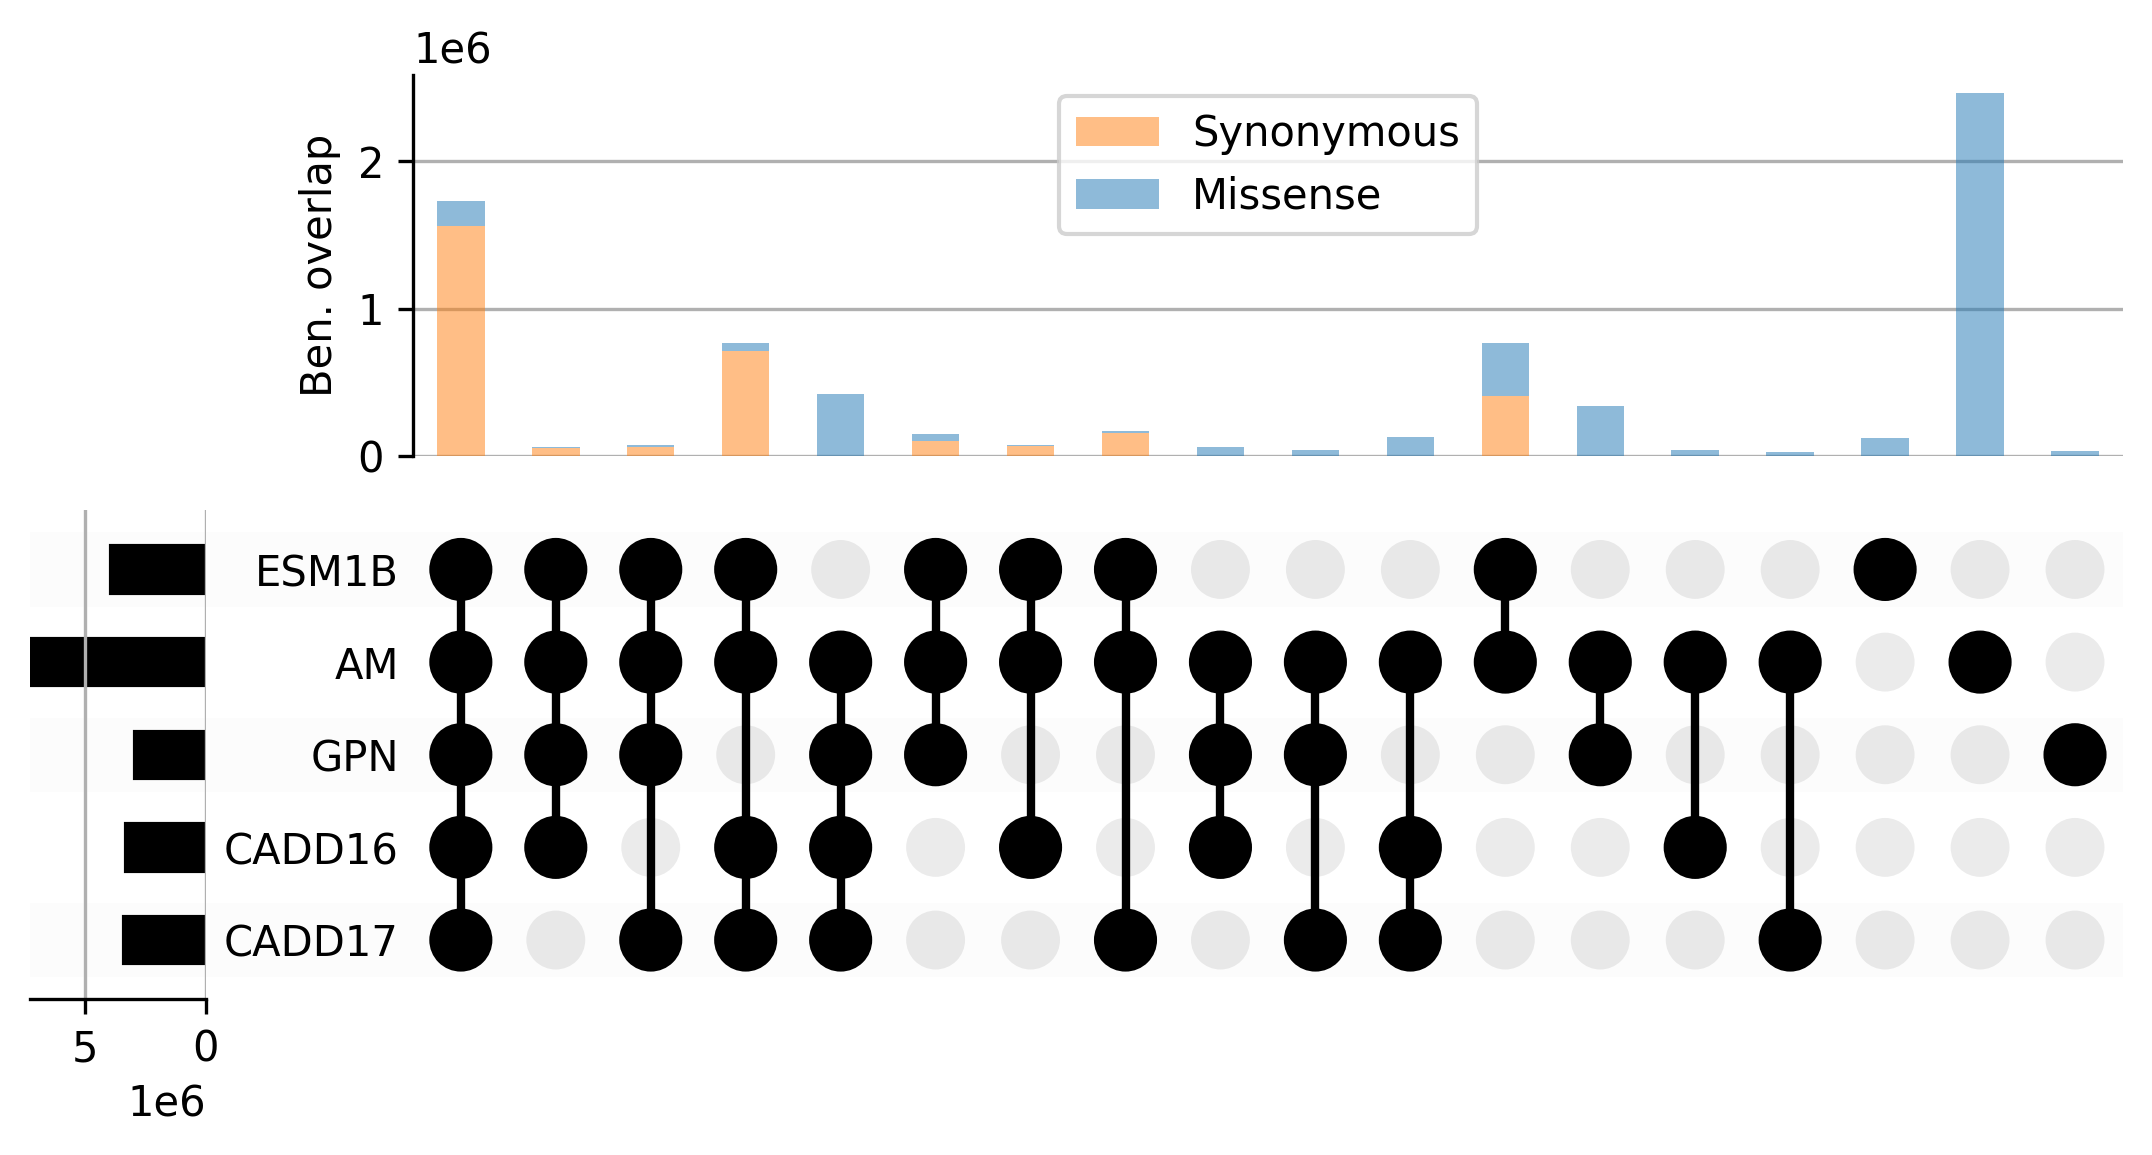

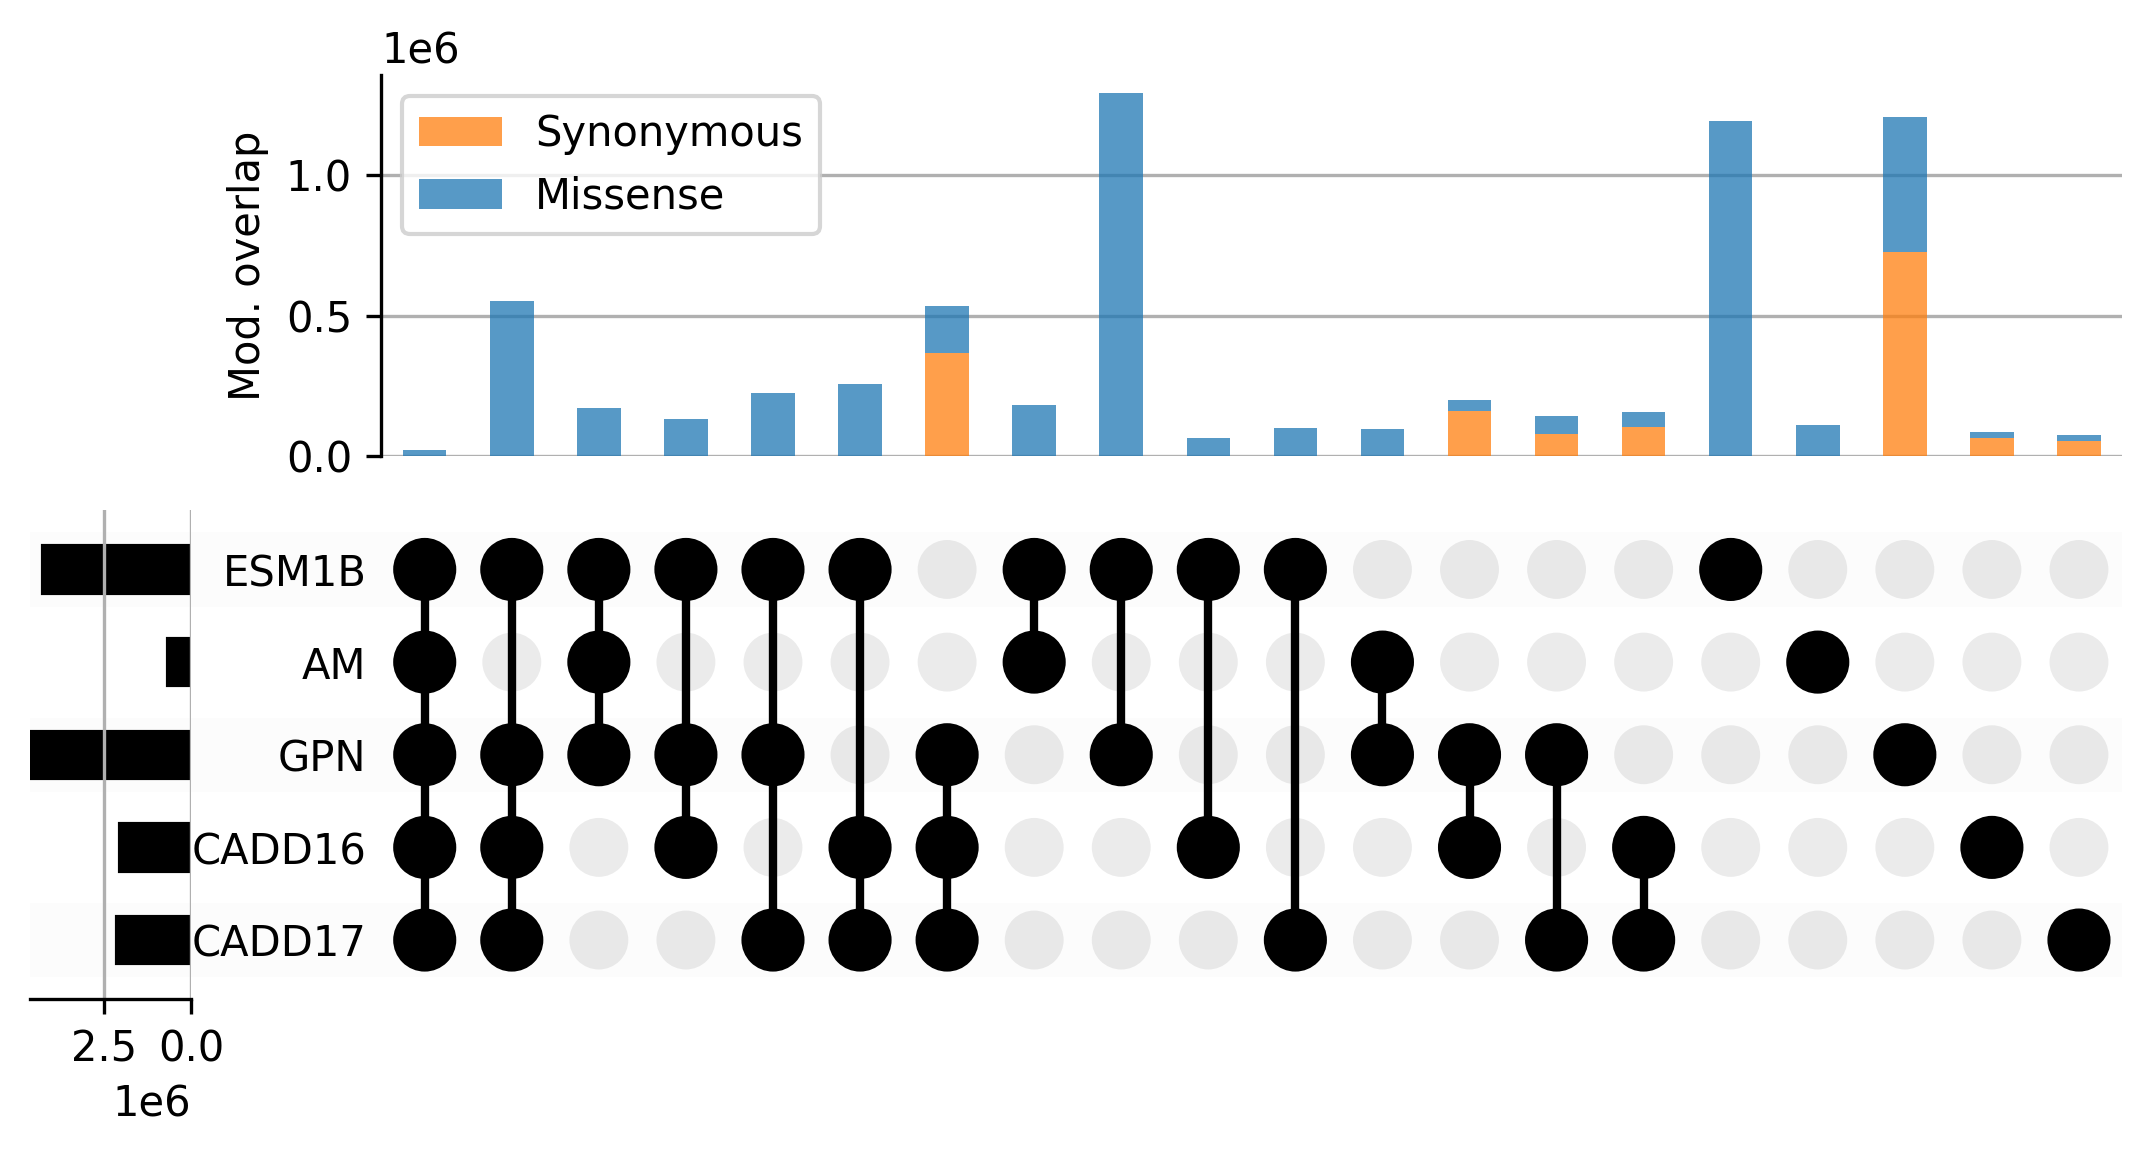

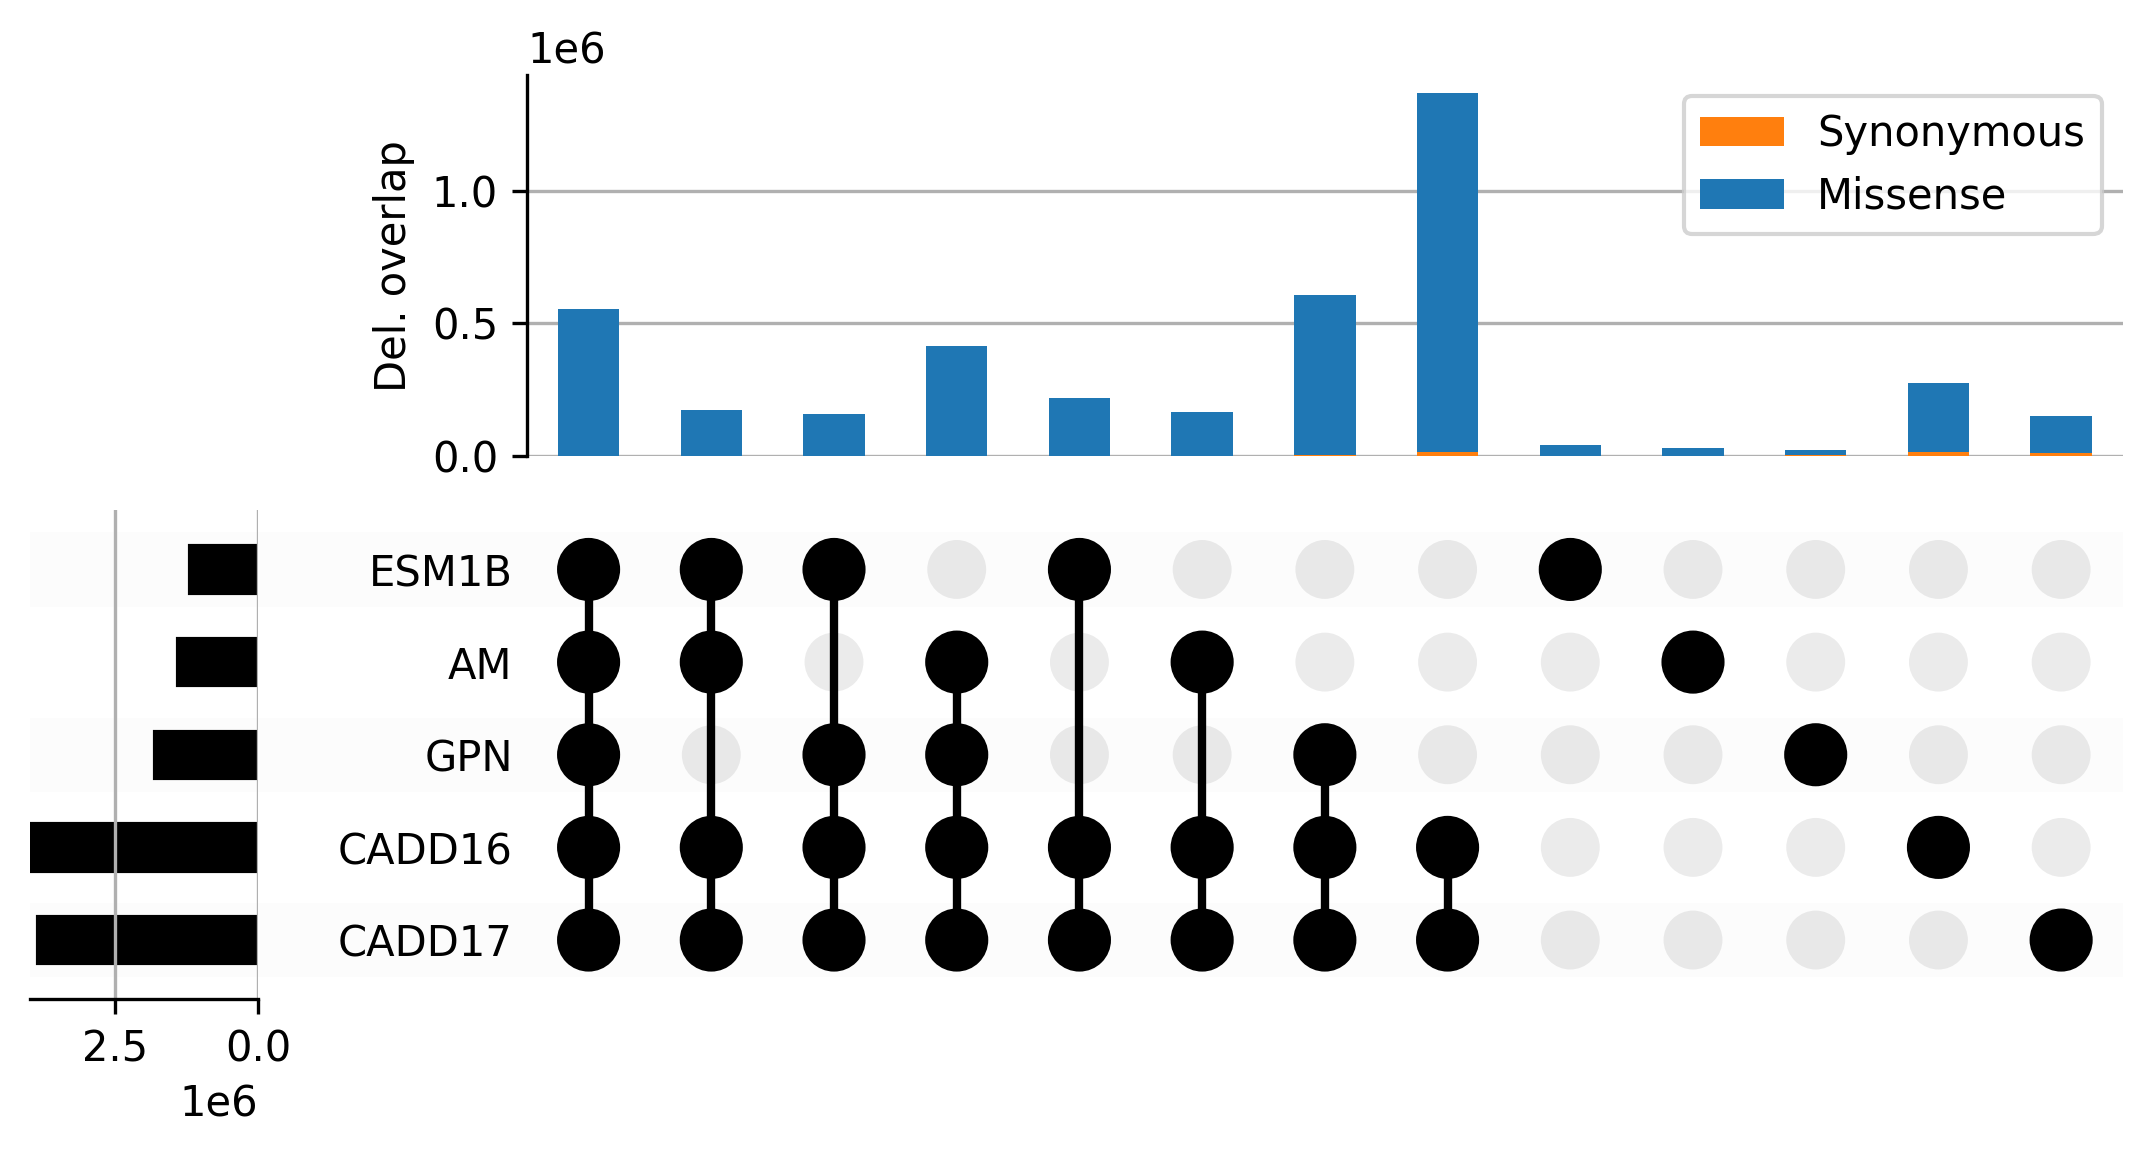

In [28]:
for ant, fig_name, alpha in zip(['ben','mod','del'], ['Fig1d','supplement/mod_upset','Fig1b'], [0.5, 0.75, 1.0]):
    fig = plt.figure(figsize=(9, 4))

    dat = v_uniq.copy().set_index(
        [k[1] for k in (v_uniq[ANNO_ORDER[::-1]] == ant).items()]
    )
    
    upset = us.UpSet(
        data = dat[['mis','mis_str']],
        sort_by='-degree',
        sort_categories_by='input',
        min_degree = 1,
        min_subset_size = int(0.002 * v_uniq.shape[0]),
        other_dots_color = 0.08,
        shading_color = 0.01,
        show_percentages = False,
        intersection_plot_elements = False,
        element_size = None,
    )
    upset.add_stacked_bars(
        by = 'mis_str',
        colors = {'Missense':'tab:blue', 'Synonymous':'tab:orange'},
        elements = 4,
    )
    
    ax_dict = upset.plot(fig = fig);
    
    ax_dict['extra0'].set_ylabel(
        '{0}. overlap'.format(ant.title())
    ); 

    for bar in ax_dict['extra0'].patches:
        bar.set_alpha(alpha)
    for handle in ax_dict['extra0'].legend().legend_handles:
        handle.set_alpha(alpha)
    
    #ax_dict['extra0'].set_title(
    #    '{0} of {1} variants'.format( sum(any(t) for t in dat.index), dat.shape[0] ),
    #    fontsize = 10,
    #);

    fig.savefig('png/' + fig_name + '.png', bbox_inches='tight');
    # plt.show();

ESM1B  AM    GPN    CADD16  CADD17
True   True  False  False   False      405432
             True   True    True      1562505
Name: count, dtype: int64
ESM1B  AM     GPN    CADD16  CADD17
False  False  False  False   False     1850891
True   True   True   True    True       167453
Name: count, dtype: int64


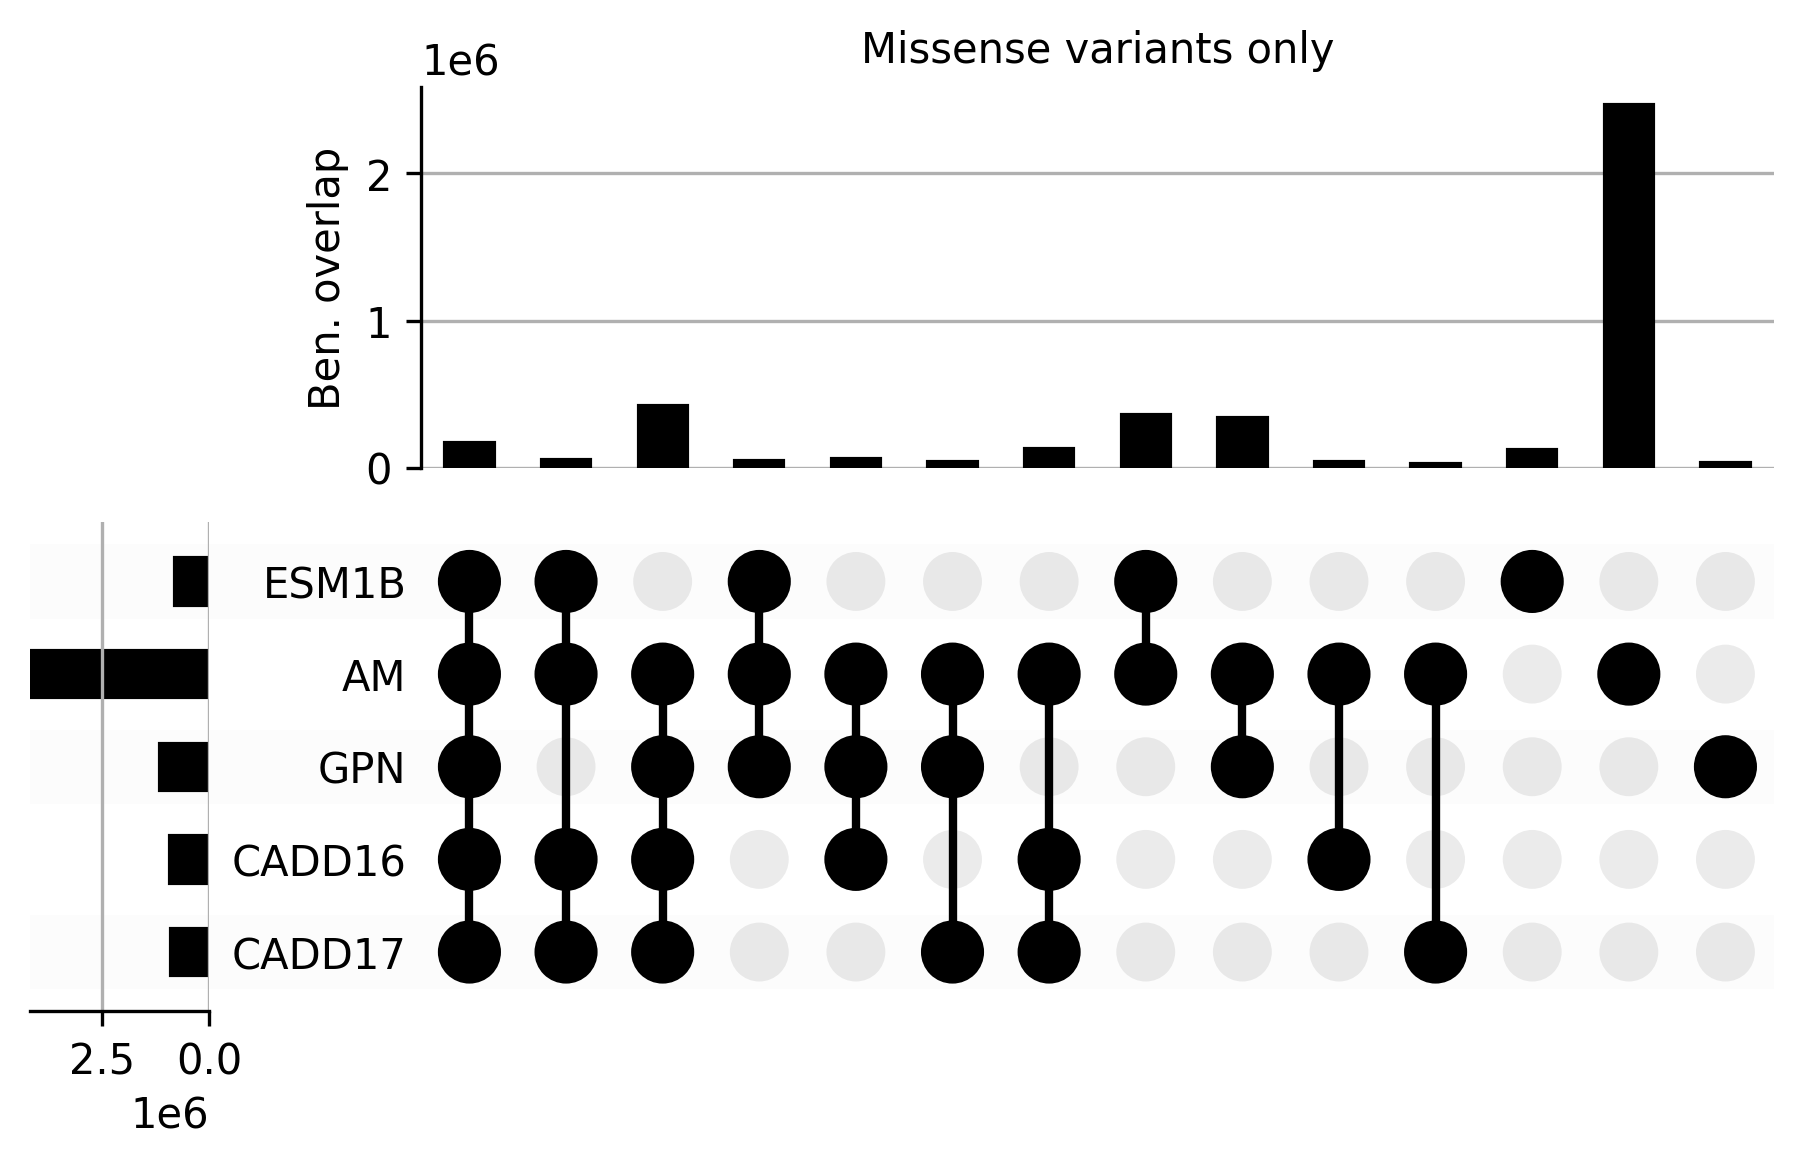

In [29]:
for ant, fig_name in zip(['ben'], ['ben_mis_upset']):
    fig = plt.figure(figsize=(7.5, 4))

    dat = v_uniq.copy().set_index(
        [k[1] for k in (v_uniq[ANNO_ORDER[::-1]] == ant).items()]
    )
    print(dat.query('~mis')['mis'].reset_index()[ANNO_ORDER].value_counts().sort_index().iloc[[0,-1]])
    print(dat.query('mis')['mis'].reset_index()[ANNO_ORDER].value_counts().sort_index().iloc[[0,-1]])
    
    upset = us.UpSet(
        data = dat.query('mis'),
        sort_by='-degree',
        sort_categories_by='input',
        min_degree = 1,
        min_subset_size = int(0.002 * v_uniq.shape[0]),
        other_dots_color = 0.08,
        shading_color = 0.01,
        show_percentages = False,
        intersection_plot_elements = 4,
        element_size = None,
    )
    
    ax_dict = upset.plot(fig = fig);
    
    ax_dict['intersections'].set_ylabel(
        '{0}. overlap'.format(ant.title())
    ); 
    
    ax_dict['intersections'].set_title(
        'Missense variants only',
        fontsize = 10,
    );

    fig.savefig('png/supplement/' + fig_name + '.png', bbox_inches='tight');
    plt.show();

### Score correlation

#### All variants

In [30]:
display(
    v_uniq[scores + ['maf']].corr(method='spearman'),
    v_uniq.query('mis')[scores + ['maf']].corr(method='spearman')
)      

,-esm1b_pred,am_pathogenicity,-gpn,cadd16_phred,cadd17_phred,s_het,1/loeuf,maf
-esm1b_pred,1.000000,0.855386,0.611082,0.719605,0.735762,-0.062529,-0.051564,0.003490
am_pathogenicity,0.855386,1.000000,0.721321,0.793213,0.793305,-0.010938,-0.004882,-0.021909
-gpn,0.611082,0.721321,1.000000,0.841987,0.838544,0.207761,0.168456,-0.073900
cadd16_phred,0.719605,0.793213,0.841987,1.000000,0.970303,0.120491,0.097548,-0.023045
cadd17_phred,0.735762,0.793305,0.838544,0.970303,1.000000,0.141623,0.108834,-0.005752
s_het,-0.062529,-0.010938,0.207761,0.120491,0.141623,1.000000,0.659640,-0.000114
1/loeuf,-0.051564,-0.004882,0.168456,0.097548,0.108834,0.659640,1.000000,-0.000057
maf,0.003490,-0.021909,-0.073900,-0.023045,-0.005752,-0.000114,-0.000057,1.000000


,-esm1b_pred,am_pathogenicity,-gpn,cadd16_phred,cadd17_phred,s_het,1/loeuf,maf
-esm1b_pred,1.000000,0.528932,0.394451,0.496571,0.526970,-0.049009,-0.063900,0.022475
am_pathogenicity,0.528932,1.000000,0.670872,0.694831,0.681847,0.065275,0.039828,-0.034414
-gpn,0.394451,0.670872,1.000000,0.782335,0.792301,0.333588,0.257864,-0.061575
cadd16_phred,0.496571,0.694831,0.782335,1.000000,0.941976,0.181324,0.147434,0.009037
cadd17_phred,0.526970,0.681847,0.792301,0.941976,1.000000,0.234693,0.180872,0.026327
s_het,-0.049009,0.065275,0.333588,0.181324,0.234693,1.000000,0.654035,-0.002653
1/loeuf,-0.063900,0.039828,0.257864,0.147434,0.180872,0.654035,1.000000,-0.001081
maf,0.022475,-0.034414,-0.061575,0.009037,0.026327,-0.002653,-0.001081,1.000000


##### Fig. S2

,-esm1b_pred,am_pathogenicity,-gpn,cadd16_phred,cadd17_phred,s_het,1/loeuf
-esm1b_pred,1.000000,0.852719,0.620094,0.721708,0.738059,-0.067493,-0.057419
am_pathogenicity,0.852719,1.000000,0.730350,0.794905,0.794832,-0.014928,-0.009836
-gpn,0.620094,0.730350,1.000000,0.844365,0.840426,0.198597,0.157467
cadd16_phred,0.721708,0.794905,0.844365,1.000000,0.970254,0.113591,0.089728
cadd17_phred,0.738059,0.794832,0.840426,0.970254,1.000000,0.134787,0.100989
s_het,-0.067493,-0.014928,0.198597,0.113591,0.134787,1.000000,0.658998
1/loeuf,-0.057419,-0.009836,0.157467,0.089728,0.100989,0.658998,1.000000


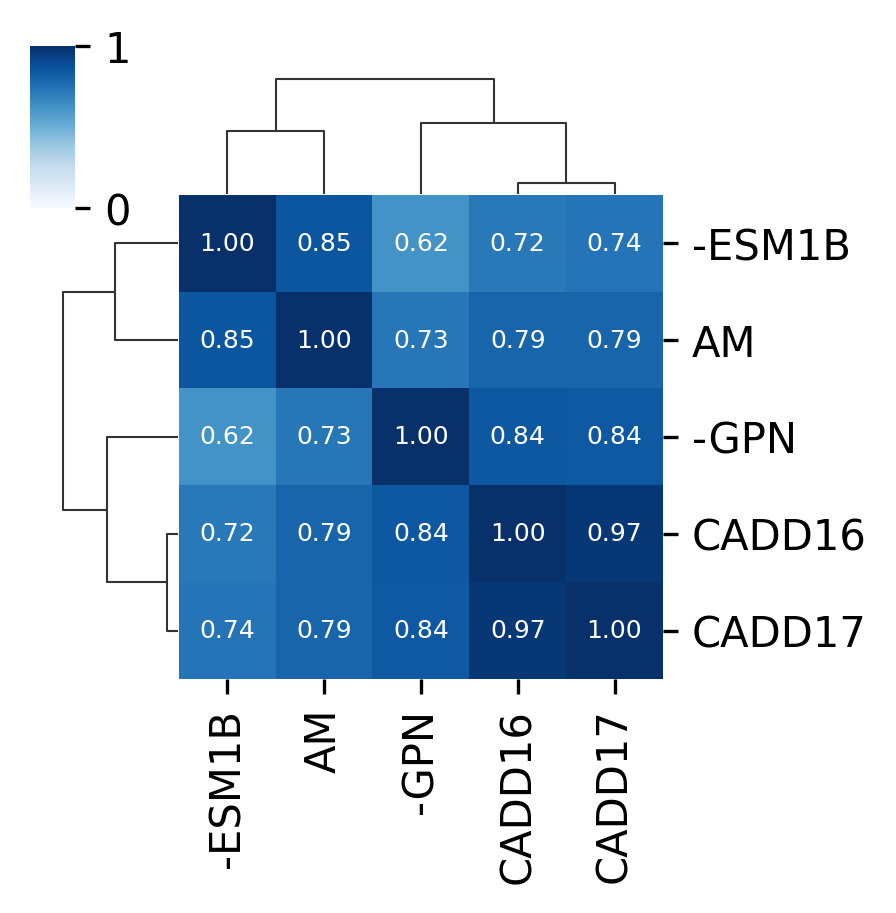

In [31]:
avs = vs[scores].corr(method='spearman')
display(avs)

sns.clustermap(
    avs.loc[scores[:5], scores[:5]].rename(
        lambda s: s.split('_')[0].upper(), axis=0,
    ).rename(
        lambda s: s.split('_')[0].upper(), axis=1,
    ),
    cmap = 'Blues',
    vmin = 0, vmax = 1,
    annot=True, fmt=".2f", annot_kws={'size': 6},
    figsize = (3, 3),
);

plt.savefig('png/supplement/all_var_score_heatmap.png', bbox_inches='tight');

#### Missense variants

,-esm1b_pred,am_pathogenicity,-gpn,cadd16_phred,cadd17_phred,s_het,1/loeuf
-esm1b_pred,1.000000,0.534060,0.406661,0.503289,0.533837,-0.057344,-0.071878
am_pathogenicity,0.534060,1.000000,0.680144,0.695827,0.682764,0.059282,0.033853
-gpn,0.406661,0.680144,1.000000,0.783992,0.793591,0.324398,0.247649
cadd16_phred,0.503289,0.695827,0.783992,1.000000,0.941712,0.171204,0.136343
cadd17_phred,0.533837,0.682764,0.793591,0.941712,1.000000,0.223924,0.169121
s_het,-0.057344,0.059282,0.324398,0.171204,0.223924,1.000000,0.652995
1/loeuf,-0.071878,0.033853,0.247649,0.136343,0.169121,0.652995,1.000000


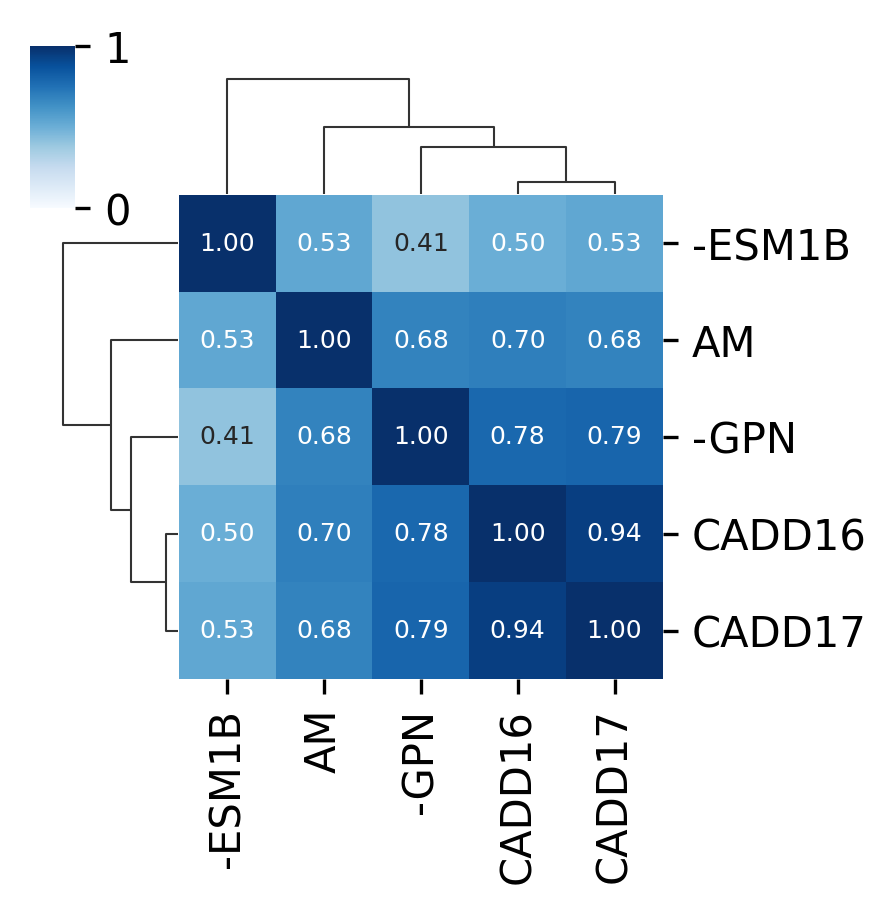

In [32]:
mvs = vs.query('mis')[scores].corr(method='spearman')
display(mvs)

sns.clustermap(
    mvs.loc[scores[:5], scores[:5]].rename(
        lambda s: s.split('_')[0].upper(), axis=0,
    ).rename(
        lambda s: s.split('_')[0].upper(), axis=1,
    ),
    cmap = 'Blues',
    vmin = 0, vmax = 1,
    annot=True, fmt=".2f", annot_kws={'size': 6},
    figsize = (3, 3),
);

plt.savefig('png/Fig1c.png', bbox_inches='tight');

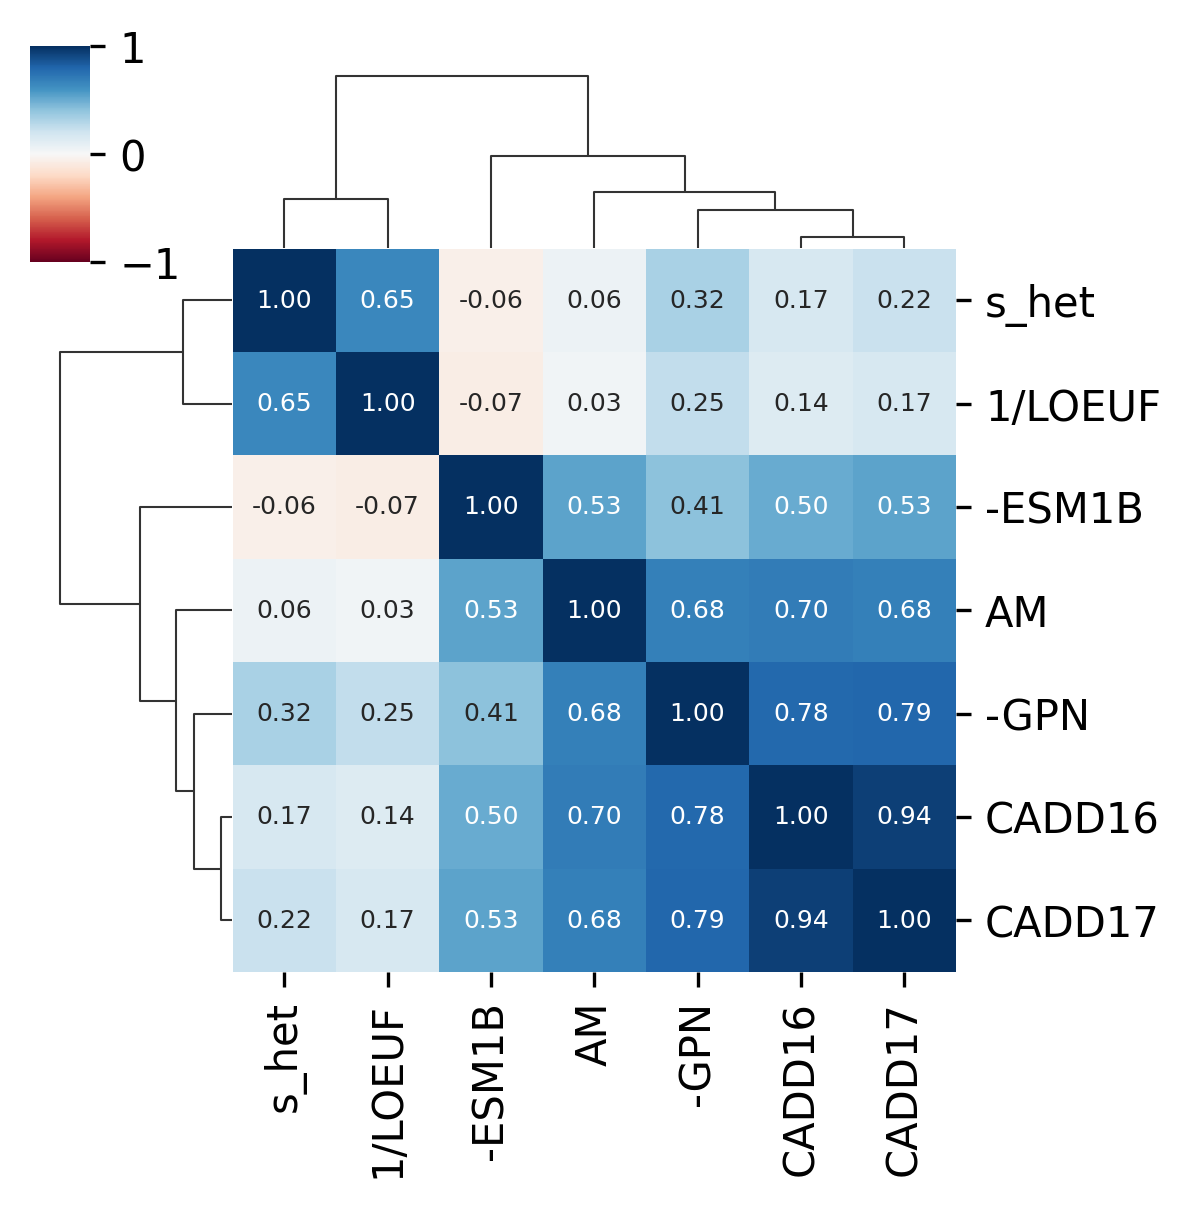

In [33]:
sns.clustermap(
    mvs.loc[scores, scores].rename(
        lambda s: s if s == 's_het' else s.split('_')[0].upper(), axis=0,
    ).rename(
        lambda s: s if s == 's_het' else s.split('_')[0].upper(), axis=1,
    ),
    cmap = 'RdBu',
    vmin = -1, vmax = 1,
    annot=True, fmt=".2f", annot_kws={'size': 6},
    figsize = (4, 4),
);

plt.savefig('png/supplement/selection_heatmap.png');

### Distributions

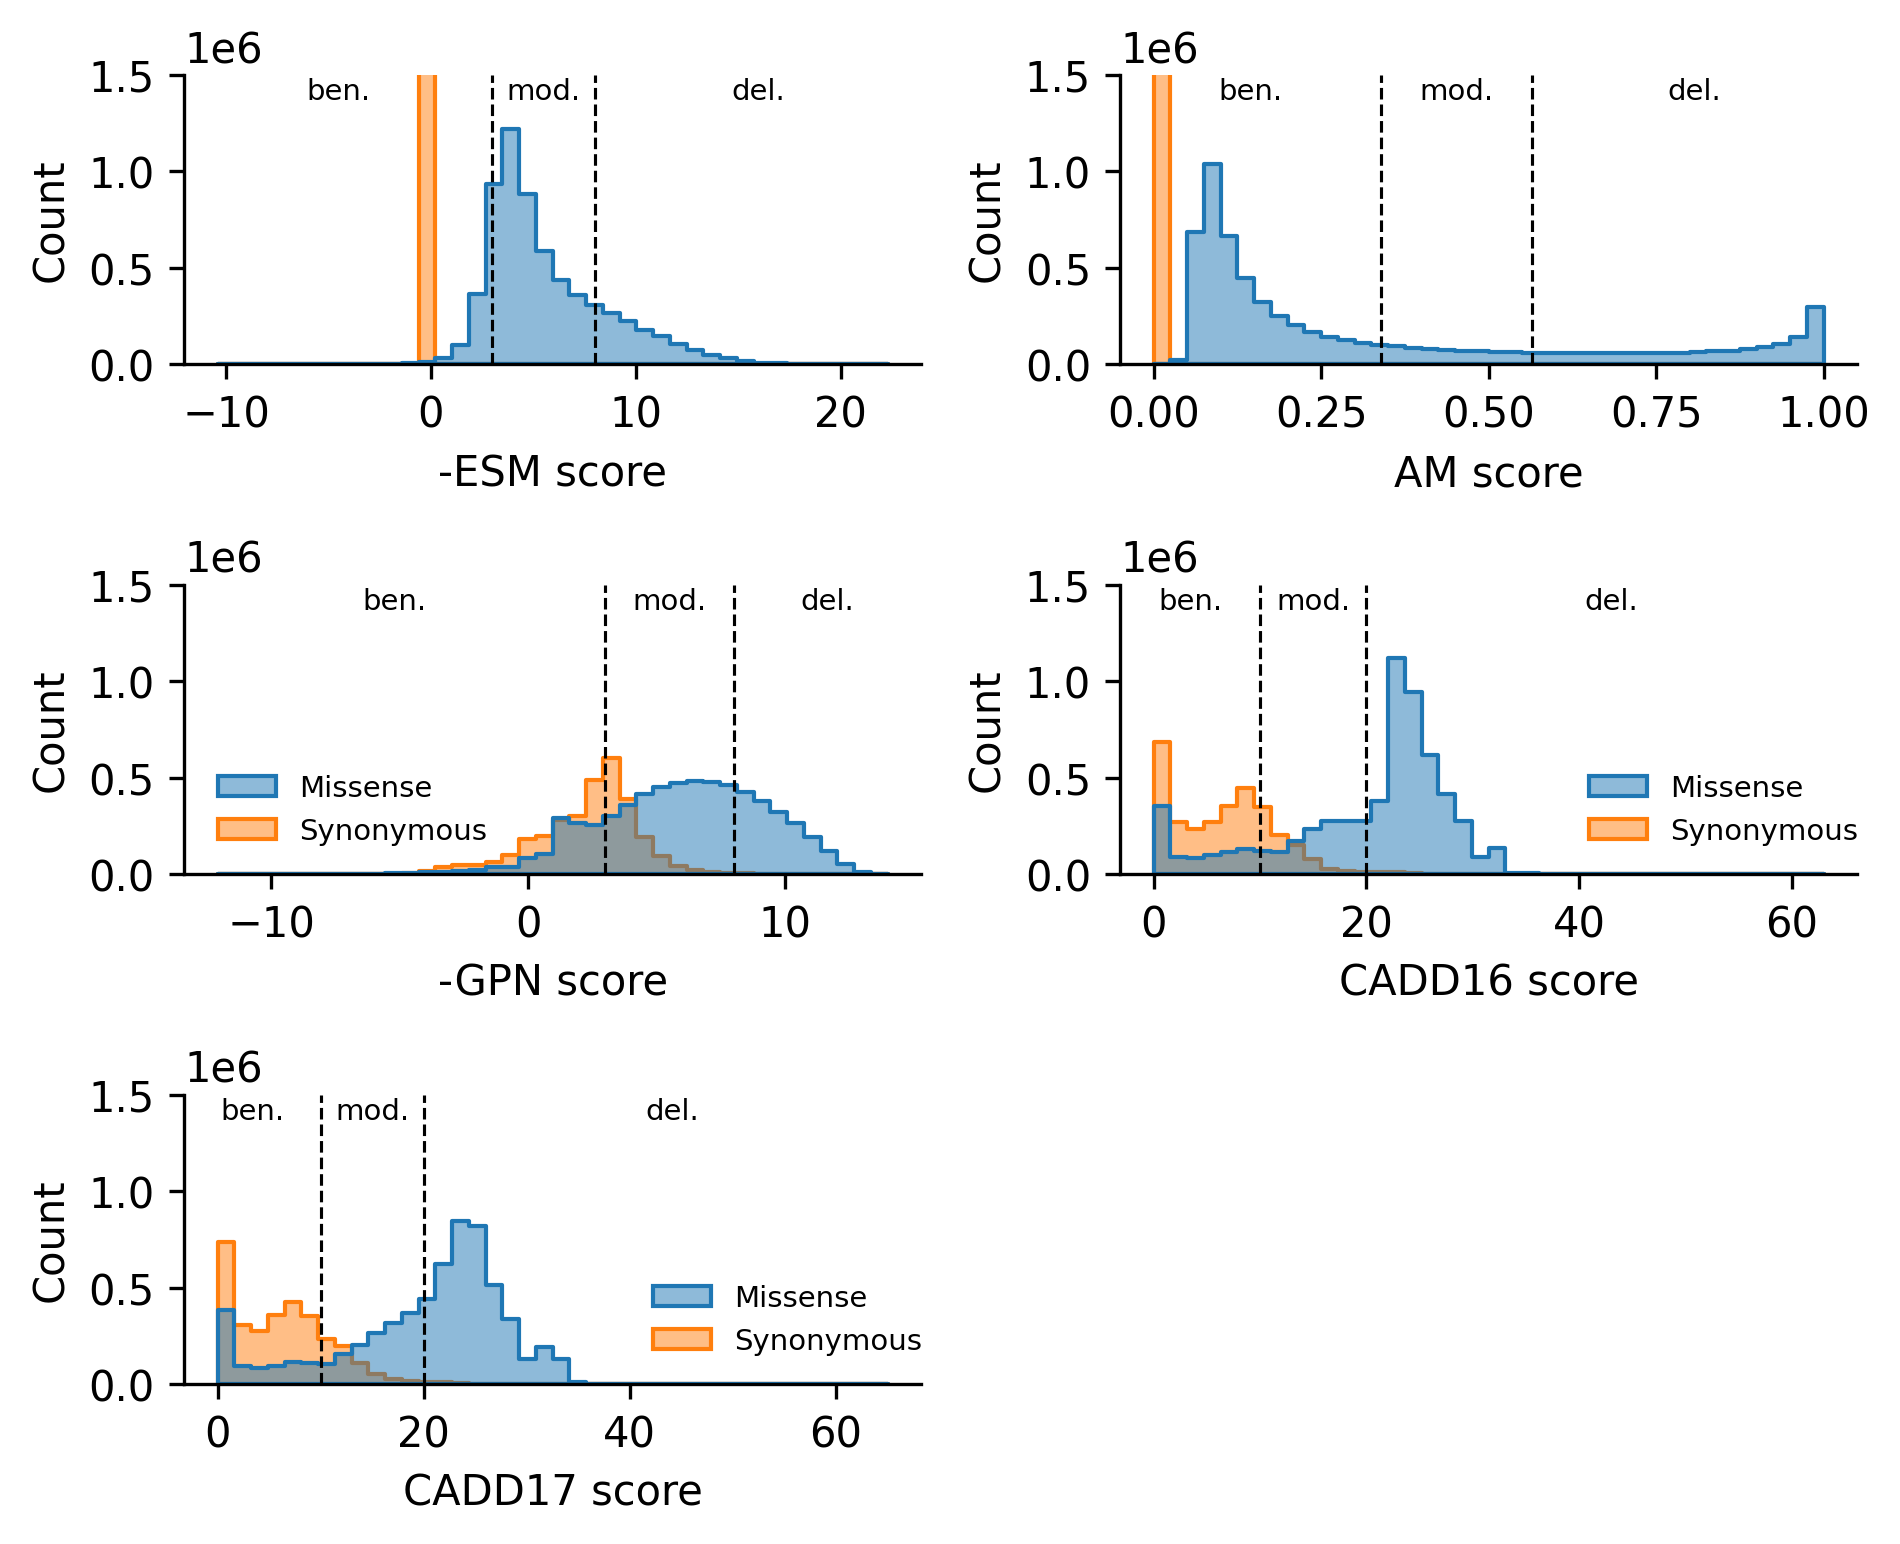

In [34]:
ddd = {
    '-esm1b_pred':'esm_annot', 
    'am_pathogenicity':'am_annot', 
    '-gpn':'gpn_annot', 
    'cadd16_phred':'cadd16_annot', 
    'cadd17_phred':'cadd17_annot'
}

fig, axs = plt.subplots(3, 2, figsize=(6.5, 5.25))

for i,((score, annot),ax) in enumerate(zip(ddd.items(), axs.flat[:5])):
    sns.histplot(
        data = vs, 
        x = score, 
        hue = 'mis_str',
        element = 'step',
        bins = 40,
        alpha = 0.5,
        ax = ax,
        legend = (i > 1),
    );

    ax.set_ylim(0, 1.5e6);
    ax.set_xlabel(('-' if 'esm' in annot or 'gpn' in annot else '') + annot.split('_')[0].upper() + ' score');
    if i > 1:
        sns.move_legend(
            ax, 
            loc='lower left', 
            bbox_to_anchor=(0.01 if i < 3 else 0.6, 0.01), 
            title=None, 
            fontsize=7, 
            frameon=0
        );
    
    t1,t2 = vs.loc[vs[annot] == 'mod', score].abs().quantile([0, 1]).values

    for t in [t1, t2]:
        ax.axvline(t, linewidth=0.75, color='k', linestyle='dashed');
    for x,s in zip([(ax.get_xlim()[0] + t1)/2, (t1 + t2)/2, (ax.get_xlim()[1] + t2)/2], ['ben.','mod.','del.']):
        ax.text(x, 0.99 * ax.get_ylim()[1], s, fontsize=7, ha='center', va='top');

axs.flat[5].set_visible(0);
    
fig.tight_layout();
sns.despine();
fig.savefig('png/supplement/all_var_score_hist.png');

### Relationship with gene constraint

In [35]:
median_gene_scores = vs.query(
    'mis'
).groupby(
    'gene_id'
).apply(
    lambda gp: dict(
        zip(
            scores, 
            np.average(
                gp[scores], 
                # weights = 1e-7 + gp['maf'], 
                axis = 0
            )
        )
    ),
    include_groups = False
).apply(
    pd.Series
)

median_gene_scores

,-esm1b_pred,am_pathogenicity,-gpn,cadd16_phred,cadd17_phred,s_het,1/loeuf
gene_id,,,,,,,
ENSG00000000419,8.246397,0.410926,6.182583,21.751305,21.709139,0.019119,1.041667
ENSG00000000457,5.500787,0.232786,5.623318,19.286566,18.952172,0.016873,1.631321
ENSG00000000460,3.827316,0.203895,4.791535,18.525465,17.637989,0.002704,0.710227
ENSG00000000938,6.874255,0.356956,6.218333,21.598475,22.325507,0.038938,1.560062
ENSG00000000971,5.288526,0.260139,3.003208,13.617621,12.425639,0.033209,1.631321
...,...,...,...,...,...,...,...
ENSG00000288867,7.722261,0.218391,5.014348,16.757913,14.993739,NaN,0.544959
ENSG00000289549,5.106778,0.127483,2.410556,13.920500,11.936944,NaN,0.811688
ENSG00000289604,4.141563,0.169216,3.051563,12.240250,12.456406,NaN,NaN


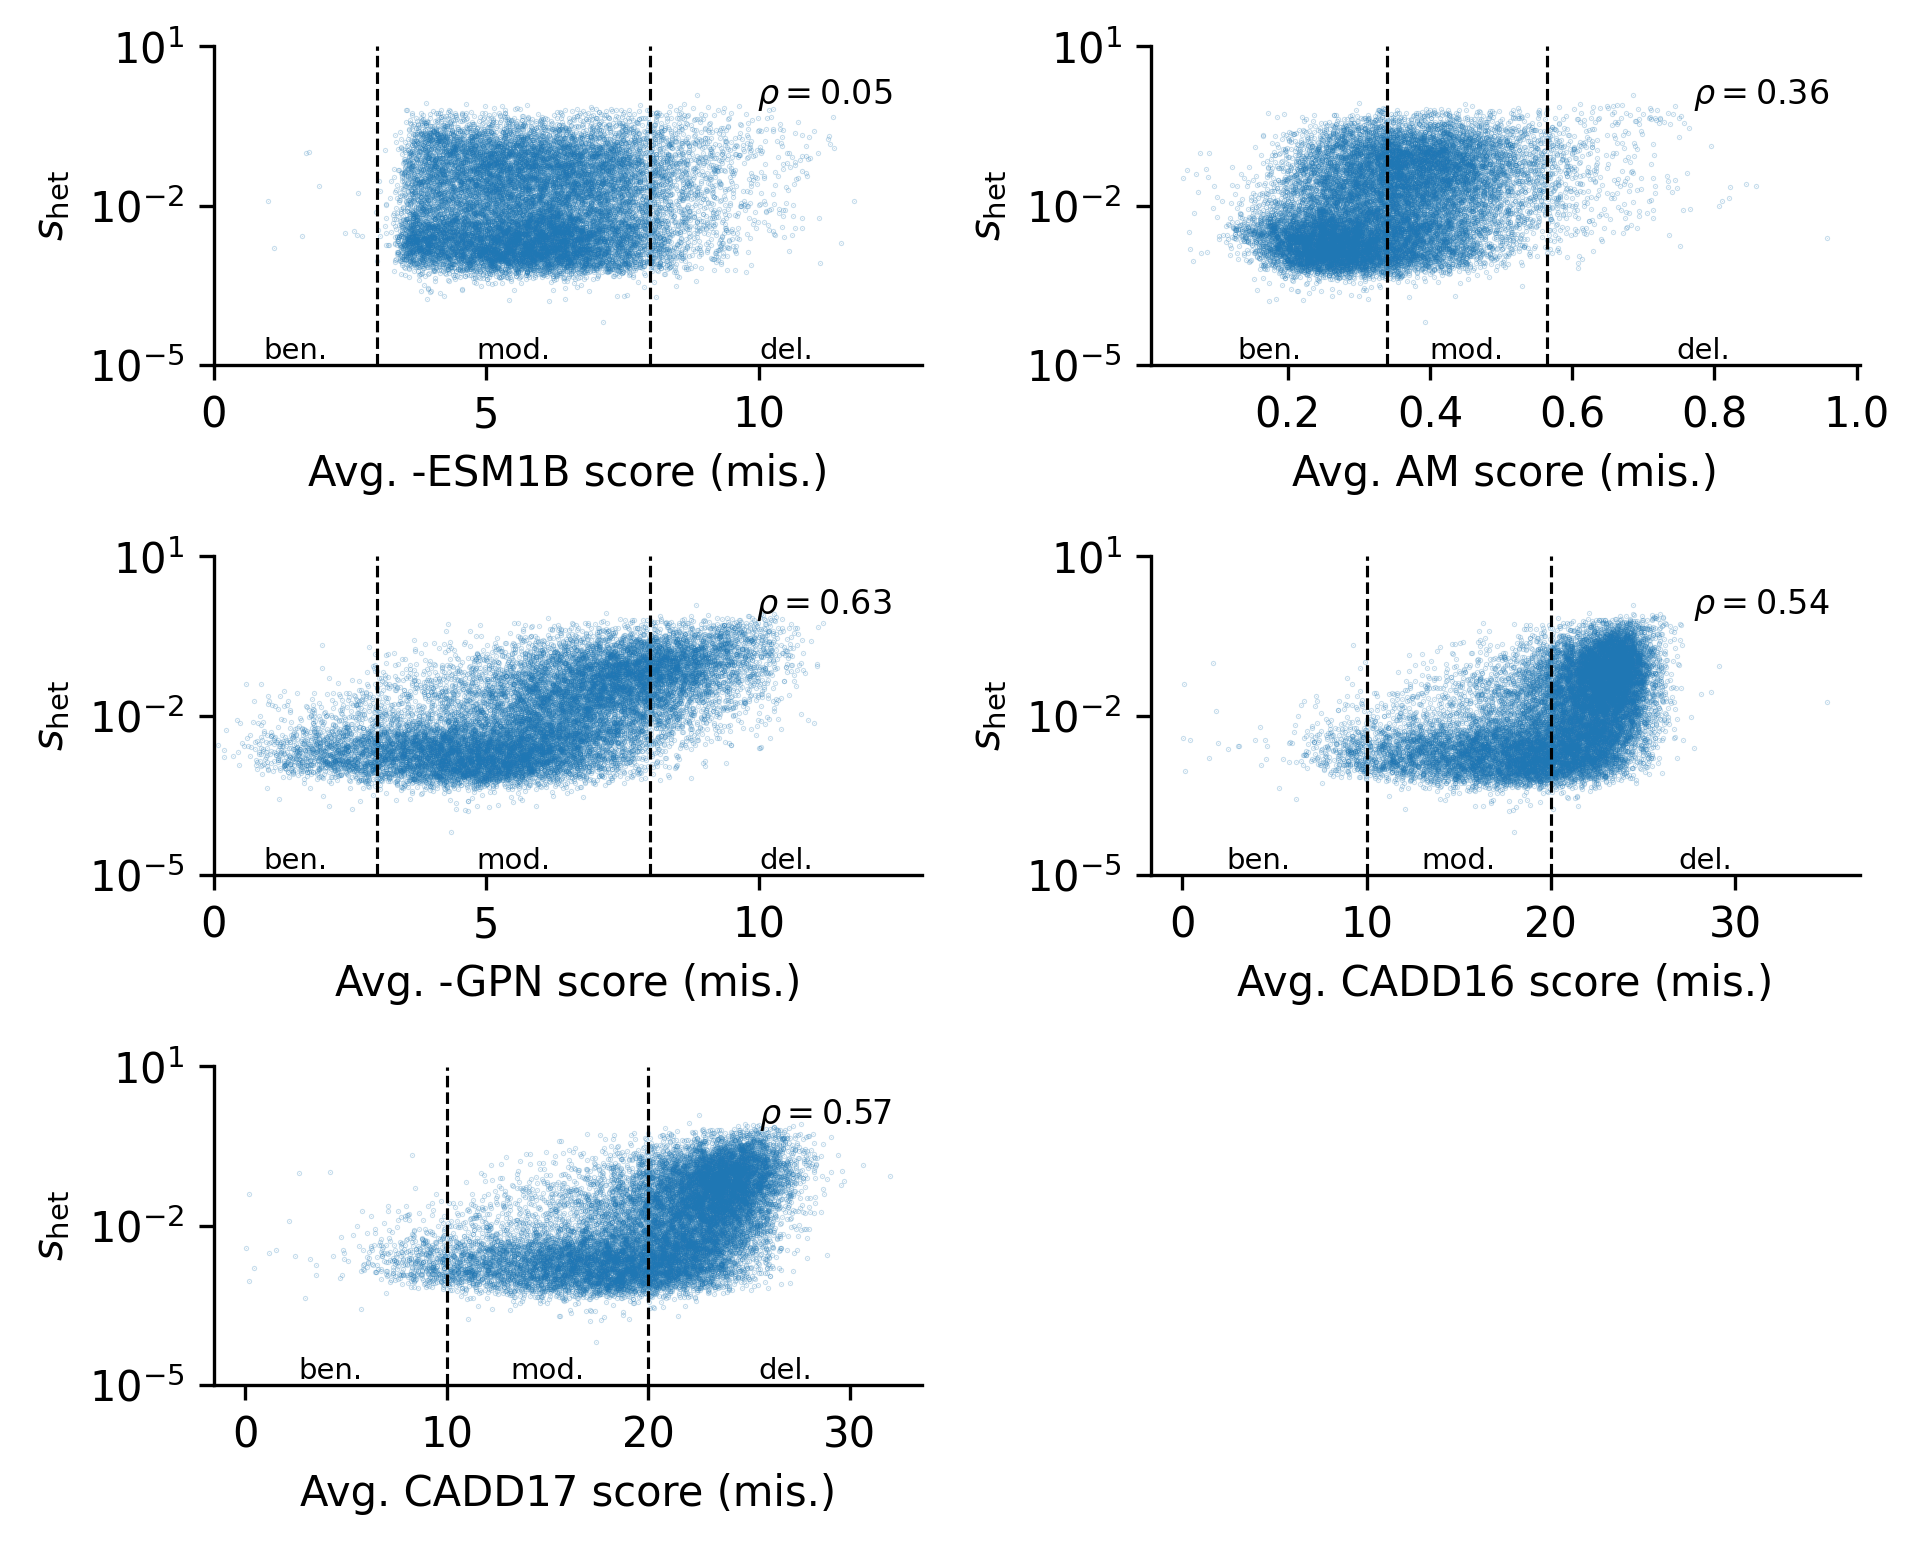

In [36]:
fig, axs = plt.subplots(3, 2, figsize=(6.5, 5.25))

for i,(c,ax) in enumerate(zip(median_gene_scores.columns[:5], axs.flat[:5])):
    
    median_gene_scores.plot.scatter(
        x = c,
        y = 's_het',
        # marker = '.',
        s = 0.07,
        alpha = 0.25,
        ax = ax,
        label = r'$\rho = {:.2f}$'.format(median_gene_scores[[c, 's_het']].corr(method='spearman').iloc[0,1]), 
    );

    if '-' in c:
        ax.set_xlim(0, 13);

    annot = c.replace('-','').split('_')[0].split('1b')[0] + '_annot'
    
    t1,t2 = vs.loc[vs[annot] == 'mod', c.replace('-','')].apply(
        np.abs if '-' in c else lambda x: x
    ).quantile([0, 1]).values

    for t in [t1, t2]:
        ax.axvline(t, linewidth=0.75, color='k', linestyle='dashed');
    for x,s in zip([(ax.get_xlim()[0] + t1)/2, (t1 + t2)/2, (ax.get_xlim()[1] + t2)/2], ['ben.','mod.','del.']):
        ax.text(x, 1e-5, s, fontsize=7, ha='center', va='bottom');
    
    ax.set_xlabel('Avg. {} score (mis.)'.format(c.split('_')[0].upper()));
    ax.set_yscale('log');
    ax.set_ylim(1e-5, 1e1);
    ax.set_ylabel(r'$s_\text{het}$');
    ax.legend(frameon=0, fontsize=8, loc='upper right');

axs.flat[5].set_visible(0);
    
fig.tight_layout();
sns.despine();

plt.savefig('png/supplement/selection_scatterplot.png');

### Figure 1

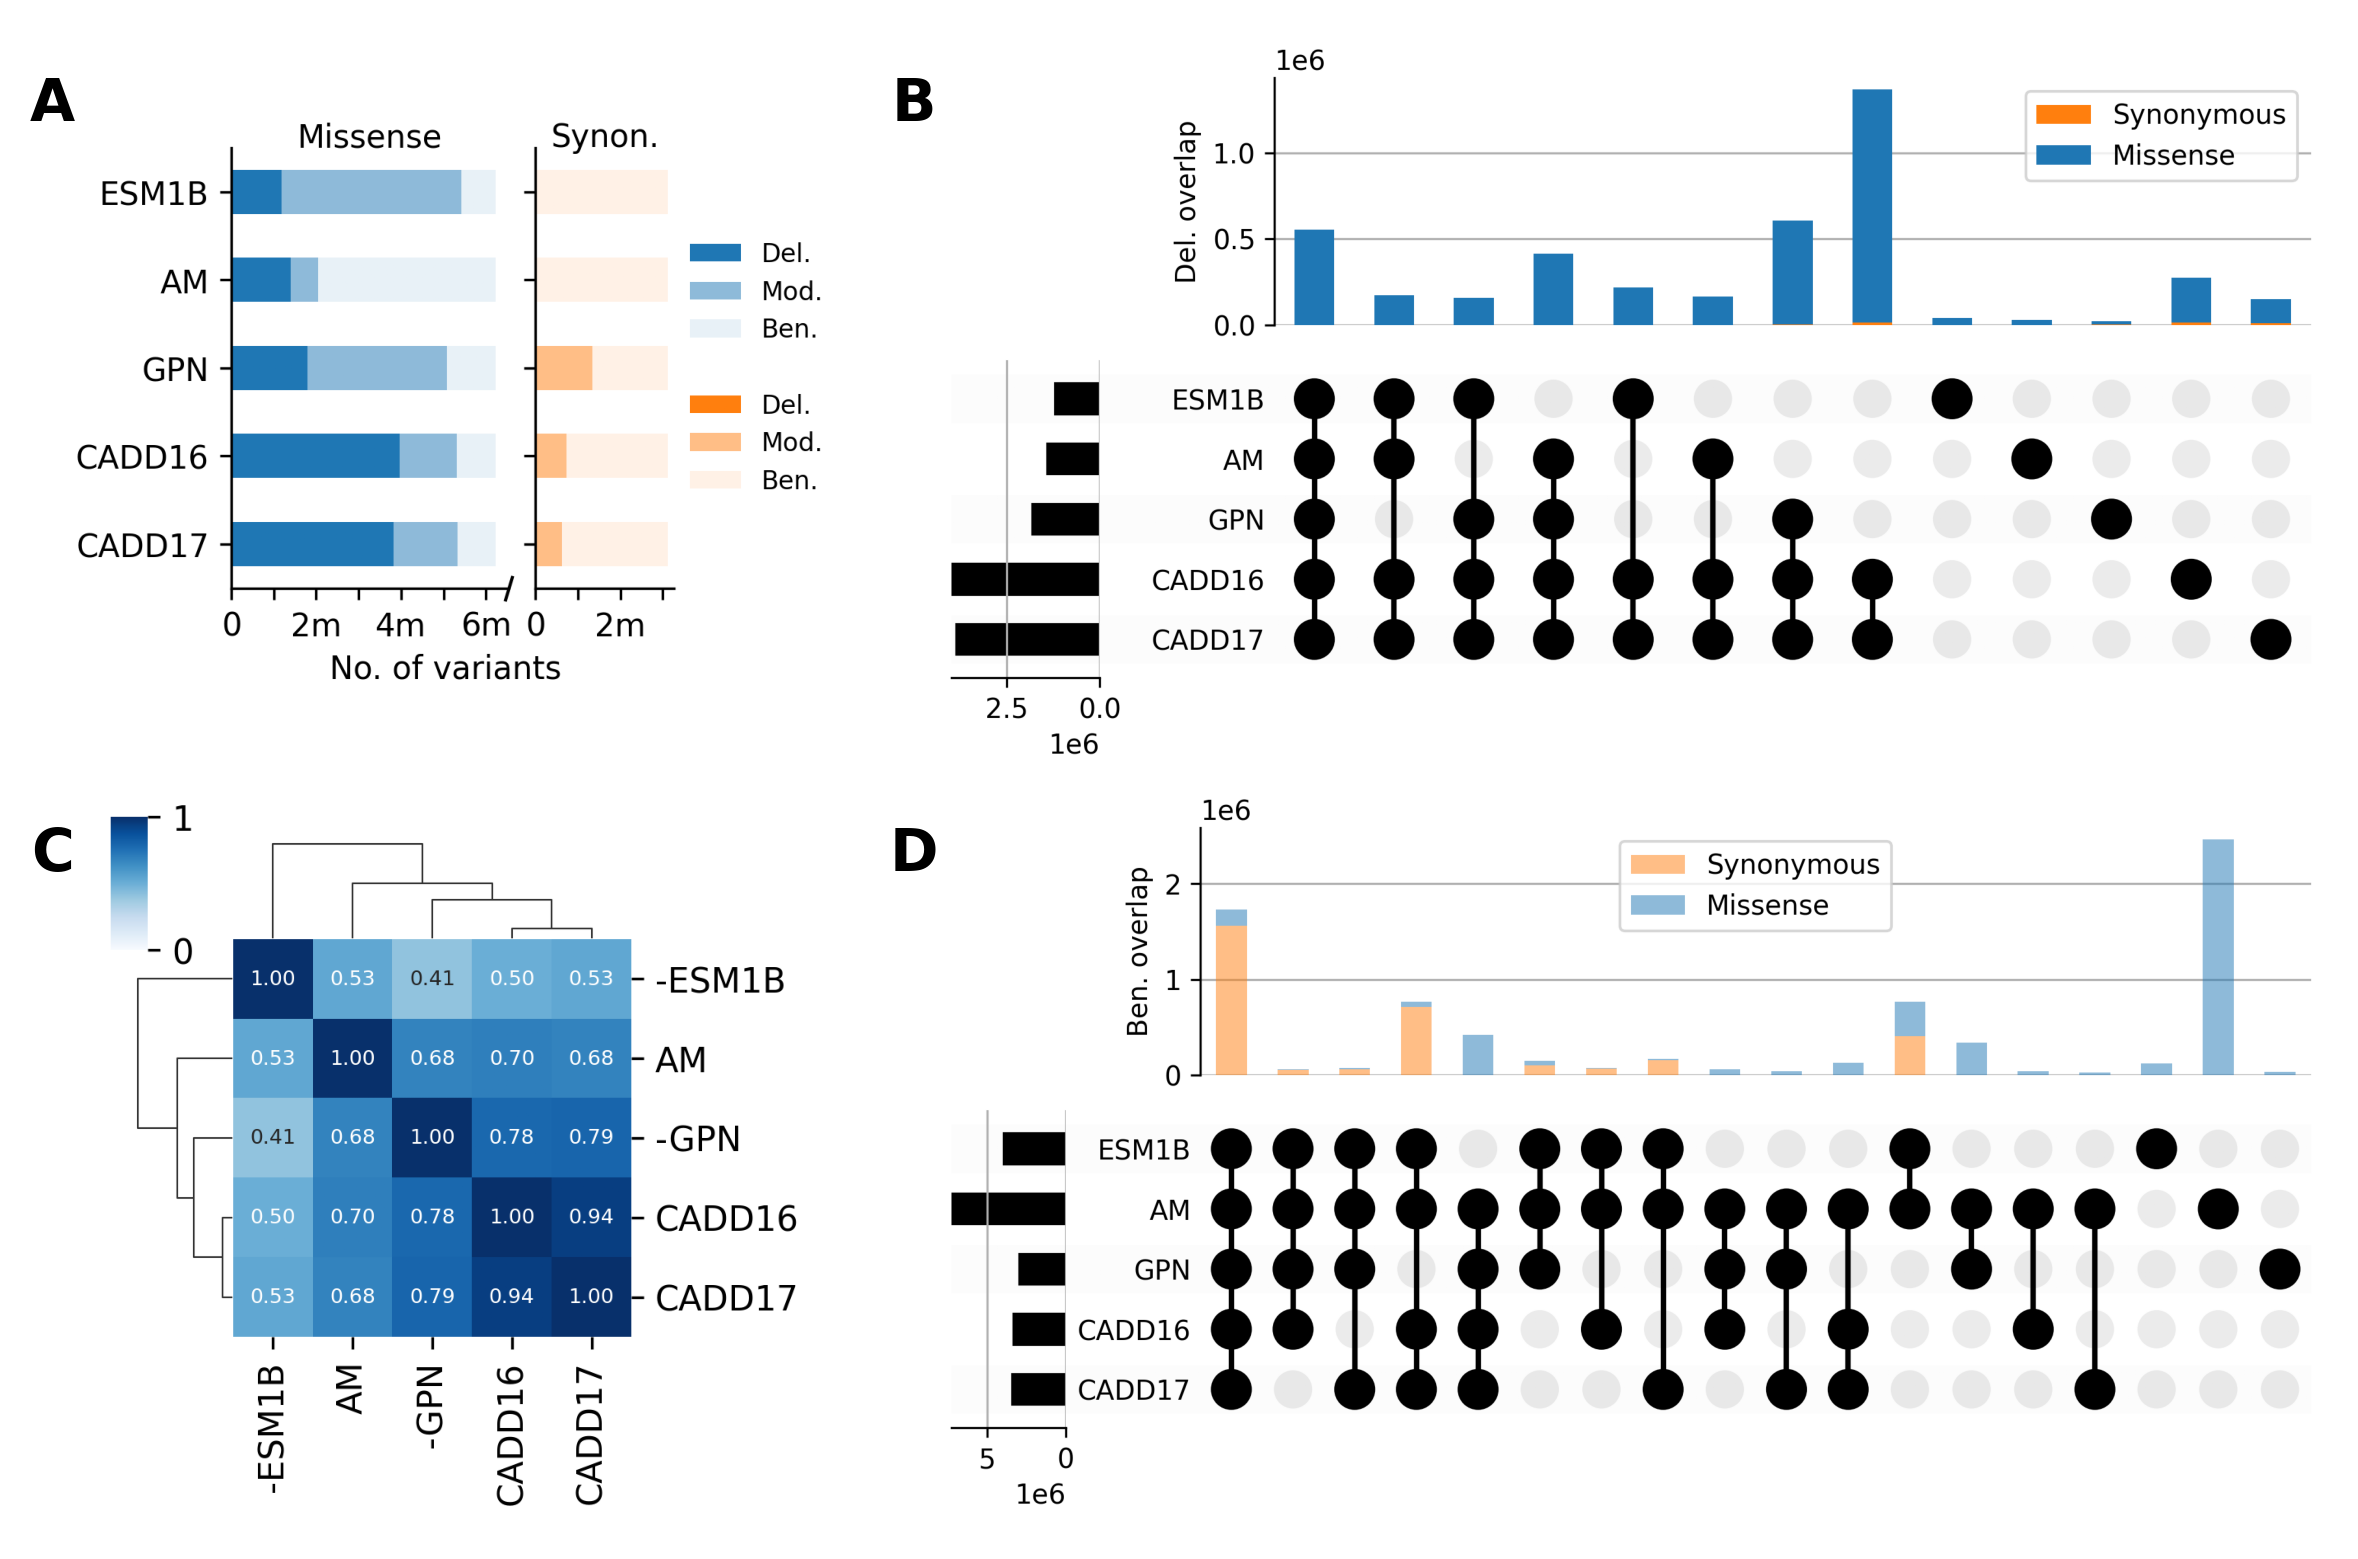

In [37]:
fig1_subplots = ['Fig1a.png', 'Fig1b.png', 'Fig1c.png', 'Fig1d.png']

fig, axs = plt.subplots(2, 2, figsize=(8.2, 5), width_ratios=(2.5, 5.5), ) 

# 3. Load and plot each image
for png,ax in zip(fig1_subplots, axs.flat):
    ax.imshow(mpimg.imread('png/' + png))
    ax.axis('off') 

fig.text(0.0, 0.95, 'A', ha='center', va='center', fontsize=14, fontweight='bold')
fig.text(0.35, 0.95, 'B', ha='center', va='center', fontsize=14, fontweight='bold')
fig.text(0.0, 0.45, 'C', ha='center', va='center', fontsize=14, fontweight='bold')
fig.text(0.35, 0.45, 'D', ha='center', va='center', fontsize=14, fontweight='bold')

plt.tight_layout(pad=0.0);
fig.savefig('png/Fig1.png', bbox_inches='tight')

## Inflation and discovery rate

In [38]:
burden['test_keys_cat'] = pd.Categorical(burden['test_keys'], ordered = True, categories = TEST_ORDER)
burden = burden.sort_values('test_keys_cat')

### Figure 2

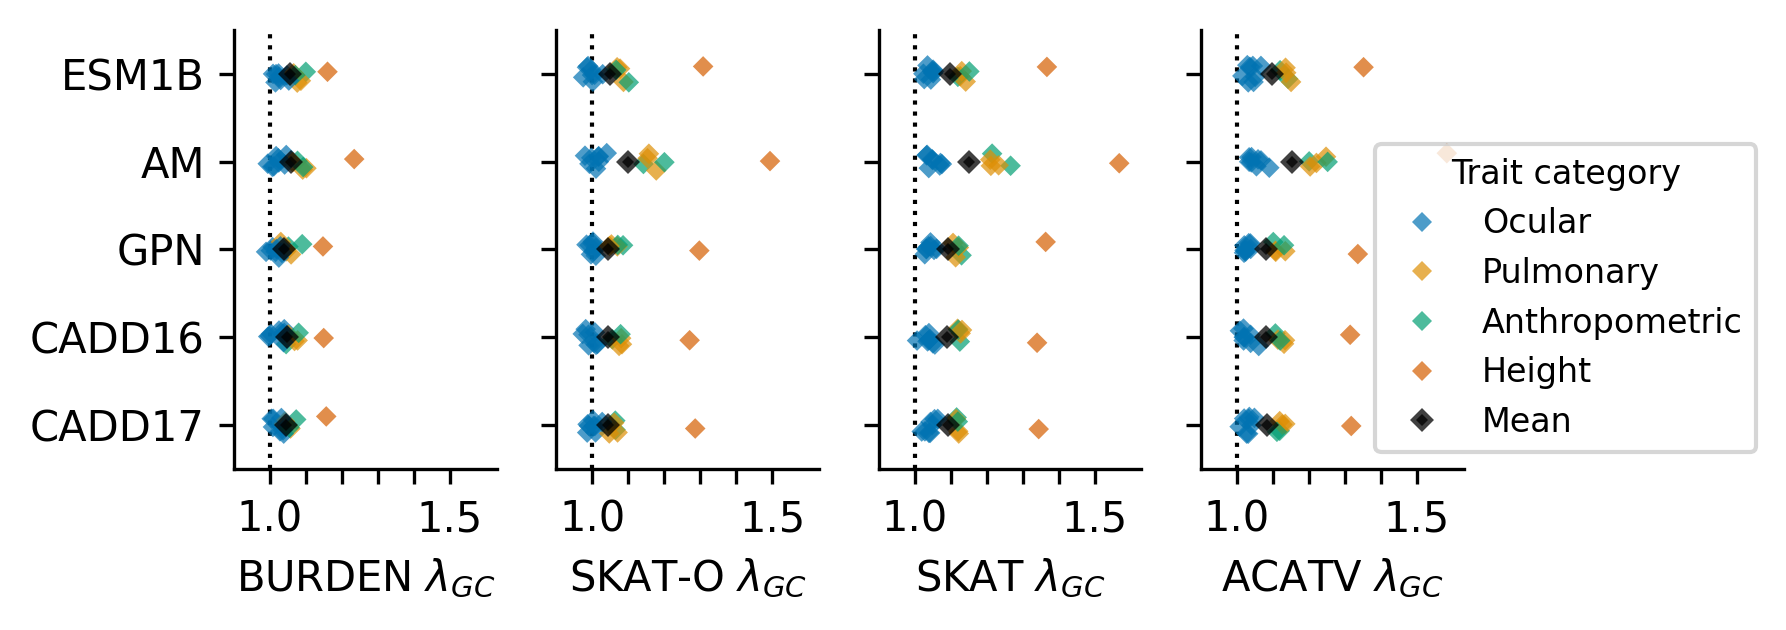

In [39]:
fig, axs = plt.subplots(1, 4, figsize=(6, 2.2))

for i, ((test, data), ax) in enumerate(
    zip(
        burden.query(
            'mask == "ben" & pop_sample == "unrelated"'
        ).groupby('test_keys', sort=False), 
        
        axs.flat)
):   
    # points
    sns.stripplot(
        data = data,
        ax = ax,
        hue = 'pheno_group',
        hue_order = GROUP_ORDER,
        palette = 'colorblind',
        marker = 'D',
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'anno',
        s = 3.5,
        alpha = 0.7,
        legend = (i == 3),
        zorder = 5,
    );

    # means
    sns.pointplot(
        data = data,
        ax = ax,
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'anno',
        linestyles = '',
        errorbar = None,
        marker = 'D',
        color = 'k',
        ms = 2,
        alpha = 0.75,
        legend = (i == 3),
        label = 'Mean',
        zorder = 6,
    );

        
    ax.axvline(1.0, linestyle='dotted', linewidth=1, color='k');
    ax.set_xlabel(' '.join([test, ax.get_xlabel()]));
    ax.set_xticks([1, 1.1, 1.2, 1.3, 1.4, 1.5], labels=['1.0','','','','','1.5']);
    ax.set_xlim(0.9, 1.63);
    if i != 0:
        ax.set_yticks(list(ax.get_yticks()), labels = ['' for _ in ax.get_yticklabels()]);
    ax.set_ylabel(None);
    if i == 3:
        ax.legend(title='Trait category', title_fontsize=8, frameon=1, fontsize=8, bbox_to_anchor=(0.6, 0.0), loc='lower left');

fig.tight_layout();
sns.despine();

plt.savefig('png/Fig2.png');

In [40]:
burden.query('mask == "ben"').groupby(['test_keys','pop_sample','anno'])['lambda_gc'].mean()

test_keys  pop_sample  anno  
ACATV      related     AM        1.180123
                       CADD16    1.096031
                       CADD17    1.095208
                       ESM1B     1.105033
                       GPN       1.102298
           unrelated   AM        1.151585
                       CADD16    1.081287
                       CADD17    1.083219
                       ESM1B     1.096589
                       GPN       1.080898
BURDEN     related     AM        1.065176
                       CADD16    1.048137
                       CADD17    1.049713
                       ESM1B     1.062709
                       GPN       1.043713
           unrelated   AM        1.058401
                       CADD16    1.045945
                       CADD17    1.043393
                       ESM1B     1.055228
                       GPN       1.038533
SKAT       related     AM        1.174486
                       CADD16    1.100826
                       CADD17    1.104756
    

### Secondary test inflation

/tmp/slurmjob.58107830/ipykernel_1775164/1901305592.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/1901305592.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/1901305592.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/1901305592.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.581078

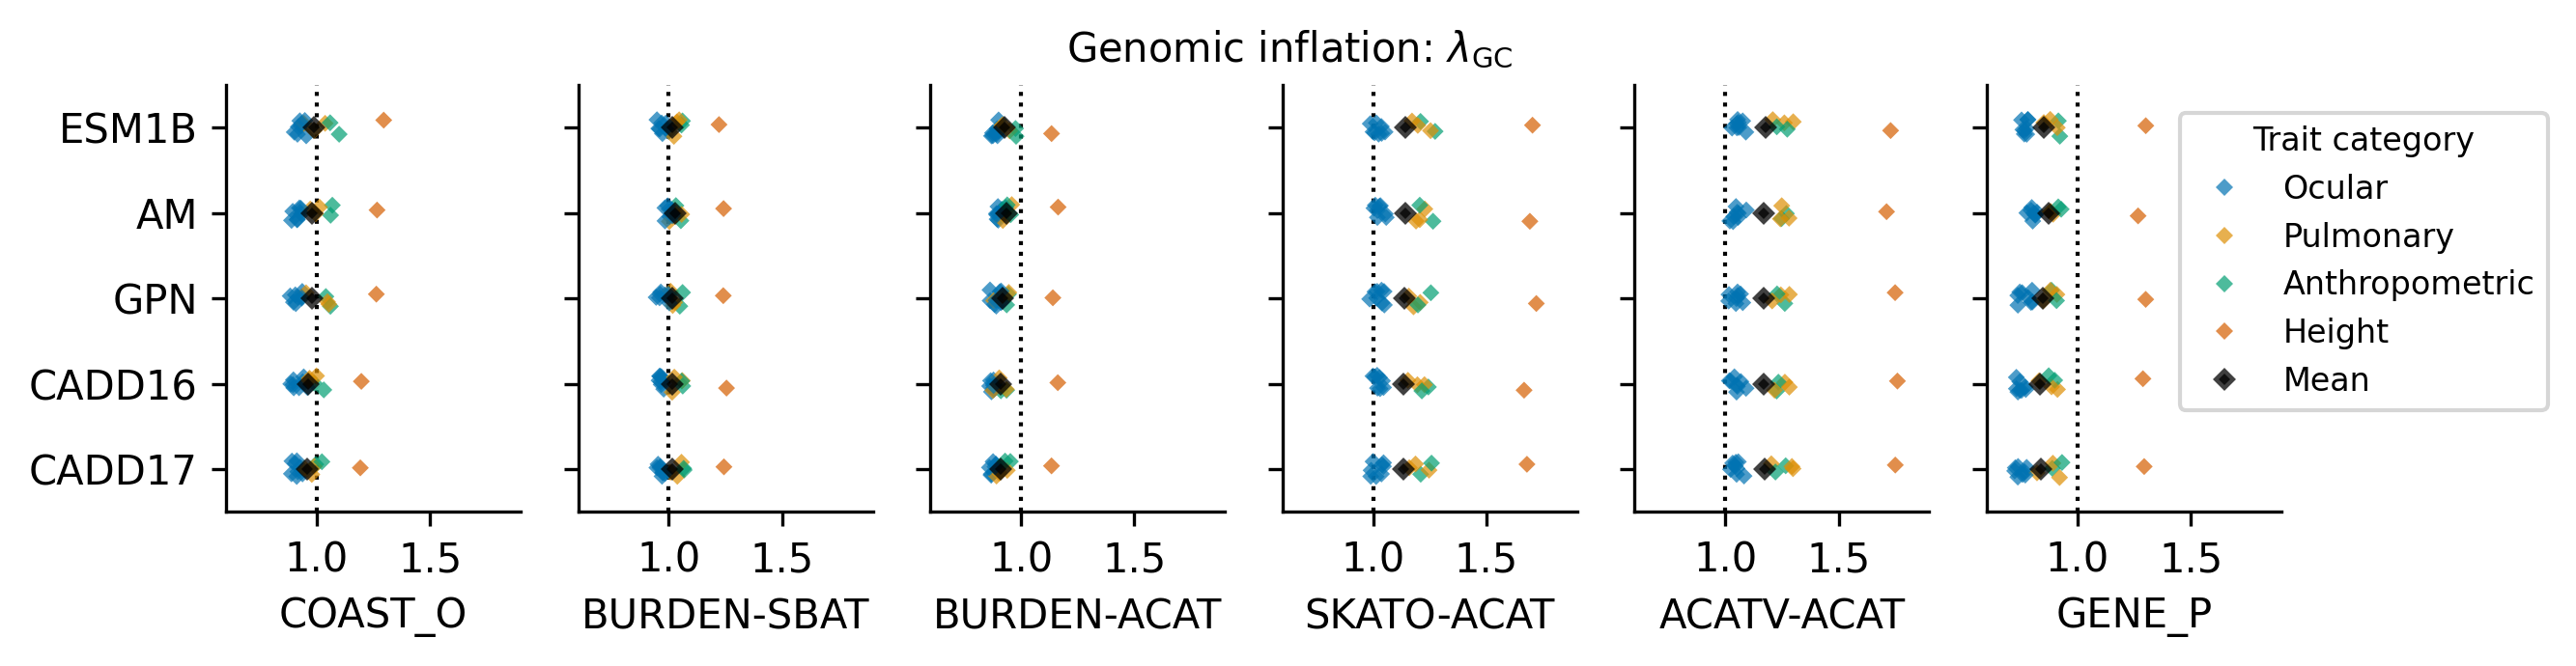

In [41]:
fig, axs = plt.subplots(1, 6, figsize=(9, 2.5))

for i, ((test, data), ax) in enumerate(
    zip(
        burden.query('mask == "bdm" & pop_sample == "unrelated"').groupby('test_keys', sort=False), 
        axs.flat[:6]
    )
):
    # points
    sns.stripplot(
        data = data,
        ax = ax,
        hue = 'pheno_group',
        hue_order = GROUP_ORDER,
        palette = 'colorblind',
        marker = 'D',
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'anno',
        s = 3,
        alpha = 0.7,
        legend = (i == axs.shape[0]-1)
    );
    ax.axvline(1.0, linestyle='dotted', linewidth=1, color='k');

    # means
    sns.pointplot(
        data = data,
        ax = ax,
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'anno',
        linestyles = '',
        errorbar = None,
        marker = 'D',
        color = 'k',
        ms = 2,
        alpha = 0.75,
        legend = (i == axs.shape[0]-1),
        label = 'Mean',
        zorder = 6,
    );
    
    ax.set_xlabel(' '.join([test]));
    ax.set_xlim(0.6, 1.9);
    if i != 0:
        ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
    ax.set_ylabel(None);
    if i == axs.shape[0]-1:
        ax.legend(frameon=1, fontsize=8, bbox_to_anchor=(0.6, 0.2), loc='lower left', title='Trait category', title_fontsize=8);

fig.suptitle('Genomic inflation: ' + r'$\lambda_\text{GC}$', fontsize=10, y=0.9);
fig.tight_layout();
sns.despine();

fig.savefig('png/supplement/secondary_inflation.png', bbox_inches='tight');

### ANOVA

In [42]:
burden['num_hits'] = burden['(p < 0.0001)']
d1 = burden.query('mask == "del"')
d2 = burden.query('mask == "bdm"')

for name,d in zip(['primary','secondary'], [d1,d2]):
    for y in ['lambda_gc','num_hits']:
        print(name, y)
        aa = sm.stats.anova_lm(smf.ols(y + ' ~ Annotation * Test * Population', data = d).fit(), typ=2)
        display(aa)
        
        print(aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True))
        
        for x in ['Annotation','Test']:
            tk = sm.stats.multicomp.pairwise_tukeyhsd(d[y], d[x], alpha = 0.05).summary()
            display(tk)
            print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

primary lambda_gc


,sum_sq,df,F,PR(>F)
Annotation,0.255847,4.0,4.892362,0.000703
Test,0.108672,3.0,2.770722,0.041037
Population,0.048131,1.0,3.681469,0.055567
Annotation:Test,0.009782,12.0,0.062352,0.999997
Annotation:Population,0.003797,4.0,0.072615,0.990392
Test:Population,0.001292,3.0,0.032930,0.991972
Annotation:Test:Population,0.001389,12.0,0.008856,1.000000
Residual,6.798374,520.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 0.256 & 4 & 4.892 & 7.0e-04 \\
Test & 0.109 & 3 & 2.771 & 4.1e-02 \\
Population & 0.048 & 1 & 3.681 & 5.6e-02 \\
Annotation:Test & 0.010 & 12 & 0.062 & 1.0e+00 \\
Annotation:Population & 0.004 & 4 & 0.073 & 9.9e-01 \\
Test:Population & 0.001 & 3 & 0.033 & 9.9e-01 \\
Annotation:Test:Population & 0.001 & 12 & 0.009 & 1.0e+00 \\
Residual & 6.798 & 520 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,0.044,0.0285,0.003,0.085,True
AM,CADD17,0.0413,0.047,0.0003,0.0823,True
AM,ESM1B,-0.0037,0.9992,-0.0447,0.0373,False
AM,GPN,0.0012,1.0,-0.0398,0.0422,False
CADD16,CADD17,-0.0026,0.9998,-0.0436,0.0383,False
CADD16,ESM1B,-0.0476,0.0134,-0.0886,-0.0066,True
CADD16,GPN,-0.0428,0.0357,-0.0838,-0.0018,True
CADD17,ESM1B,-0.045,0.0233,-0.086,-0.004,True
CADD17,GPN,-0.0402,0.058,-0.0811,0.0008,False
ESM1B,GPN,0.0048,0.9977,-0.0362,0.0458,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &       0.044       &     0.0285     &     0.003      &     0.085      &       True       \\
       AM       &      CADD17     &       0.0413      &     0.047      &     0.0003     &     0.0823     &       True       \\
       AM       &      ESM1B      &      -0.0037      &     0.9992     &    -0.0447     &     0.0373     &      False       \\
       AM       &       GPN       &       0.0012      &      1.0       &    -0.0398     &     0.0422     &      False       \\
     CADD16     &      CADD17     &      -0.0026      &     0.9998     &    -0.0436     &     0.0383     &      False       \\
     CADD16     &      ESM1B      &      -0.0476      &     0.0134     &    -0.0886     &    -0.0066     &       True       \\
     CADD16     &       GPN       &      -0.0428     

...

\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 504.279 & 4 & 0.066 & 9.9e-01 \\
Test & 59395.910 & 5 & 6.185 & 1.2e-05 \\
Population & 4601.376 & 1 & 2.396 & 1.2e-01 \\
Annotation:Test & 465.293 & 20 & 0.012 & 1.0e+00 \\
Annotation:Population & 37.183 & 4 & 0.005 & 1.0e+00 \\
Test:Population & 1083.881 & 5 & 0.113 & 9.9e-01 \\
Annotation:Test:Population & 40.845 & 20 & 0.001 & 1.0e+00 \\
Residual & 1498119.857 & 780 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-1.5536,0.9975,-14.4616,11.3544,False
AM,CADD17,-1.9167,0.9943,-14.8246,10.9913,False
AM,ESM1B,-0.0774,1.0,-12.9854,12.8306,False
AM,GPN,-1.1488,0.9992,-14.0568,11.7592,False
CADD16,CADD17,-0.3631,1.0,-13.2711,12.5449,False
CADD16,ESM1B,1.4762,0.9979,-11.4318,14.3842,False
CADD16,GPN,0.4048,1.0,-12.5032,13.3127,False
CADD17,ESM1B,1.8393,0.9951,-11.0687,14.7473,False
CADD17,GPN,0.7679,0.9998,-12.1401,13.6758,False
ESM1B,GPN,-1.0714,0.9994,-13.9794,11.8366,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &      -1.5536      &     0.9975     &    -14.4616    &    11.3544     &      False       \\
       AM       &      CADD17     &      -1.9167      &     0.9943     &    -14.8246    &    10.9913     &      False       \\
       AM       &      ESM1B      &      -0.0774      &      1.0       &    -12.9854    &    12.8306     &      False       \\
       AM       &       GPN       &      -1.1488      &     0.9992     &    -14.0568    &    11.7592     &      False       \\
     CADD16     &      CADD17     &      -0.3631      &      1.0       &    -13.2711    &    12.5449     &      False       \\
     CADD16     &      ESM1B      &       1.4762      &     0.9979     &    -11.4318    &    14.3842     &      False       \\
     CADD16     &       GPN       &       0.4048     

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV-ACAT,BURDEN-ACAT,-10.0429,0.3558,-24.5448,4.4591,False
ACATV-ACAT,BURDEN-SBAT,-10.2571,0.3316,-24.7591,4.2448,False
ACATV-ACAT,COAST_O,-20.3143,0.001,-34.8163,-5.8123,True
ACATV-ACAT,GENE_P,2.2357,0.9979,-12.2663,16.7377,False
ACATV-ACAT,SKATO-ACAT,3.0071,0.9916,-11.4948,17.5091,False
BURDEN-ACAT,BURDEN-SBAT,-0.2143,1.0,-14.7163,14.2877,False
BURDEN-ACAT,COAST_O,-10.2714,0.33,-24.7734,4.2305,False
BURDEN-ACAT,GENE_P,12.2786,0.151,-2.2234,26.7805,False
BURDEN-ACAT,SKATO-ACAT,13.05,0.1058,-1.452,27.552,False
BURDEN-SBAT,COAST_O,-10.0571,0.3542,-24.5591,4.4448,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
   ACATV-ACAT   &   BURDEN-ACAT   &      -10.0429     &     0.3558     &    -24.5448    &     4.4591     &      False       \\
   ACATV-ACAT   &   BURDEN-SBAT   &      -10.2571     &     0.3316     &    -24.7591    &     4.2448     &      False       \\
   ACATV-ACAT   &     COAST\_O    &      -20.3143     &     0.001      &    -34.8163    &    -5.8123     &       True       \\
   ACATV-ACAT   &     GENE\_P     &       2.2357      &     0.9979     &    -12.2663    &    16.7377     &      False       \\
   ACATV-ACAT   &    SKATO-ACAT   &       3.0071      &     0.9916     &    -11.4948    &    17.5091     &      False       \\
  BURDEN-ACAT   &   BURDEN-SBAT   &      -0.2143      &      1.0       &    -14.7163    &    14.2877     &      False       \\
  BURDEN-ACAT   &     COAST\_O    &      -10.2714    

#### Robust

In [43]:
burden['num_hits'] = burden['(p < 0.0001)']
d1 = burden.query('mask == "del"')
d2 = burden.query('mask == "bdm"')

for name,d in zip(['primary','secondary'], [d1,d2]):
    for y in ['lambda_gc','num_hits']:
        print(name, y)
        aa = sm.stats.anova_lm(smf.ols(y + ' ~ Annotation * Test * Population', data = d).fit(), typ=2, robust = 'hc3')
        display(aa)
        
        print(aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True))
        
        for x in ['Annotation','Test']:
            tk = sm.stats.multicomp.pairwise_tukeyhsd(d[y], d[x], alpha = 0.05).summary()
            display(tk)
            print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

primary lambda_gc


,sum_sq,df,F,PR(>F)
Annotation,0.204496,4.0,3.910414,0.003870
Test,0.103407,3.0,2.636486,0.049052
Population,0.044649,1.0,3.415129,0.065169
Annotation:Test,0.011324,12.0,0.072182,0.999993
Annotation:Population,0.003634,4.0,0.069487,0.991165
Test:Population,0.002215,3.0,0.056473,0.982348
Annotation:Test:Population,0.001266,12.0,0.008072,1.000000
Residual,6.798374,520.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 0.204 & 4 & 3.910 & 3.9e-03 \\
Test & 0.103 & 3 & 2.636 & 4.9e-02 \\
Population & 0.045 & 1 & 3.415 & 6.5e-02 \\
Annotation:Test & 0.011 & 12 & 0.072 & 1.0e+00 \\
Annotation:Population & 0.004 & 4 & 0.069 & 9.9e-01 \\
Test:Population & 0.002 & 3 & 0.056 & 9.8e-01 \\
Annotation:Test:Population & 0.001 & 12 & 0.008 & 1.0e+00 \\
Residual & 6.798 & 520 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,0.044,0.0285,0.003,0.085,True
AM,CADD17,0.0413,0.047,0.0003,0.0823,True
AM,ESM1B,-0.0037,0.9992,-0.0447,0.0373,False
AM,GPN,0.0012,1.0,-0.0398,0.0422,False
CADD16,CADD17,-0.0026,0.9998,-0.0436,0.0383,False
CADD16,ESM1B,-0.0476,0.0134,-0.0886,-0.0066,True
CADD16,GPN,-0.0428,0.0357,-0.0838,-0.0018,True
CADD17,ESM1B,-0.045,0.0233,-0.086,-0.004,True
CADD17,GPN,-0.0402,0.058,-0.0811,0.0008,False
ESM1B,GPN,0.0048,0.9977,-0.0362,0.0458,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &       0.044       &     0.0285     &     0.003      &     0.085      &       True       \\
       AM       &      CADD17     &       0.0413      &     0.047      &     0.0003     &     0.0823     &       True       \\
       AM       &      ESM1B      &      -0.0037      &     0.9992     &    -0.0447     &     0.0373     &      False       \\
       AM       &       GPN       &       0.0012      &      1.0       &    -0.0398     &     0.0422     &      False       \\
     CADD16     &      CADD17     &      -0.0026      &     0.9998     &    -0.0436     &     0.0383     &      False       \\
     CADD16     &      ESM1B      &      -0.0476      &     0.0134     &    -0.0886     &    -0.0066     &       True       \\
     CADD16     &       GPN       &      -0.0428     

...

\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 13707.378 & 4 & 1.784 & 1.3e-01 \\
Test & 151606.126 & 5 & 15.787 & 7.9e-15 \\
Population & 2971.148 & 1 & 1.547 & 2.1e-01 \\
Annotation:Test & 1265.700 & 20 & 0.033 & 1.0e+00 \\
Annotation:Population & 728.446 & 4 & 0.095 & 9.8e-01 \\
Test:Population & 2121.258 & 5 & 0.221 & 9.5e-01 \\
Annotation:Test:Population & 122.506 & 20 & 0.003 & 1.0e+00 \\
Residual & 1498119.857 & 780 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-1.5536,0.9975,-14.4616,11.3544,False
AM,CADD17,-1.9167,0.9943,-14.8246,10.9913,False
AM,ESM1B,-0.0774,1.0,-12.9854,12.8306,False
AM,GPN,-1.1488,0.9992,-14.0568,11.7592,False
CADD16,CADD17,-0.3631,1.0,-13.2711,12.5449,False
CADD16,ESM1B,1.4762,0.9979,-11.4318,14.3842,False
CADD16,GPN,0.4048,1.0,-12.5032,13.3127,False
CADD17,ESM1B,1.8393,0.9951,-11.0687,14.7473,False
CADD17,GPN,0.7679,0.9998,-12.1401,13.6758,False
ESM1B,GPN,-1.0714,0.9994,-13.9794,11.8366,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &      -1.5536      &     0.9975     &    -14.4616    &    11.3544     &      False       \\
       AM       &      CADD17     &      -1.9167      &     0.9943     &    -14.8246    &    10.9913     &      False       \\
       AM       &      ESM1B      &      -0.0774      &      1.0       &    -12.9854    &    12.8306     &      False       \\
       AM       &       GPN       &      -1.1488      &     0.9992     &    -14.0568    &    11.7592     &      False       \\
     CADD16     &      CADD17     &      -0.3631      &      1.0       &    -13.2711    &    12.5449     &      False       \\
     CADD16     &      ESM1B      &       1.4762      &     0.9979     &    -11.4318    &    14.3842     &      False       \\
     CADD16     &       GPN       &       0.4048     

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV-ACAT,BURDEN-ACAT,-10.0429,0.3558,-24.5448,4.4591,False
ACATV-ACAT,BURDEN-SBAT,-10.2571,0.3316,-24.7591,4.2448,False
ACATV-ACAT,COAST_O,-20.3143,0.001,-34.8163,-5.8123,True
ACATV-ACAT,GENE_P,2.2357,0.9979,-12.2663,16.7377,False
ACATV-ACAT,SKATO-ACAT,3.0071,0.9916,-11.4948,17.5091,False
BURDEN-ACAT,BURDEN-SBAT,-0.2143,1.0,-14.7163,14.2877,False
BURDEN-ACAT,COAST_O,-10.2714,0.33,-24.7734,4.2305,False
BURDEN-ACAT,GENE_P,12.2786,0.151,-2.2234,26.7805,False
BURDEN-ACAT,SKATO-ACAT,13.05,0.1058,-1.452,27.552,False
BURDEN-SBAT,COAST_O,-10.0571,0.3542,-24.5591,4.4448,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
   ACATV-ACAT   &   BURDEN-ACAT   &      -10.0429     &     0.3558     &    -24.5448    &     4.4591     &      False       \\
   ACATV-ACAT   &   BURDEN-SBAT   &      -10.2571     &     0.3316     &    -24.7591    &     4.2448     &      False       \\
   ACATV-ACAT   &     COAST\_O    &      -20.3143     &     0.001      &    -34.8163    &    -5.8123     &       True       \\
   ACATV-ACAT   &     GENE\_P     &       2.2357      &     0.9979     &    -12.2663    &    16.7377     &      False       \\
   ACATV-ACAT   &    SKATO-ACAT   &       3.0071      &     0.9916     &    -11.4948    &    17.5091     &      False       \\
  BURDEN-ACAT   &   BURDEN-SBAT   &      -0.2143      &      1.0       &    -14.7163    &    14.2877     &      False       \\
  BURDEN-ACAT   &     COAST\_O    &      -10.2714    

In [44]:
help(sm.stats.multicomp.tukeyhsd)

Help on function tukeyhsd in module statsmodels.sandbox.stats.multicomp:

tukeyhsd(mean_all, nobs_all, var_all, df=None, alpha=0.05, q_crit=None)
    simultaneous Tukey HSD


    check: instead of sorting, I use absolute value of pairwise differences
    in means. That's irrelevant for the test, but maybe reporting actual
    differences would be better.
    CHANGED: meandiffs are with sign, studentized range uses abs

    q_crit added for testing

    TODO: error in variance calculation when nobs_all is scalar, missing 1/n



### Related cohort

/tmp/slurmjob.58107830/ipykernel_1775164/1569320196.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/1569320196.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/1569320196.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/1569320196.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107

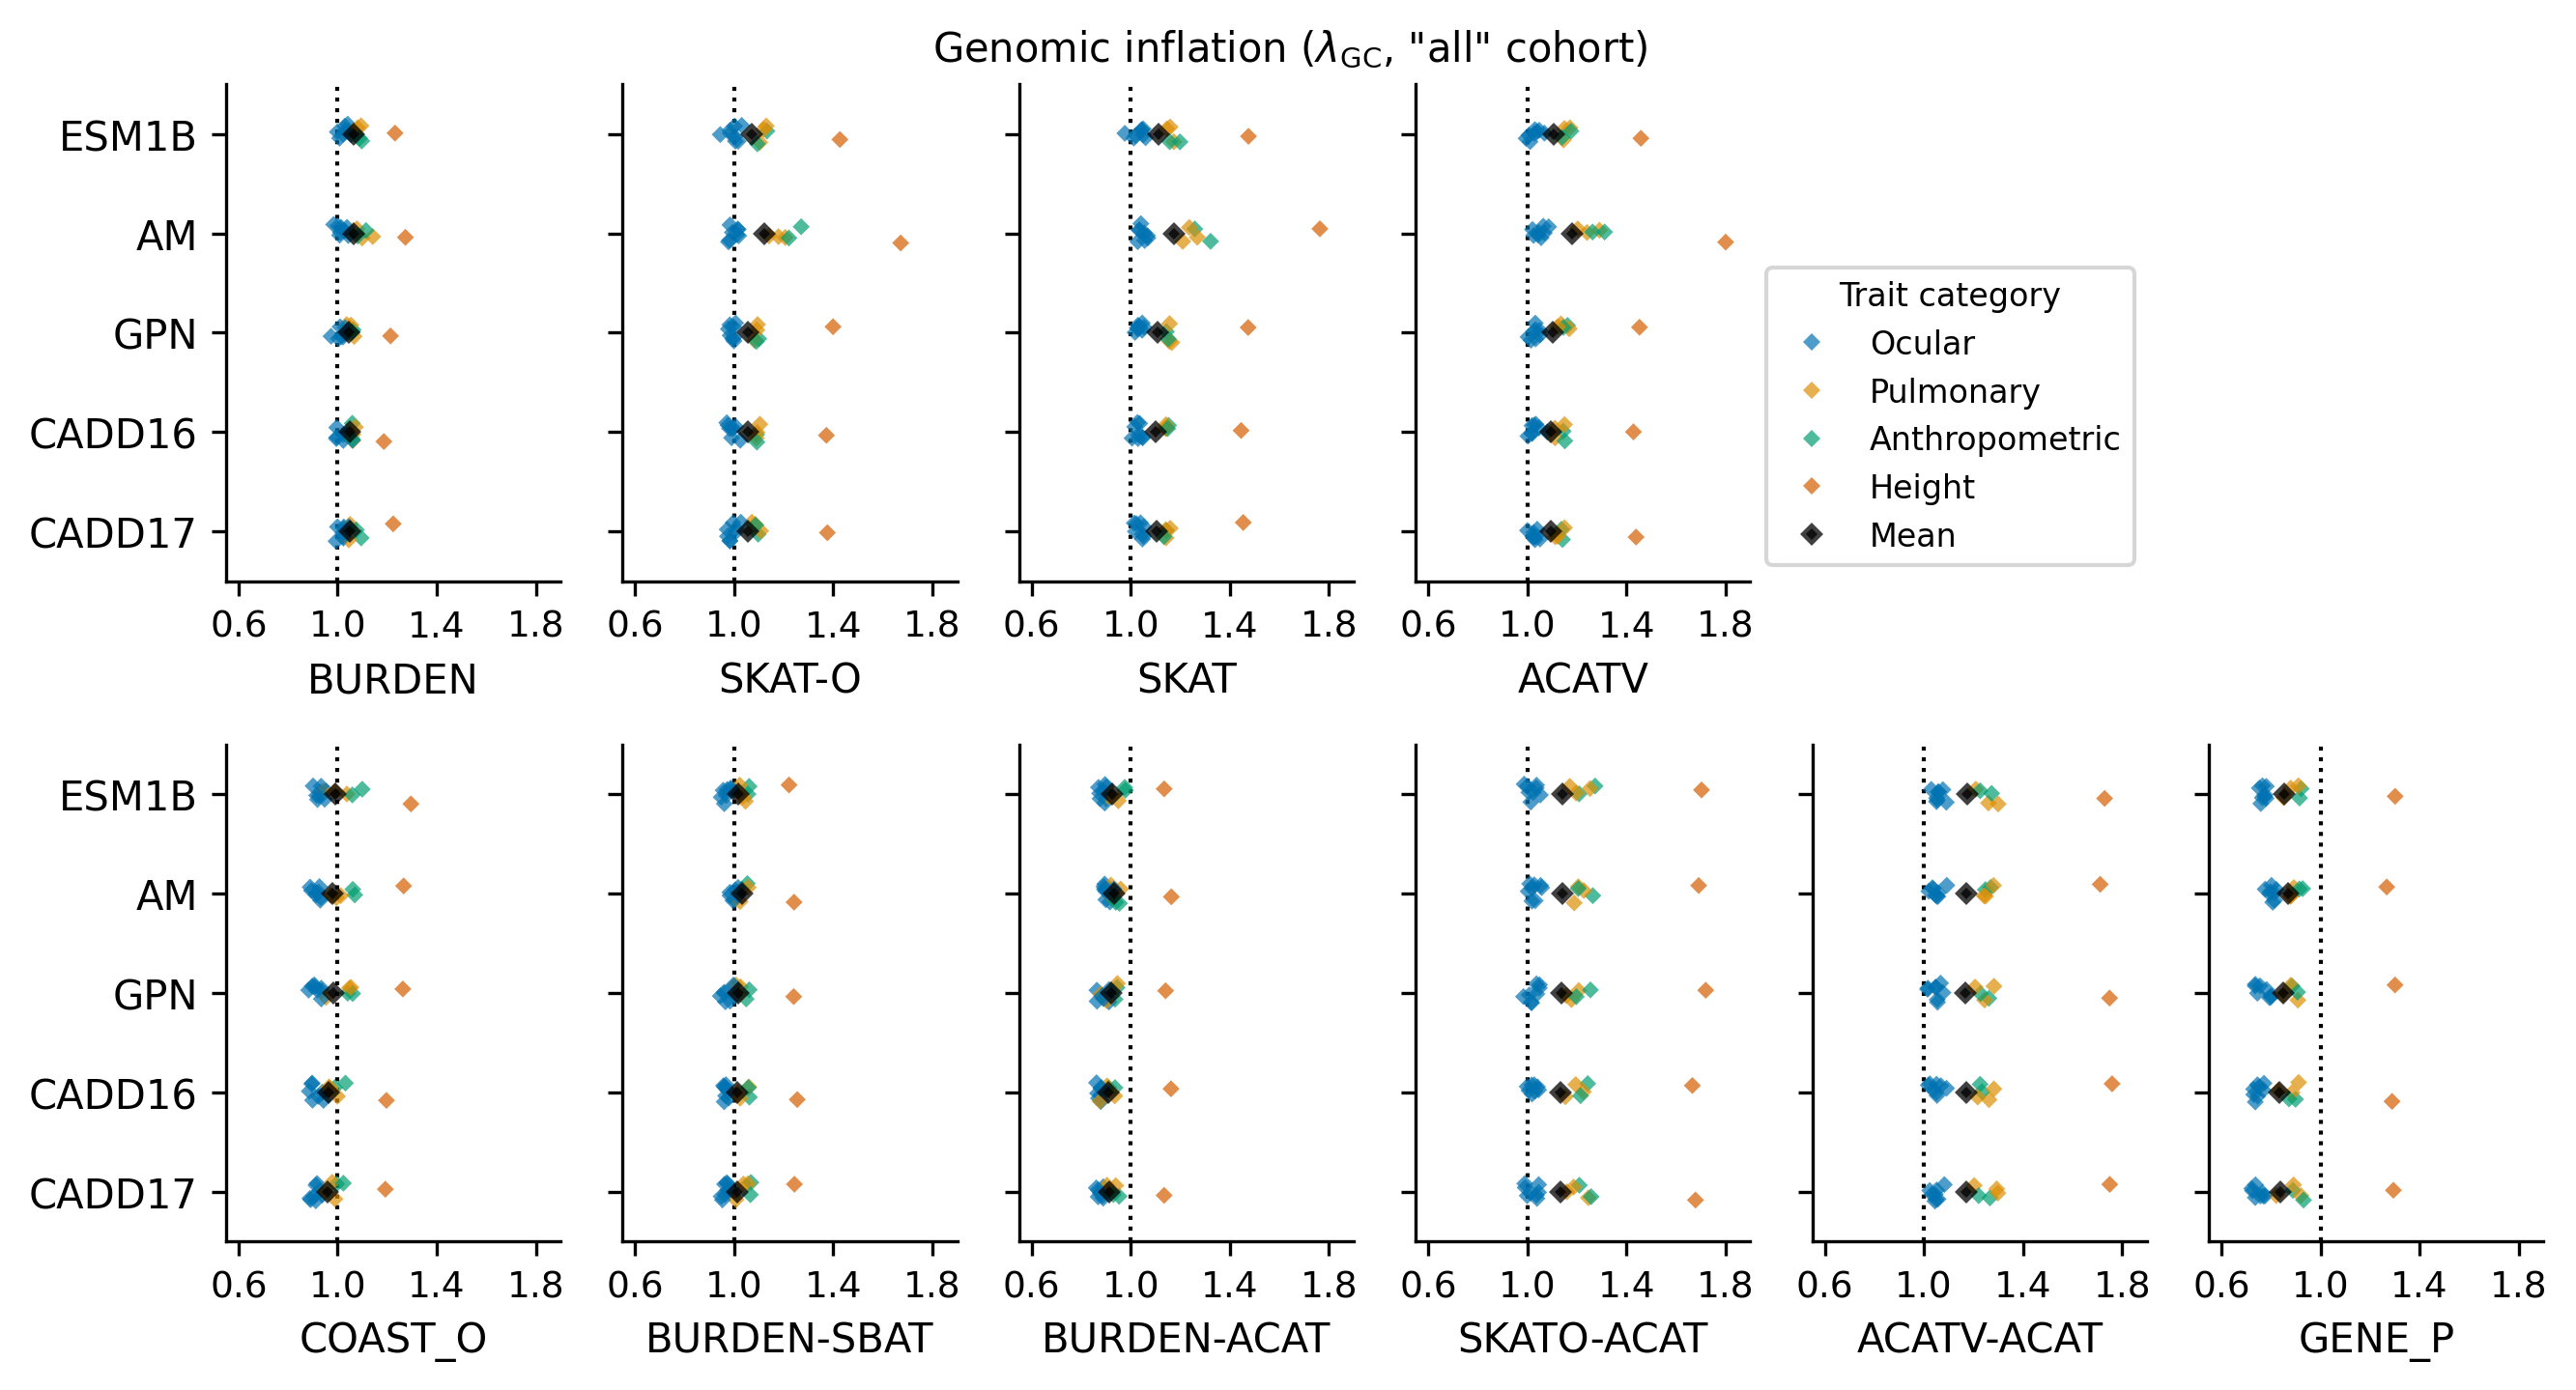

In [45]:
fig, axs = plt.subplots(2, 6, figsize=(9, 5))

## primary tests
for i, ((test, data), ax) in enumerate(
    zip(
        burden.query(
            'mask == "ben" & pop_sample == "related"'
        ).groupby('test_keys', sort=False), 
        
        axs[0,:4].flat)
):
   
    # points
    sns.stripplot(
        data = data,
        ax = ax,
        hue = 'pheno_group',
        hue_order = GROUP_ORDER,
        palette = 'colorblind',
        marker = 'D',
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'anno',
        s = 3,
        alpha = 0.7,
        legend = (i == 3)
    );

    # means
    sns.pointplot(
        data = data,
        ax = ax,
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'anno',
        linestyles = '',
        errorbar = None,
        marker = 'D',
        color = 'k',
        ms = 2,
        alpha = 0.75,
        legend = None,
        label = 'Mean',
        zorder = 6,
    );
    
    ax.axvline(1.0, linestyle='dotted', linewidth=1, color='k');
    ax.set_xlabel(' '.join([test]));
    ax.set_xlim(0.55, 1.9);
    ax.set_xticks([0.6, 1.0, 1.4, 1.8]); ax.tick_params(axis='x', labelsize=9);
    if i != 0:
        ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
    ax.set_ylabel(None);
    if i == 3:
        ax.legend(title='Trait category', title_fontsize=8, frameon=1, fontsize=8, bbox_to_anchor=(1.0, 0.0), loc='lower left');

axs[0,4].set_visible(0);
axs[0,5].set_visible(0);

for i, ((test, data), ax) in enumerate(
    zip(
        burden.query('mask == "bdm" & pop_sample == "unrelated"').groupby('test_keys', sort=False), 
        axs[1,:6]
    )
):
    # points
    sns.stripplot(
        data = data,
        ax = ax,
        hue = 'pheno_group',
        hue_order = GROUP_ORDER,
        palette = 'colorblind',
        marker = 'D',
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'anno',
        s = 3,
        alpha = 0.7,
        legend = False
    );

    # means
    sns.pointplot(
        data = data,
        ax = ax,
        x = r'$\lambda_{GC}$',
        order = ANNO_ORDER,
        y = 'anno',
        linestyles = '',
        errorbar = None,
        marker = 'D',
        color = 'k',
        ms = 2,
        alpha = 0.75,
        legend = None,
        label = 'Mean',
        zorder = 6,
    );
    
    ax.axvline(1.0, linestyle='dotted', linewidth=1, color='k');
    ax.set_xlabel(' '.join([test]));
    ax.set_xlim(0.55, 1.9);
    ax.set_xticks([0.6, 1.0, 1.4, 1.8]); ax.tick_params(axis='x', labelsize=9);
    if i != 0:
        ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
    ax.set_ylabel(None);

fig.suptitle('Genomic inflation ({}, "all" cohort)'.format(r'$\lambda_\text{GC}$'), fontsize=10, y=0.95);
fig.tight_layout(w_pad=-8);
sns.despine();

fig.savefig('png/supplement/all_inflation.png', bbox_inches='tight');

## Distributional calibration and power

### Figure 3B

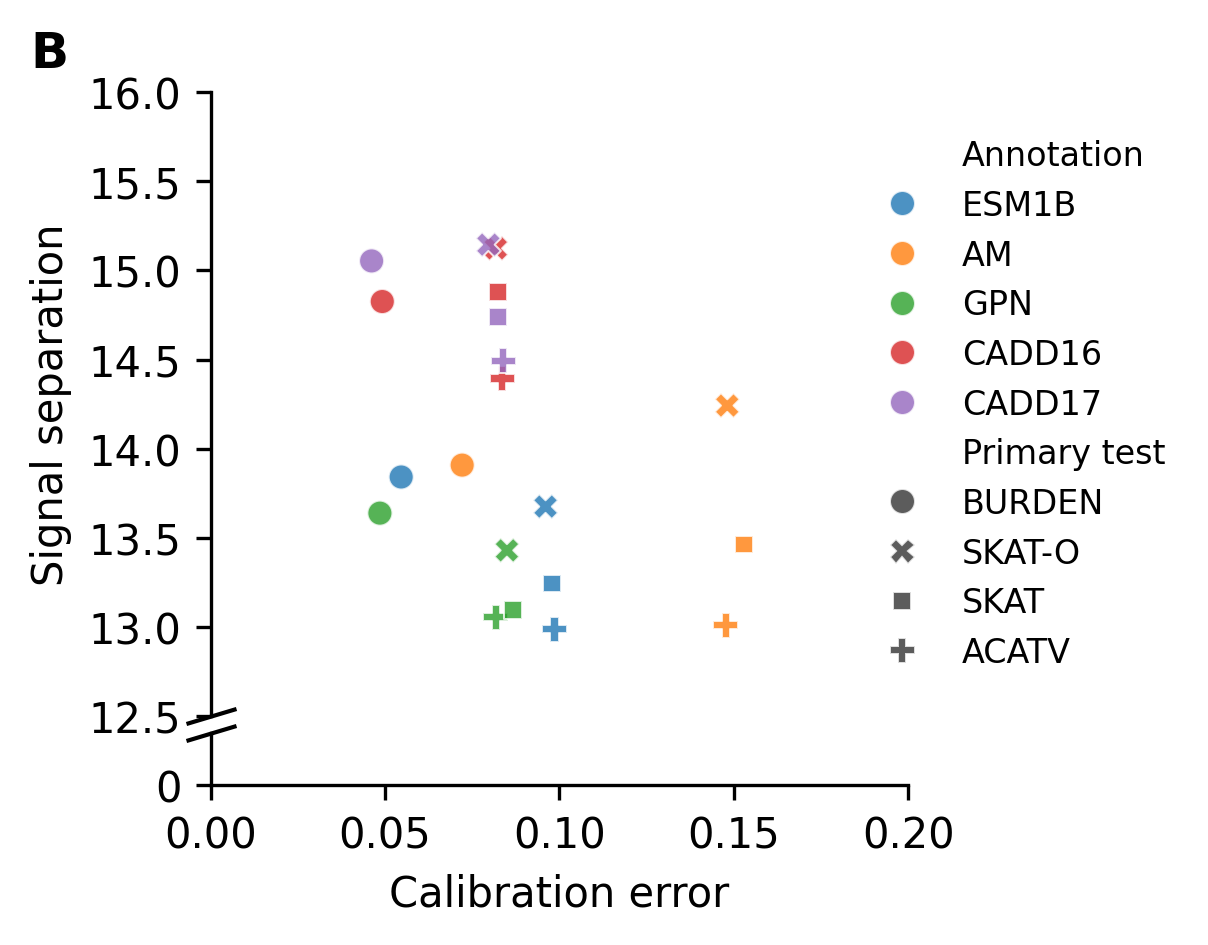

In [46]:
fig, (ax, ax_break) = plt.subplots(2, 1, figsize=(3,3), sharex=True, gridspec_kw={'height_ratios': [12, 1]})
fig.subplots_adjust(hspace=0.05)

stderr = False

w1_gb = w1.query(
    'pop_sample == "unrelated"'
).groupby(
    ['test_keys', 'anno']
)[['Calibration error','Signal separation']]

means = w1_gb.mean().reset_index()
ses = (w1_gb.std() / w1_gb.count()).reset_index()

if stderr:
    for anno in ANNO_ORDER:
        mu, sig = means.query('anno == @anno'), ses.query('anno == @anno')
        ax.errorbar(
            x = mu['Calibration error'],
            y = mu['Signal separation'],
            xerr = sig['Calibration error'],
            yerr = sig['Signal separation'],
            ms = 0,
            fmt='o', 
            capsize=1, 
            elinewidth=0.8, 
            alpha=0.7
        );

means['Annotation'] = means['anno']
means['Primary test'] = means['test_keys']

sns.scatterplot(
    ax = ax,
    data = means,
    x = 'Calibration error',
    y = 'Signal separation',
    hue = 'Annotation',
    hue_order = ANNO_ORDER,
    style = 'Primary test',
    style_order = TEST_ORDER1,
    alpha = 0.8,
)

ax.set_xlim(0, 0.2);
ax.set_ylim(12.5, 16);

sns.move_legend(ax, loc = 'center left', bbox_to_anchor = (0.9, 0.5), fontsize = 8, frameon = 0);



# hack together the axis break
sns.scatterplot(
    x = 'Calibration error',
    y = 'Signal separation',
    data = means,
    ax = ax_break,
    legend = 0,
); 
ax_break.set_ylim(0, 0.5);
ax_break.set_yticks([0]);
ax_break.set_ylabel(None);
# slanted line 
d = .3  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax.plot([0], [0], transform=ax.transAxes, **kwargs)
ax_break.plot([0], [1], transform=ax_break.transAxes, **kwargs)

sns.despine();
ax.xaxis.set_visible(False);
ax.spines[['bottom']].set_visible(False);

fig.text(-0.075, 0.95, 'B', ha='left', va='top', fontsize=12, fontweight='bold')

plt.savefig('png/Fig3B.png', bbox_inches='tight');

### ANOVA

In [47]:
w1['calib_error'] = w1['Calibration error']
w1['signal_sep'] = w1['Signal separation']


for y in ['calib_error','signal_sep']:
    print(y)
    aa = sm.stats.anova_lm(smf.ols(y + ' ~ Annotation * Test * Population', data = w1).fit(), typ=2)
    display(aa)
        
    print(
        aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True)
    )
        
    for x in ['anno','test_keys']:
        tk = sm.stats.multicomp.pairwise_tukeyhsd(w1[y], w1[x], alpha = 0.05).summary()
        display(tk)
        print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

calib_error


,sum_sq,df,F,PR(>F)
Annotation,0.328721,4.0,5.081174,0.000505
Test,0.270687,3.0,5.578818,0.000900
Population,0.046770,1.0,2.891800,0.089629
Annotation:Test,0.036093,12.0,0.185970,0.998920
Annotation:Population,0.003633,4.0,0.056153,0.994127
Test:Population,0.003385,3.0,0.069769,0.976047
Annotation:Test:Population,0.000458,12.0,0.002360,1.000000
Residual,8.410206,520.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 0.329 & 4 & 5.081 & 5.0e-04 \\
Test & 0.271 & 3 & 5.579 & 9.0e-04 \\
Population & 0.047 & 1 & 2.892 & 9.0e-02 \\
Annotation:Test & 0.036 & 12 & 0.186 & 1.0e+00 \\
Annotation:Population & 0.004 & 4 & 0.056 & 9.9e-01 \\
Test:Population & 0.003 & 3 & 0.070 & 9.8e-01 \\
Annotation:Test:Population & 0.000 & 12 & 0.002 & 1.0e+00 \\
Residual & 8.410 & 520 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-0.0623,0.0021,-0.1083,-0.0163,True
AM,CADD17,-0.0642,0.0014,-0.1102,-0.0183,True
AM,ESM1B,-0.0483,0.0338,-0.0943,-0.0023,True
AM,GPN,-0.0609,0.0029,-0.1069,-0.0149,True
CADD16,CADD17,-0.0019,1.0,-0.0479,0.044,False
CADD16,ESM1B,0.014,0.9206,-0.032,0.06,False
CADD16,GPN,0.0014,1.0,-0.0446,0.0474,False
CADD17,ESM1B,0.0159,0.8784,-0.0301,0.0619,False
CADD17,GPN,0.0033,0.9997,-0.0427,0.0493,False
ESM1B,GPN,-0.0126,0.9447,-0.0586,0.0334,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &      -0.0623      &     0.0021     &    -0.1083     &    -0.0163     &       True       \\
       AM       &      CADD17     &      -0.0642      &     0.0014     &    -0.1102     &    -0.0183     &       True       \\
       AM       &      ESM1B      &      -0.0483      &     0.0338     &    -0.0943     &    -0.0023     &       True       \\
       AM       &       GPN       &      -0.0609      &     0.0029     &    -0.1069     &    -0.0149     &       True       \\
     CADD16     &      CADD17     &      -0.0019      &      1.0       &    -0.0479     &     0.044      &      False       \\
     CADD16     &      ESM1B      &       0.014       &     0.9206     &     -0.032     &      0.06      &      False       \\
     CADD16     &       GPN       &       0.0014     

...

\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 223.512 & 4 & 15.254 & 8.4e-12 \\
Test & 45.990 & 3 & 4.185 & 6.1e-03 \\
Population & 10.783 & 1 & 2.944 & 8.7e-02 \\
Annotation:Test & 4.992 & 12 & 0.114 & 1.0e+00 \\
Annotation:Population & 2.892 & 4 & 0.197 & 9.4e-01 \\
Test:Population & 0.879 & 3 & 0.080 & 9.7e-01 \\
Annotation:Test:Population & 1.508 & 12 & 0.034 & 1.0e+00 \\
Residual & 1904.831 & 520 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,1.1397,0.0001,0.4503,1.829,True
AM,CADD17,1.1697,0.0,0.4804,1.8591,True
AM,ESM1B,-0.1988,0.9337,-0.8881,0.4906,False
AM,GPN,-0.1818,0.9514,-0.8712,0.5075,False
CADD16,CADD17,0.0301,1.0,-0.6593,0.7194,False
CADD16,ESM1B,-1.3384,0.0,-2.0278,-0.6491,True
CADD16,GPN,-1.3215,0.0,-2.0108,-0.6322,True
CADD17,ESM1B,-1.3685,0.0,-2.0579,-0.6792,True
CADD17,GPN,-1.3516,0.0,-2.0409,-0.6622,True
ESM1B,GPN,0.0169,1.0,-0.6724,0.7063,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &       1.1397      &     0.0001     &     0.4503     &     1.829      &       True       \\
       AM       &      CADD17     &       1.1697      &      0.0       &     0.4804     &     1.8591     &       True       \\
       AM       &      ESM1B      &      -0.1988      &     0.9337     &    -0.8881     &     0.4906     &      False       \\
       AM       &       GPN       &      -0.1818      &     0.9514     &    -0.8712     &     0.5075     &      False       \\
     CADD16     &      CADD17     &       0.0301      &      1.0       &    -0.6593     &     0.7194     &      False       \\
     CADD16     &      ESM1B      &      -1.3384      &      0.0       &    -2.0278     &    -0.6491     &       True       \\
     CADD16     &       GPN       &      -1.3215     

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV,BURDEN,0.6509,0.0295,0.0454,1.2565,True
ACATV,SKAT,0.2016,0.8266,-0.404,0.8071,False
ACATV,SKAT-O,0.6609,0.0261,0.0553,1.2664,True
BURDEN,SKAT,-0.4493,0.2241,-1.0549,0.1562,False
BURDEN,SKAT-O,0.0099,1.0,-0.5956,0.6155,False
SKAT,SKAT-O,0.4593,0.2068,-0.1463,1.0648,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
     ACATV      &      BURDEN     &       0.6509      &     0.0295     &     0.0454     &     1.2565     &       True       \\
     ACATV      &       SKAT      &       0.2016      &     0.8266     &     -0.404     &     0.8071     &      False       \\
     ACATV      &      SKAT-O     &       0.6609      &     0.0261     &     0.0553     &     1.2664     &       True       \\
     BURDEN     &       SKAT      &      -0.4493      &     0.2241     &    -1.0549     &     0.1562     &      False       \\
     BURDEN     &      SKAT-O     &       0.0099      &      1.0       &    -0.5956     &     0.6155     &      False       \\
      SKAT      &      SKAT-O     &       0.4593      &     0.2068     &    -0.1463     &     1.0648     &      False       \\
\bottomrule
\end{tabular}
%\caption{Multiple Comparis

#### Robust

In [48]:
w1['calib_error'] = w1['Calibration error']
w1['signal_sep'] = w1['Signal separation']


for y in ['calib_error','signal_sep']:
    print(y)
    aa = sm.stats.anova_lm(smf.ols(y + ' ~ Annotation * Test * Population', data = w1).fit(), typ=2, robust = 'hc3')
    display(aa)
        
    print(
        aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True)
    )
        
    for x in ['anno','test_keys']:
        tk = sm.stats.multicomp.pairwise_tukeyhsd(w1[y], w1[x], alpha = 0.05).summary()
        display(tk)
        print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

calib_error


,sum_sq,df,F,PR(>F)
Annotation,0.149430,4.0,2.309807,0.056855
Test,0.454109,3.0,9.359132,0.000005
Population,0.041024,1.0,2.536528,0.111847
Annotation:Test,0.037428,12.0,0.192847,0.998703
Annotation:Population,0.001860,4.0,0.028756,0.998403
Test:Population,0.005879,3.0,0.121171,0.947628
Annotation:Test:Population,0.000457,12.0,0.002352,1.000000
Residual,8.410206,520.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 0.149 & 4 & 2.310 & 5.7e-02 \\
Test & 0.454 & 3 & 9.359 & 4.9e-06 \\
Population & 0.041 & 1 & 2.537 & 1.1e-01 \\
Annotation:Test & 0.037 & 12 & 0.193 & 1.0e+00 \\
Annotation:Population & 0.002 & 4 & 0.029 & 1.0e+00 \\
Test:Population & 0.006 & 3 & 0.121 & 9.5e-01 \\
Annotation:Test:Population & 0.000 & 12 & 0.002 & 1.0e+00 \\
Residual & 8.410 & 520 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-0.0623,0.0021,-0.1083,-0.0163,True
AM,CADD17,-0.0642,0.0014,-0.1102,-0.0183,True
AM,ESM1B,-0.0483,0.0338,-0.0943,-0.0023,True
AM,GPN,-0.0609,0.0029,-0.1069,-0.0149,True
CADD16,CADD17,-0.0019,1.0,-0.0479,0.044,False
CADD16,ESM1B,0.014,0.9206,-0.032,0.06,False
CADD16,GPN,0.0014,1.0,-0.0446,0.0474,False
CADD17,ESM1B,0.0159,0.8784,-0.0301,0.0619,False
CADD17,GPN,0.0033,0.9997,-0.0427,0.0493,False
ESM1B,GPN,-0.0126,0.9447,-0.0586,0.0334,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &      -0.0623      &     0.0021     &    -0.1083     &    -0.0163     &       True       \\
       AM       &      CADD17     &      -0.0642      &     0.0014     &    -0.1102     &    -0.0183     &       True       \\
       AM       &      ESM1B      &      -0.0483      &     0.0338     &    -0.0943     &    -0.0023     &       True       \\
       AM       &       GPN       &      -0.0609      &     0.0029     &    -0.1069     &    -0.0149     &       True       \\
     CADD16     &      CADD17     &      -0.0019      &      1.0       &    -0.0479     &     0.044      &      False       \\
     CADD16     &      ESM1B      &       0.014       &     0.9206     &     -0.032     &      0.06      &      False       \\
     CADD16     &       GPN       &       0.0014     

...

\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 214.087 & 4 & 14.611 & 2.6e-11 \\
Test & 52.529 & 3 & 4.780 & 2.7e-03 \\
Population & 10.616 & 1 & 2.898 & 8.9e-02 \\
Annotation:Test & 5.141 & 12 & 0.117 & 1.0e+00 \\
Annotation:Population & 2.334 & 4 & 0.159 & 9.6e-01 \\
Test:Population & 1.355 & 3 & 0.123 & 9.5e-01 \\
Annotation:Test:Population & 1.784 & 12 & 0.041 & 1.0e+00 \\
Residual & 1904.831 & 520 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,1.1397,0.0001,0.4503,1.829,True
AM,CADD17,1.1697,0.0,0.4804,1.8591,True
AM,ESM1B,-0.1988,0.9337,-0.8881,0.4906,False
AM,GPN,-0.1818,0.9514,-0.8712,0.5075,False
CADD16,CADD17,0.0301,1.0,-0.6593,0.7194,False
CADD16,ESM1B,-1.3384,0.0,-2.0278,-0.6491,True
CADD16,GPN,-1.3215,0.0,-2.0108,-0.6322,True
CADD17,ESM1B,-1.3685,0.0,-2.0579,-0.6792,True
CADD17,GPN,-1.3516,0.0,-2.0409,-0.6622,True
ESM1B,GPN,0.0169,1.0,-0.6724,0.7063,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &       1.1397      &     0.0001     &     0.4503     &     1.829      &       True       \\
       AM       &      CADD17     &       1.1697      &      0.0       &     0.4804     &     1.8591     &       True       \\
       AM       &      ESM1B      &      -0.1988      &     0.9337     &    -0.8881     &     0.4906     &      False       \\
       AM       &       GPN       &      -0.1818      &     0.9514     &    -0.8712     &     0.5075     &      False       \\
     CADD16     &      CADD17     &       0.0301      &      1.0       &    -0.6593     &     0.7194     &      False       \\
     CADD16     &      ESM1B      &      -1.3384      &      0.0       &    -2.0278     &    -0.6491     &       True       \\
     CADD16     &       GPN       &      -1.3215     

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV,BURDEN,0.6509,0.0295,0.0454,1.2565,True
ACATV,SKAT,0.2016,0.8266,-0.404,0.8071,False
ACATV,SKAT-O,0.6609,0.0261,0.0553,1.2664,True
BURDEN,SKAT,-0.4493,0.2241,-1.0549,0.1562,False
BURDEN,SKAT-O,0.0099,1.0,-0.5956,0.6155,False
SKAT,SKAT-O,0.4593,0.2068,-0.1463,1.0648,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
     ACATV      &      BURDEN     &       0.6509      &     0.0295     &     0.0454     &     1.2565     &       True       \\
     ACATV      &       SKAT      &       0.2016      &     0.8266     &     -0.404     &     0.8071     &      False       \\
     ACATV      &      SKAT-O     &       0.6609      &     0.0261     &     0.0553     &     1.2664     &       True       \\
     BURDEN     &       SKAT      &      -0.4493      &     0.2241     &    -1.0549     &     0.1562     &      False       \\
     BURDEN     &      SKAT-O     &       0.0099      &      1.0       &    -0.5956     &     0.6155     &      False       \\
      SKAT      &      SKAT-O     &       0.4593      &     0.2068     &    -0.1463     &     1.0648     &      False       \\
\bottomrule
\end{tabular}
%\caption{Multiple Comparis

### Calibration pointplots

/tmp/slurmjob.58107830/ipykernel_1775164/3720787774.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/3720787774.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/3720787774.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/3720787774.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.581078

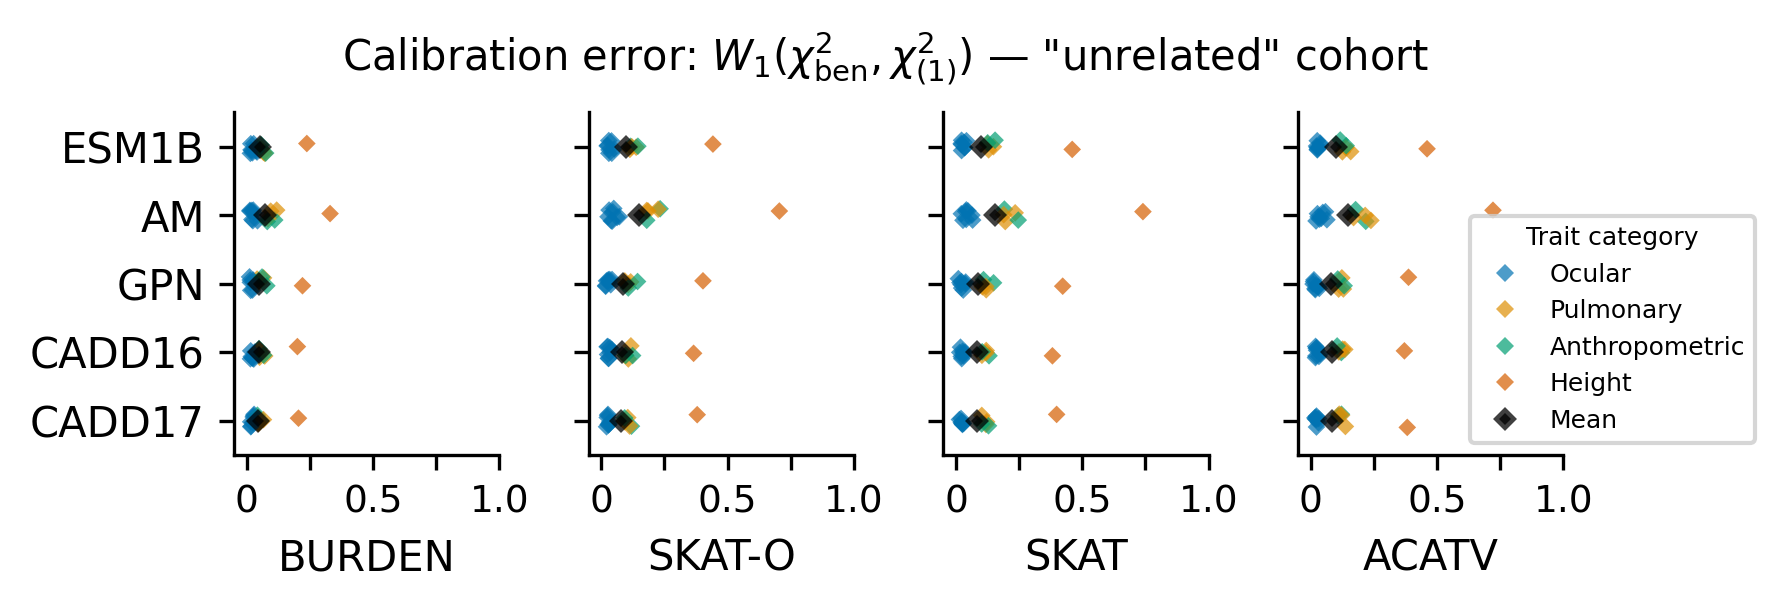

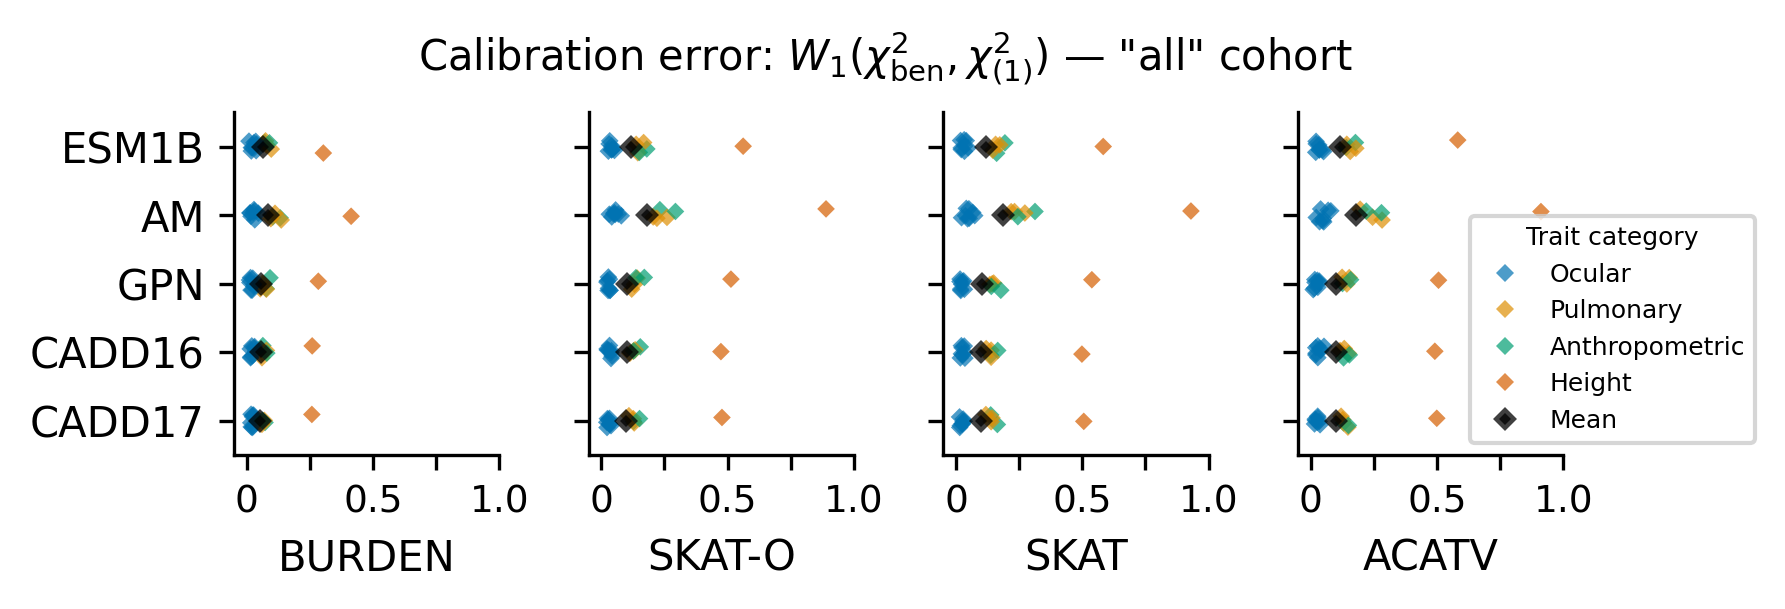

In [49]:
for q,name in {'unrelated':'unrelated', 'related':'all'}.items():

    fig, axs = plt.subplots(1, 4, figsize=(6, 2.2))

    for i, ((test, data), ax) in enumerate(zip(w1.groupby('test_keys', sort=False), axs.flat)):
        # points
        sns.stripplot(
            data = data.query('pop_sample == @q'),
            ax = ax,
            hue = 'pheno_group',
            hue_order = GROUP_ORDER,
            palette = 'colorblind',
            x = 'Calibration error',
            y = 'anno',
            order = ANNO_ORDER,
            s = 3,
            alpha = 0.7,
            marker = 'D',
            legend = (i == 3)
        );

        # means
        sns.pointplot(
            data = data.query('pop_sample == @q'),
            ax = ax,
            x = 'Calibration error',
            order = ANNO_ORDER,
            y = 'anno',
            linestyles = '',
            errorbar = None,
            marker = 'D',
            color = 'k',
            ms = 2,
            alpha = 0.75,
            legend = None,
            label = 'Mean',
            zorder = 6,
        );
    
        ax.set_xlabel(test);
        if i != 0:
            ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
        if i == 3:
            ax.legend(title='Trait category', title_fontsize=6, frameon=1, fontsize=6, bbox_to_anchor=(0.6, 0.0), loc='lower left');
        ax.set_ylabel(None);
        ax.set_xlim(-0.05, 1.0);
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], labels=['0','','0.5','','1.0'], fontsize=9);
    
    fig.suptitle('Calibration error: ' + r'$W_1(\chi^2_\text{ben}, \chi^2_{(1)})$' + ' — "{}" cohort'.format(name), fontsize=10, y=0.9);
    fig.tight_layout();
    sns.despine();
    
    fig.savefig('png/supplement/w1_ben_' + name + '.png', bbox_inches='tight');

### Signal separation pointplots

/tmp/slurmjob.58107830/ipykernel_1775164/3041976718.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/3041976718.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/3041976718.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/3041976718.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.581078

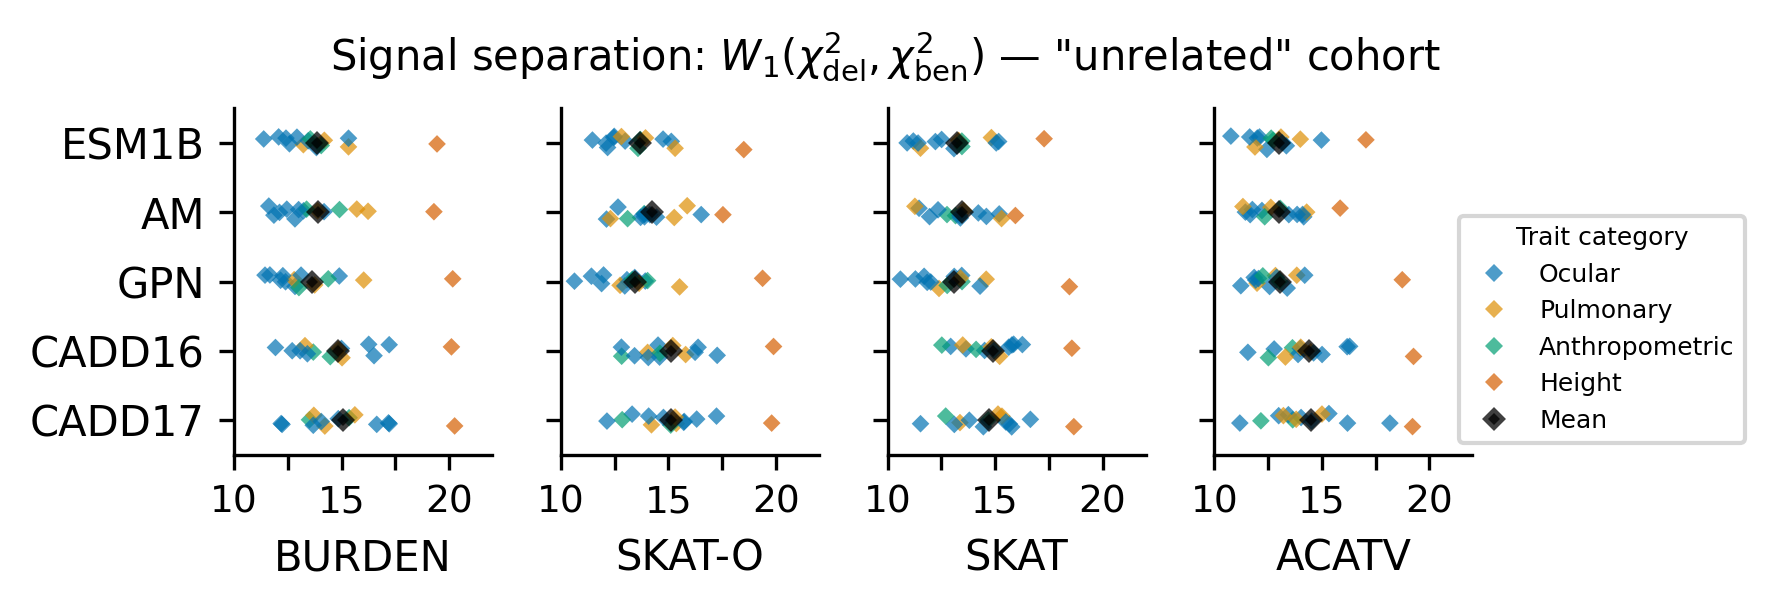

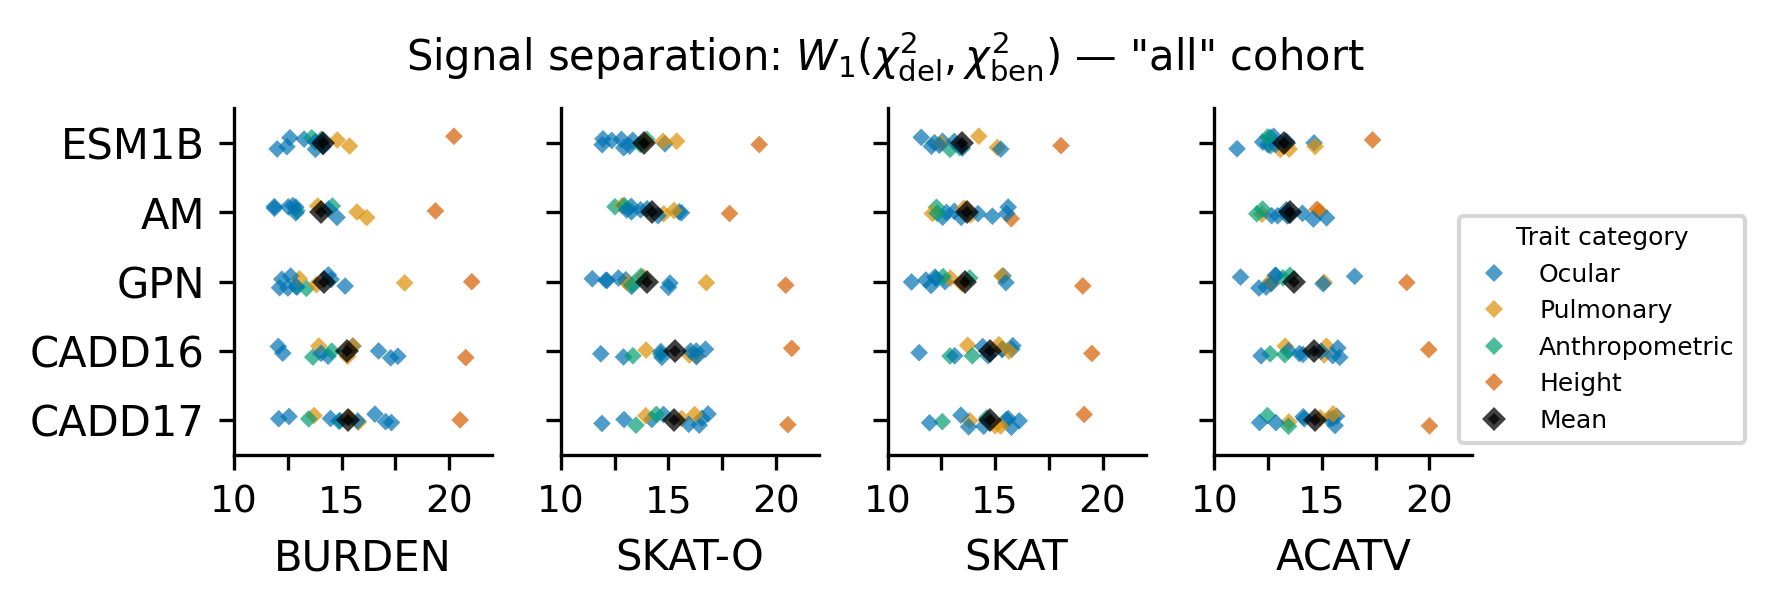

In [50]:
for q,name in {'unrelated':'unrelated', 'related':'all'}.items():

    fig, axs = plt.subplots(1, 4, figsize=(6, 2.2))

    for i, ((test, data), ax) in enumerate(zip(w1.groupby('test_keys', sort=False), axs.flat)):
        # points
        sns.stripplot(
            data = data.query('pop_sample == @q'),
            ax = ax,
            hue = 'pheno_group',
            hue_order = GROUP_ORDER,
            palette = 'colorblind',
            x = 'Signal separation',
            y = 'anno',
            order = ANNO_ORDER,
            s = 3,
            alpha = 0.7,
            marker = 'D',
            legend = (i == 3)
        );

        # means
        sns.pointplot(
            data = data.query('pop_sample == @q'),
            ax = ax,
            x = 'Signal separation',
            order = ANNO_ORDER,
            y = 'anno',
            linestyles = '',
            errorbar = None,
            marker = 'D',
            color = 'k',
            ms = 2,
            alpha = 0.75,
            legend = None,
            label = 'Mean',
            zorder = 6,
        );
        
        ax.set_xlabel(test);
        if i != 0:
            ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
        if i == 3:
            ax.legend(title='Trait category', title_fontsize=6, frameon=1, fontsize=6, bbox_to_anchor=(0.9, 0.0), loc='lower left');
        ax.set_ylabel(None);
        ax.set_xlim(10, 22);
        ax.set_xticks([10, 12.5, 15, 17.5, 20], labels=['10','','15','','20'], fontsize=9);
    
    fig.suptitle('Signal separation: ' + r'$W_1(\chi^2_\text{del}, \chi^2_\text{ben})$' + ' — "{}" cohort'.format(name), fontsize=10, y=0.9);
    fig.tight_layout();
    sns.despine()
    
    fig.savefig('png/supplement/w1_del_' + name + '.png', bbox_inches='tight');

### Combined pointplot

/tmp/slurmjob.58107830/ipykernel_1775164/2159958323.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/2159958323.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/2159958323.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.58107830/ipykernel_1775164/2159958323.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
/tmp/slurmjob.581078

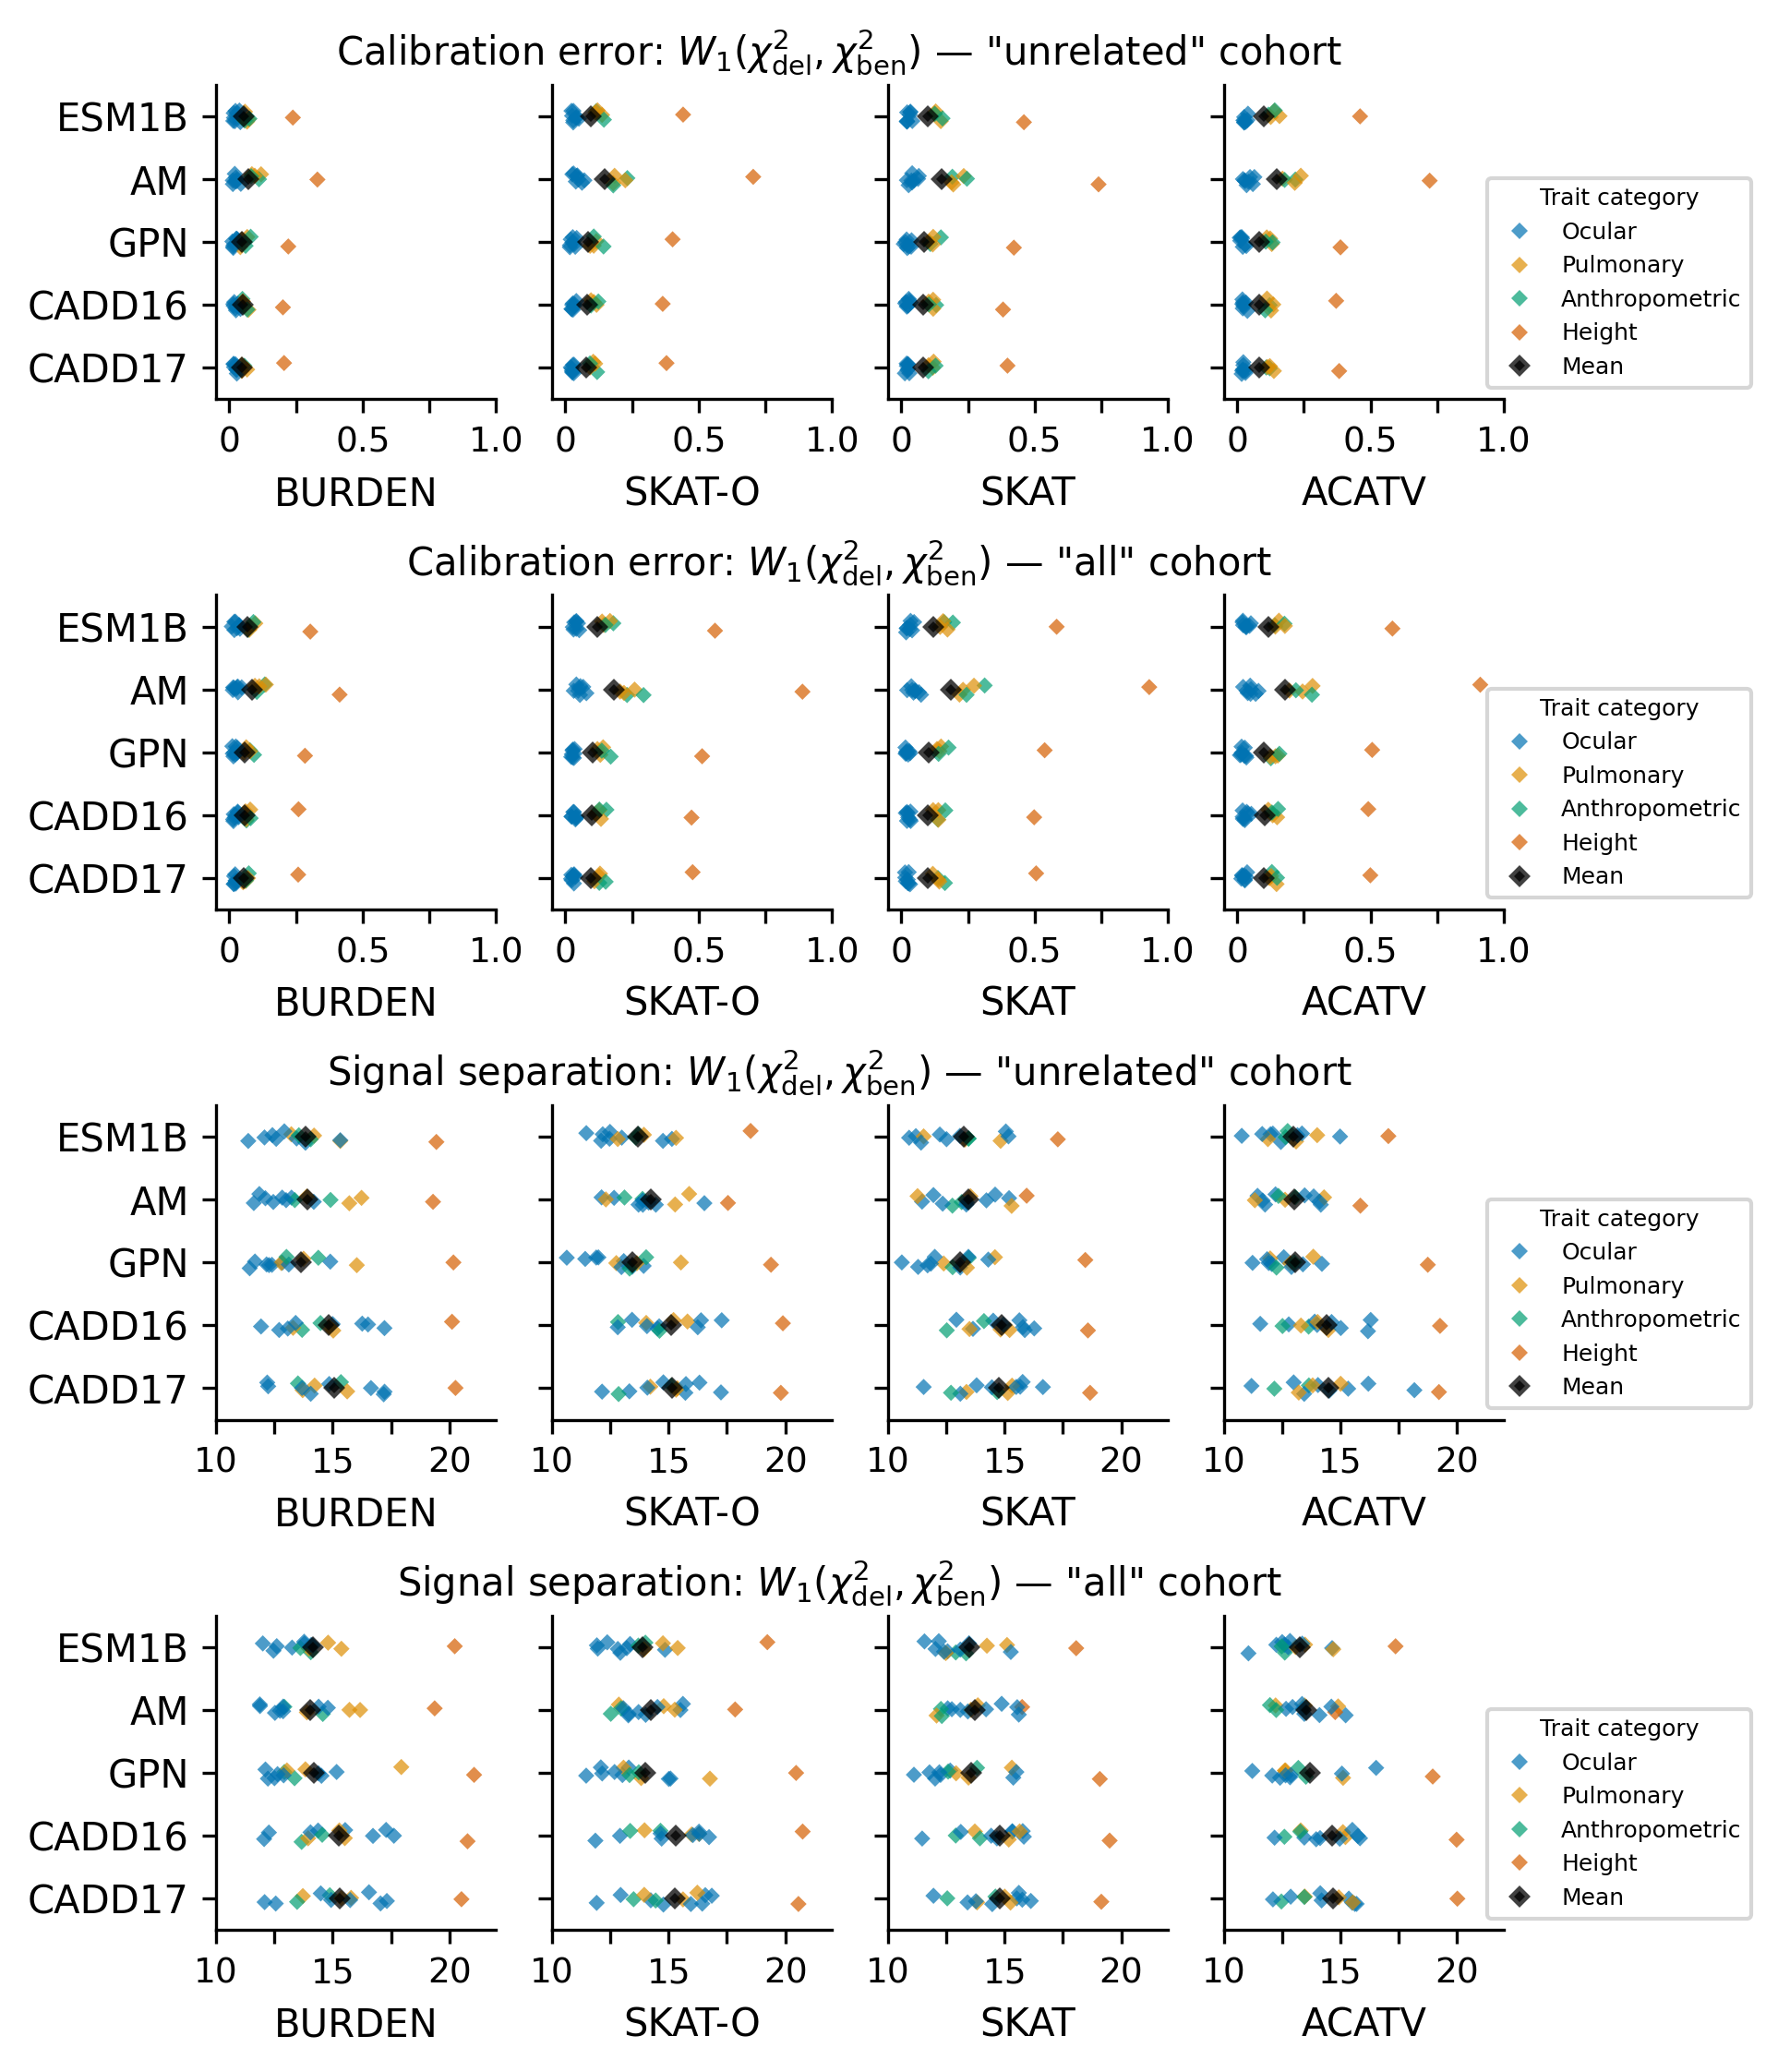

In [51]:
big_fig = plt.figure(figsize=(6, 7));
figs = big_fig.subfigures(4, 1, hspace = 0.25);

for (x,math,q,name),fig in zip(
    [
        stat + cohort 
        for stat in [
            ['Calibration error',r'$W_1(\chi^2_\text{del}, \chi^2_\text{ben})$'], 
            ['Signal separation',r'$W_1(\chi^2_\text{del}, \chi^2_\text{ben})$']
        ] for cohort in [
            ['unrelated','unrelated'], 
            ['related','all']
        ]
    ], 
    figs.flat
):

    axs = fig.subplots(1, 4);
    
    for i, ((test, data), ax) in enumerate(zip(w1.groupby('test_keys', sort=False), axs.flat)):
        # points
        sns.stripplot(
            data = data.query('pop_sample == @q'),
            ax = ax,
            hue = 'pheno_group',
            hue_order = GROUP_ORDER,
            palette = 'colorblind',
            x = x,
            y = 'anno',
            order = ANNO_ORDER,
            s = 3,
            alpha = 0.7,
            marker = 'D',
            legend = (i == 3)
        );

        # means
        sns.pointplot(
            data = data.query('pop_sample == @q'),
            ax = ax,
            x = x,
            order = ANNO_ORDER,
            y = 'anno',
            linestyles = '',
            errorbar = None,
            marker = 'D',
            color = 'k',
            ms = 2,
            alpha = 0.75,
            legend = None,
            label = 'Mean',
            zorder = 6,
        );
        
        ax.set_xlabel(test);
        if i != 0:
            ax.set_yticklabels(['' for _ in ax.get_yticklabels()]);
        if i == 3:
            ax.legend(title='Trait category', title_fontsize=6, frameon=1, fontsize=6, bbox_to_anchor=(0.9, 0.0), loc='lower left');
        ax.set_ylabel(None);
        if x == 'Signal separation':
            ax.set_xlim(10, 22);  
            ax.set_xticks([10, 12.5, 15, 17.5, 20], labels=['10','','15','','20'], fontsize=9);
        elif x == 'Calibration error':
            ax.set_xlim(-0.05, 1.0);
            ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], labels=['0','','0.5','','1.0'], fontsize=9);           
    
    fig.suptitle('{0}: {1} — "{2}" cohort'.format(x, math, name), fontsize=10, y=1.02);
    sns.despine();
    
big_fig.savefig('png/supplement/w1_supp.png', bbox_inches='tight');

## Validation

### Constraint enrichment

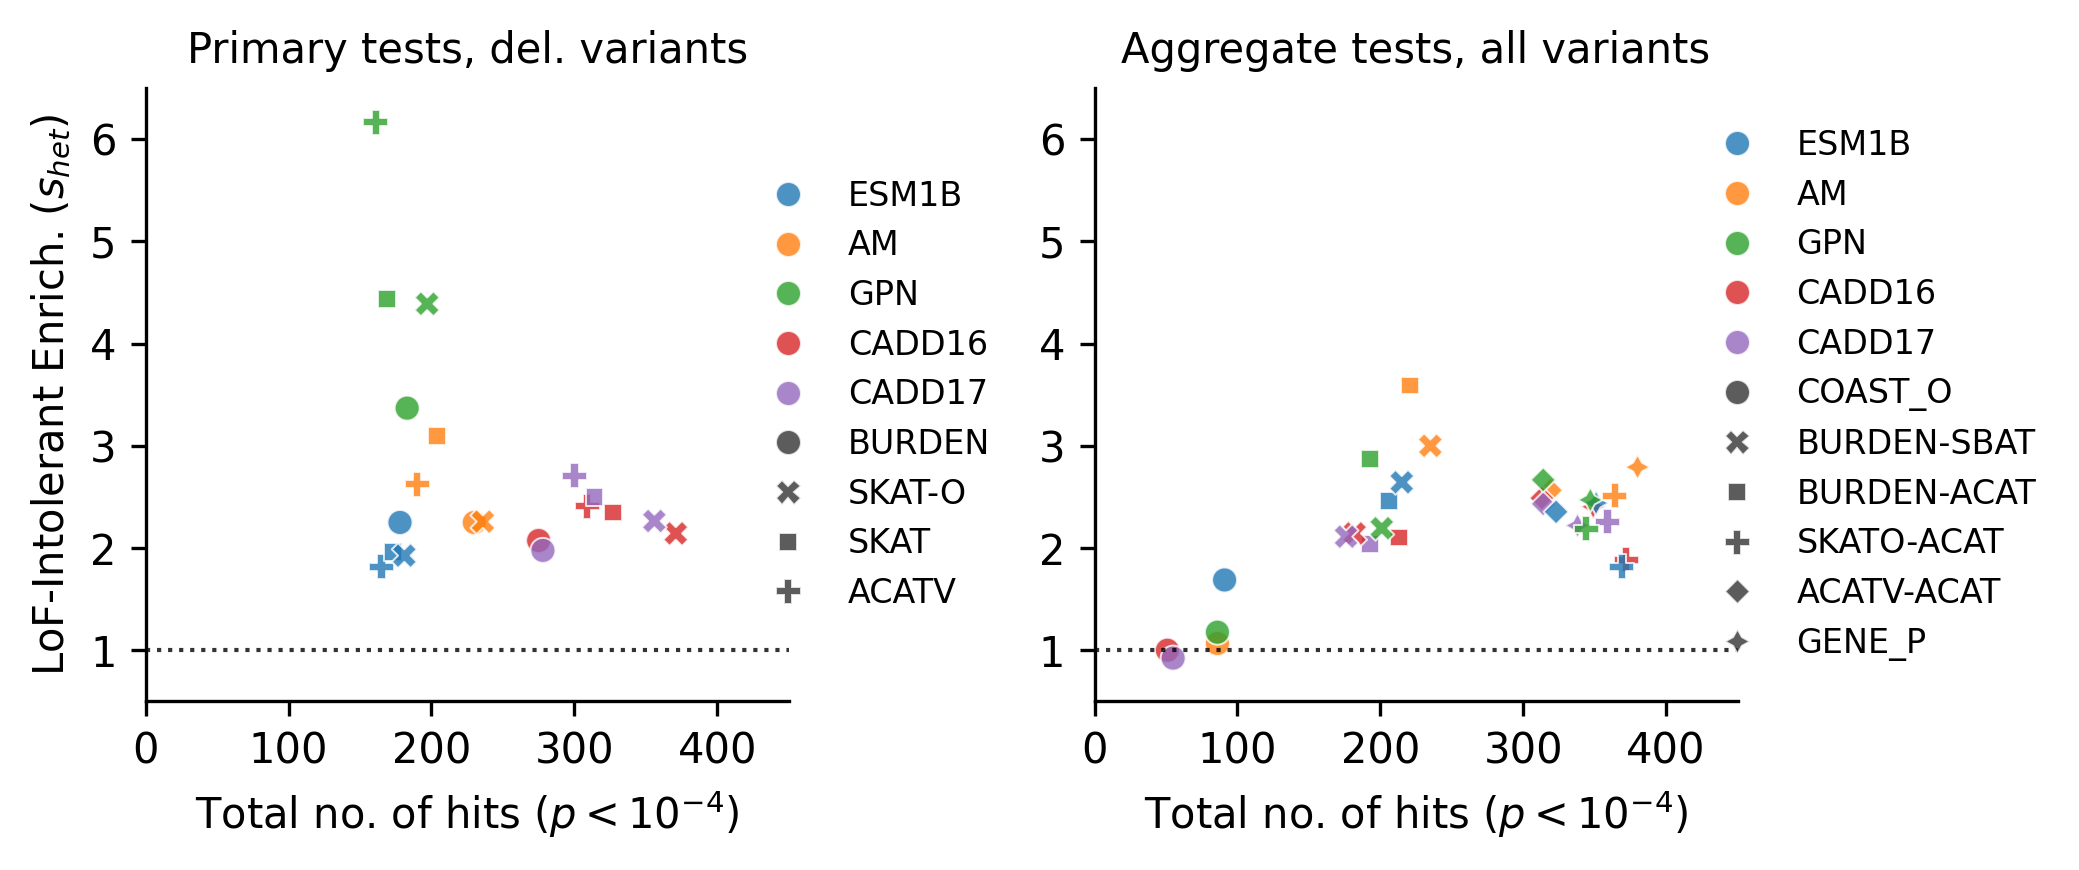

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(7,3))

for i,(mask,title) in enumerate(zip(['del','bdm'], ['Primary tests, del. variants', 'Aggregate tests, all variants'])):
    sns.scatterplot(
        ax = ax[i],
        data = enrich.query('(pop_sample == "unrelated") & mask == @mask'),
        x = 'No. of gene-trait pairs (p < 0.0001)',
        y = 'LoF-Intolerant Enrichment ({})'.format(r'$s_{het}$'),
        hue = 'anno',
        hue_order = ANNO_ORDER,
        style = 'test_keys',
        style_order = TEST_ORDER1 if mask == 'del' else TEST_ORDER2,
        alpha = 0.8,
        legend = True,
    )
    ax[i].set_xlabel('Total no. of hits ({})'.format(r'$p < 10^{-4}$'));
    ax[i].set_ylabel(ax[i].get_ylabel().replace('Enrichment', 'Enrich.'));
    # ax[i].set_xlabel('{0}\n({1})'.format(ax[i].get_xlabel(), pop));
    ax[i].set_ylim(0.5, 6.5);
    ax[i].set_xlim(0, 450); ax[i].set_xticks([0, 100, 200, 300, 400]);
    ax[i].axhline(1, linestyle='dotted', color='k', linewidth=1, alpha=0.8);
    ax[i].set_title(title, fontsize=10);
    
    handles, labels = ax[i].get_legend_handles_labels()
    ax[i].legend(handles=handles[1:6] + handles[7:], labels=labels[1:6] + labels[7:])
    sns.move_legend(ax[i], loc = 'center left', bbox_to_anchor = (0.9, 0.5), fontsize = 8, frameon=0);

ax[1].set_ylabel(None);
fig.tight_layout();
sns.despine();

#### LOEUF

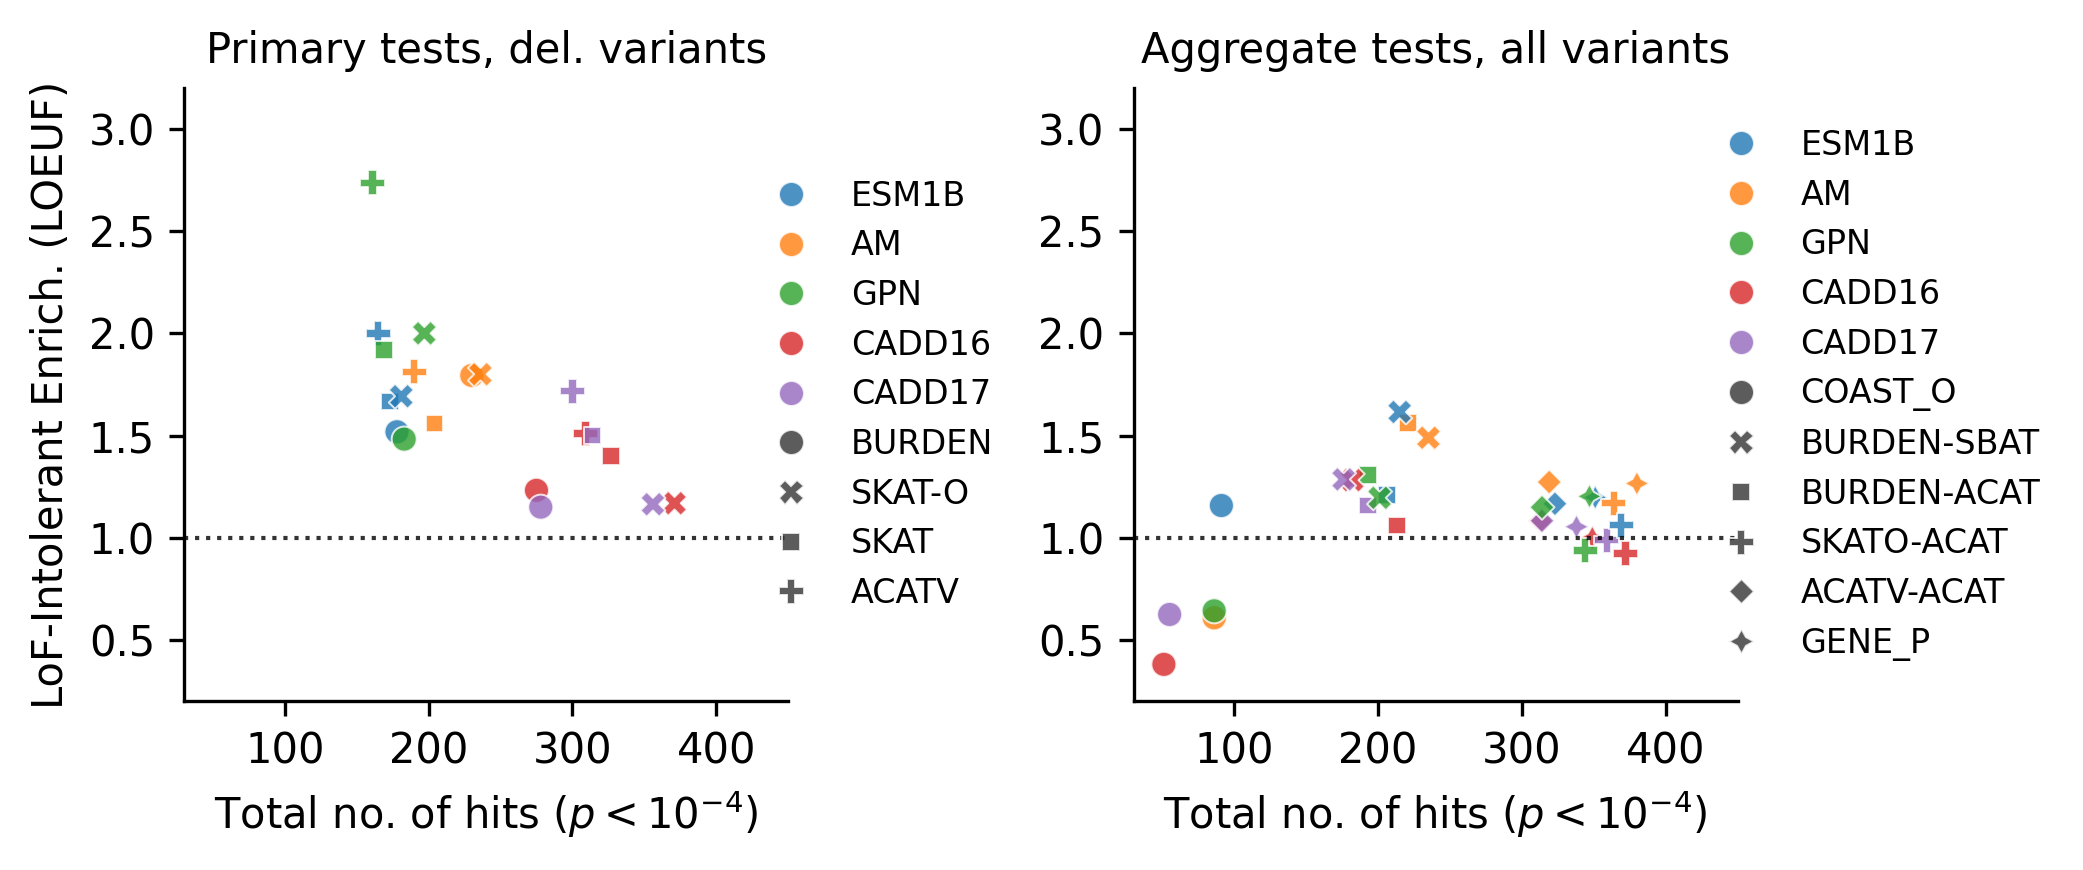

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(7,3))

for i,(mask,title) in enumerate(zip(['del','bdm'], ['Primary tests, del. variants', 'Aggregate tests, all variants'])):
    sns.scatterplot(
        ax = ax[i],
        data = enrich.query('(pop_sample == "unrelated") & mask == @mask'),
        x = 'No. of gene-trait pairs (p < 0.0001)',
        y = 'LoF-Intolerant Enrichment (LOEUF)',
        hue = 'anno',
        hue_order = ANNO_ORDER,
        style = 'test_keys',
        style_order = TEST_ORDER1 if mask == 'del' else TEST_ORDER2,
        alpha = 0.8,
        legend = True,
    )
    ax[i].set_xlabel('Total no. of hits ({})'.format(r'$p < 10^{-4}$'));
    ax[i].set_ylabel(ax[i].get_ylabel().replace('Enrichment', 'Enrich.'));

    ax[i].set_ylim(0.2, 3.2);
    ax[i].set_xlim(30, 450); ax[i].set_xticks([100, 200, 300, 400]);
    ax[i].axhline(1, linestyle='dotted', color='k', linewidth=1, alpha=0.8);
    ax[i].set_title(title, fontsize=10);
    
    handles, labels = ax[i].get_legend_handles_labels()
    ax[i].legend(handles=handles[1:6] + handles[7:], labels=labels[1:6] + labels[7:])
    sns.move_legend(ax[i], loc = 'center left', bbox_to_anchor = (0.9, 0.5), fontsize = 8, frameon=0);

ax[1].set_ylabel(None);
fig.tight_layout();
sns.despine();

plt.savefig('png/supplement/loeuf_enrichment.png');

del count    20.000000
mean      2.748084
std       1.091767
min       1.814815
25%       2.125436
50%       2.305989
75%       2.804297
max       6.166667
Name: LoF-Intolerant Enrichment ($s_{het}$), dtype: float64
mod count    20.000000
mean      2.000734
std       0.715249
min       1.071429
25%       1.413534
50%       1.835017
75%       2.428167
max       3.375000
Name: LoF-Intolerant Enrichment ($s_{het}$), dtype: float64
ben count    20.000000
mean      1.274255
std       0.451347
min       0.611111
25%       0.921154
50%       1.135236
75%       1.560852
max       2.333333
Name: LoF-Intolerant Enrichment ($s_{het}$), dtype: float64


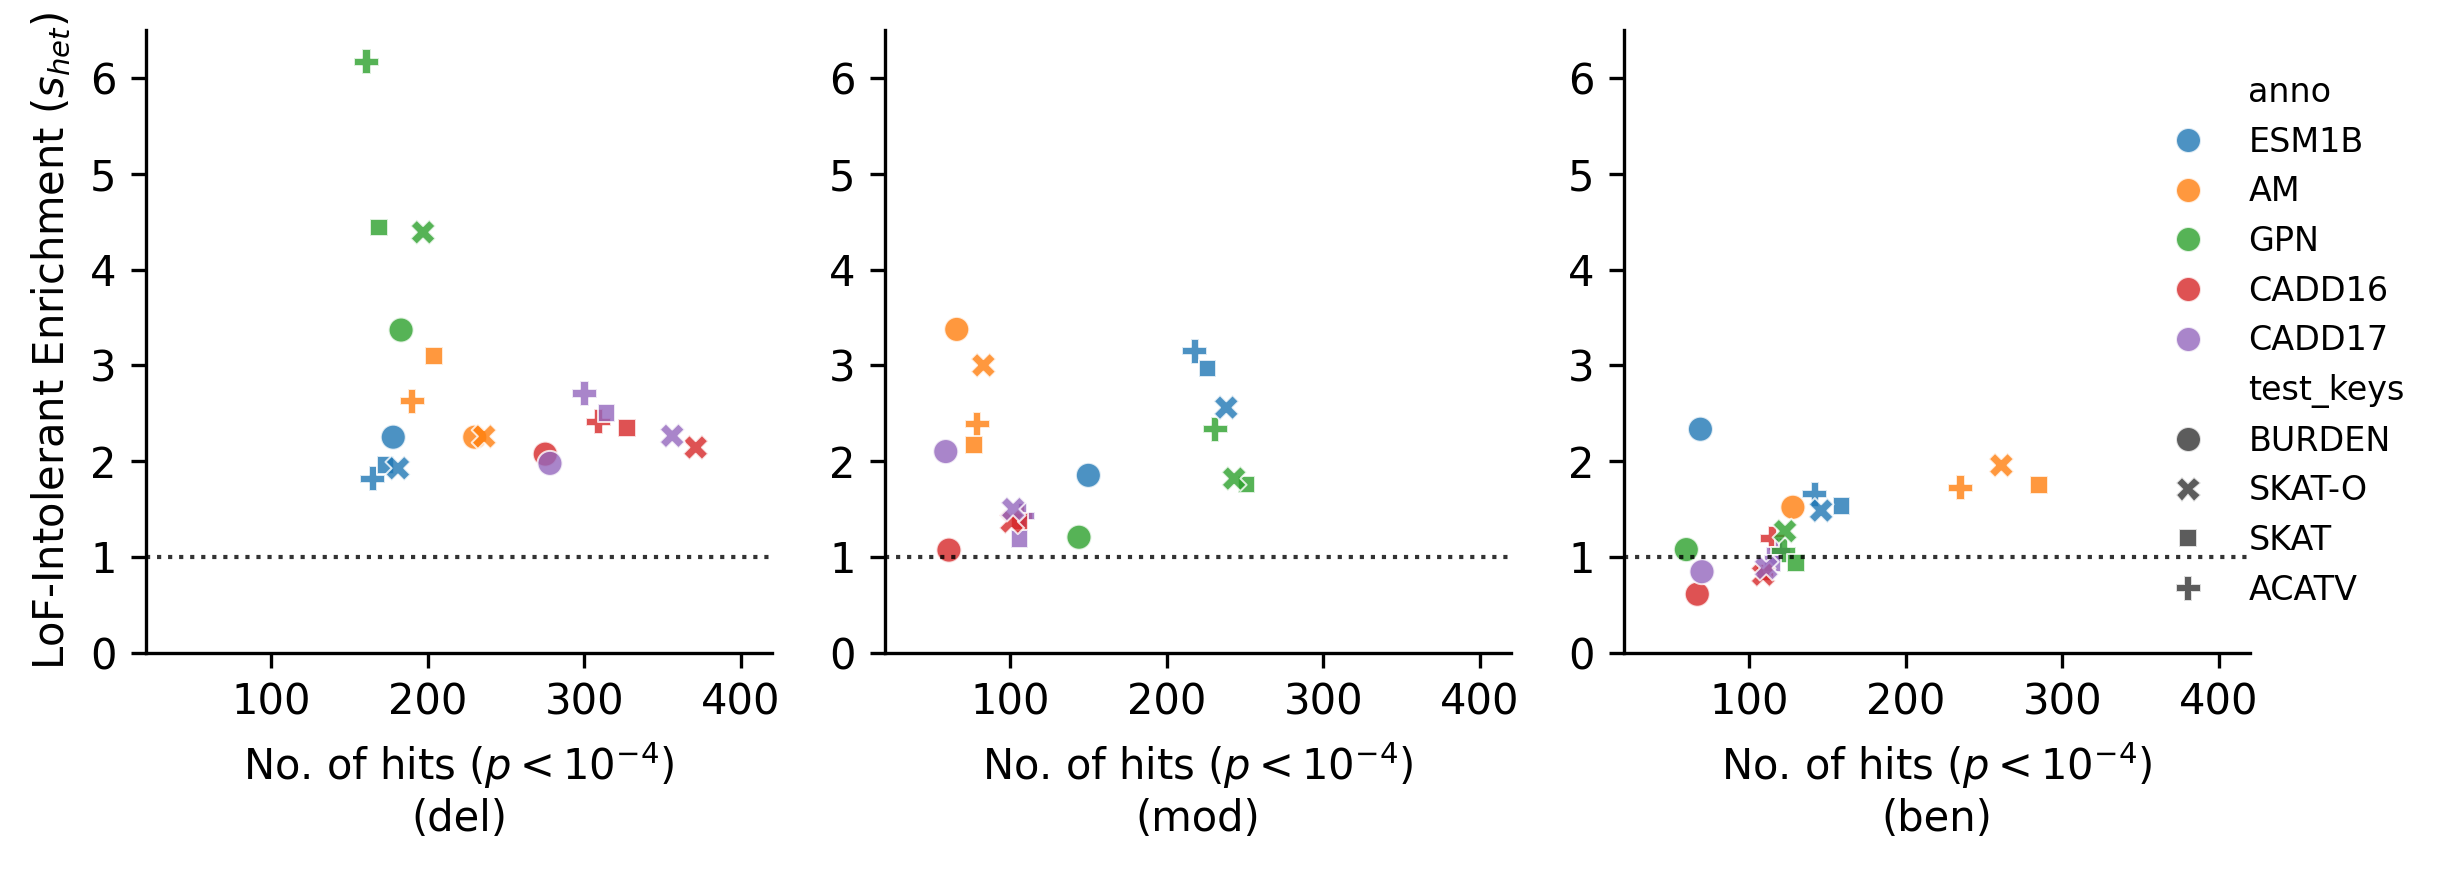

In [54]:
fig, ax = plt.subplots(1, 3, figsize=(8.3, 3))

for i,mask in enumerate(['del','mod','ben']):
    print(
        mask,
        enrich.query(
            '(pop_sample == "unrelated") & mask == @mask'
        )['LoF-Intolerant Enrichment ({})'.format(r'$s_{het}$')].describe()
    )
    sns.scatterplot(
        ax = ax[i],
        data = enrich.query('(pop_sample == "unrelated") & mask == @mask'),
        x = 'No. of gene-trait pairs (p < 0.0001)',
        y = 'LoF-Intolerant Enrichment ({})'.format(r'$s_{het}$'),
        hue = 'anno',
        hue_order = ANNO_ORDER,
        style = 'test_keys',
        style_order = TEST_ORDER1,
        alpha = 0.8,
        legend = (i > 1),
    ),
    ax[i].set_xlabel('No. of hits ({0})\n({1})'.format(r'$p<10^{-4}$', mask));
    ax[i].set_ylim(0, 6.5);
    ax[i].set_xlim(20, 420);
    ax[i].axhline(1, linestyle='dotted', color='k', linewidth=1, alpha=0.8);
    if i > 0:
        ax[i].set_ylabel(None);

sns.move_legend(ax[2], loc = 'center left', bbox_to_anchor = (0.8, 0.5), fontsize = 8, frameon=False);
fig.tight_layout();
sns.despine();

fig.savefig('png/supplement/primary_lof_enrichment_by_mask.png', bbox_inches='tight');

#### Running average

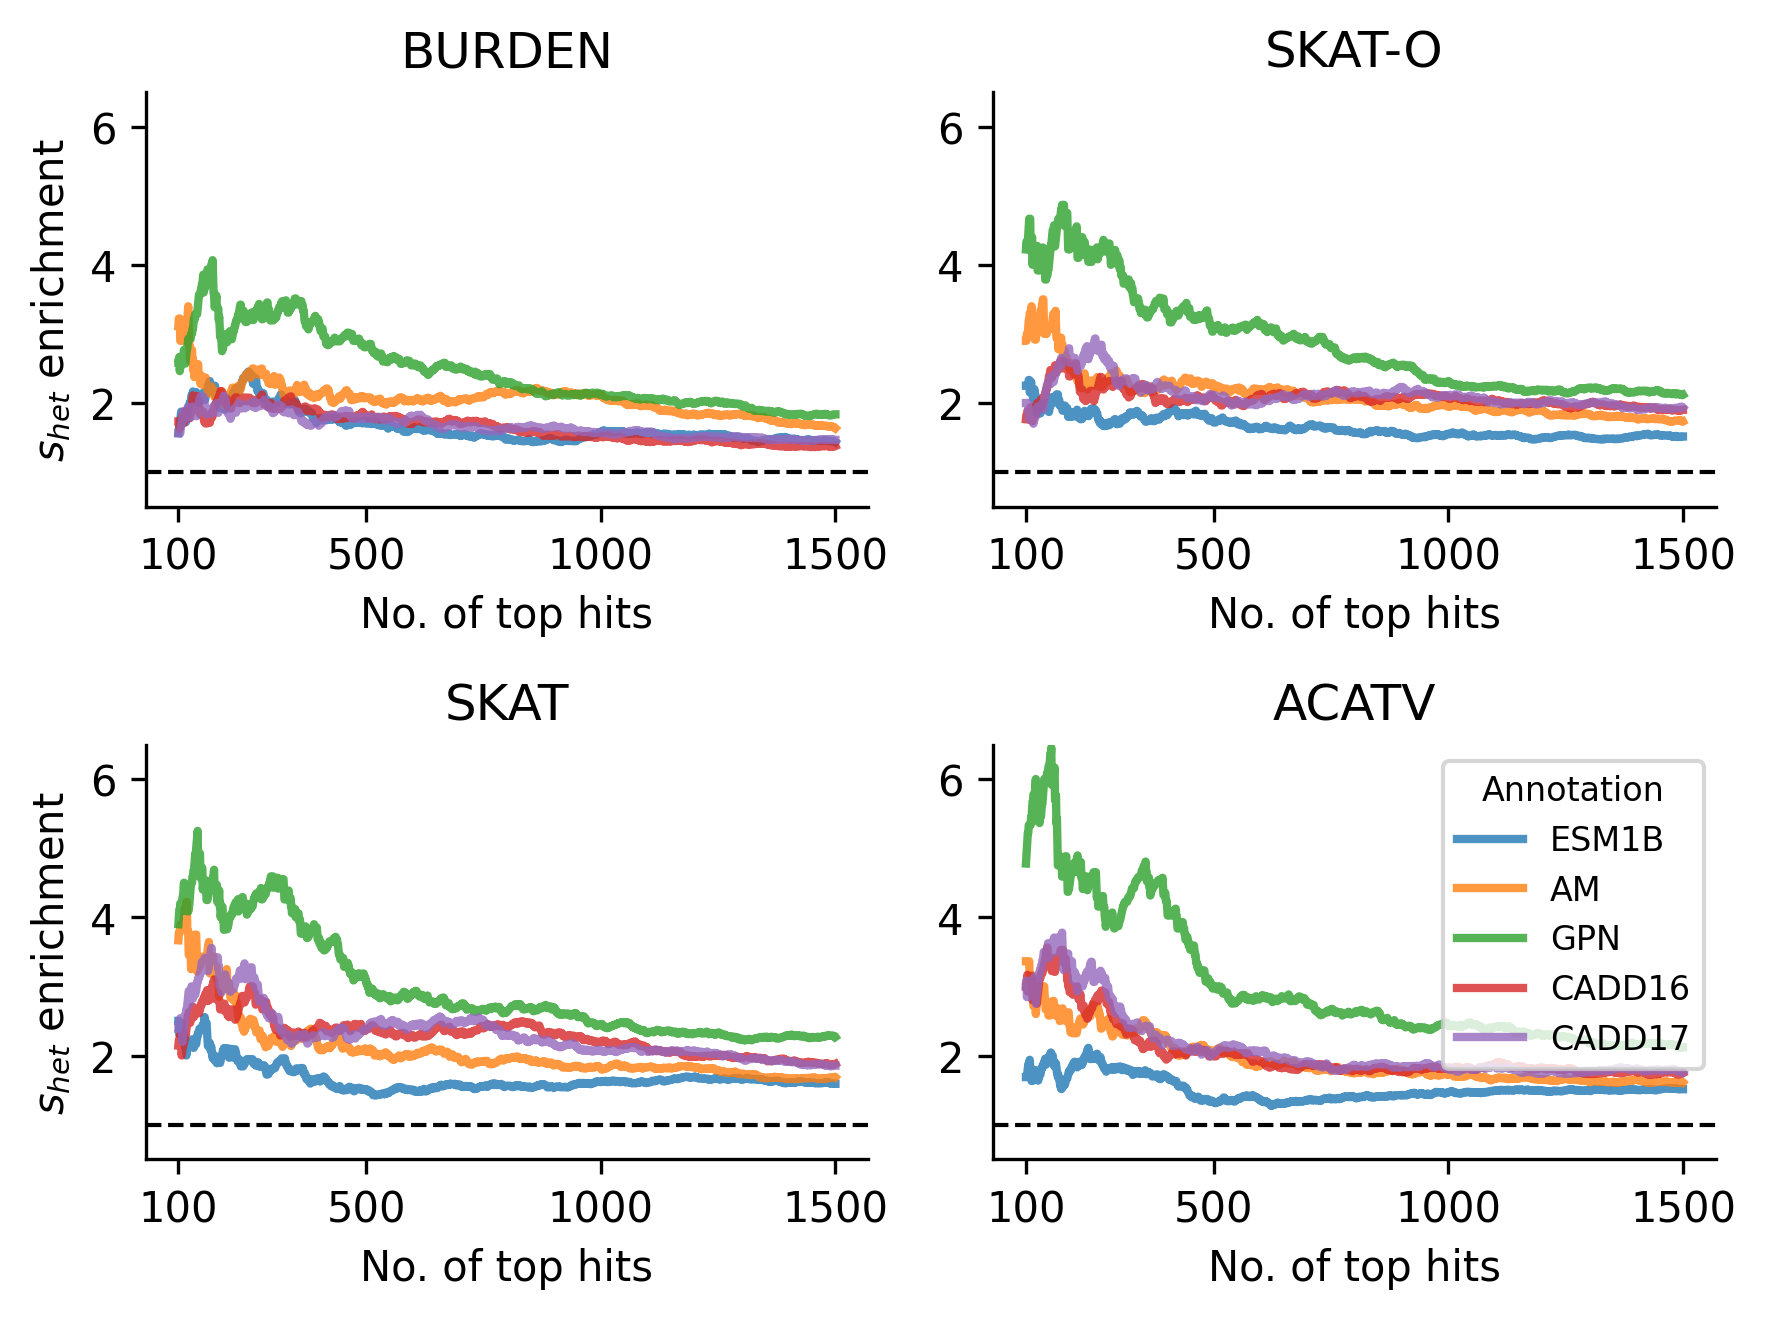

In [55]:
fig, axs = plt.subplots(2, 2, figsize=(6, 4.5))

for i,(test, ax) in enumerate(zip(TEST_ORDER1, axs.flat)):
        sns.lineplot(
            ax = ax,
            data = cumul_enrich.query(
                '(pop_sample == "unrelated") & (test_keys == @test) & (100 <= top_k) & (top_k <= 1500)'
            ).reset_index(),
            x = 'top_k',
            y = 's_het_enrich',
            hue = 'anno',
            hue_order = ANNO_ORDER,
            linewidth = 2,
            alpha = 0.8,
            legend = i == 3,
        )
        ax.set_title(test);
        ax.set_xlabel('{0}'.format('No. of top hits'));
        ax.set_xticks([100, 500, 1000, 1500]);
        ax.set_ylabel(r'$s_{het}$' + ' enrichment');
        ax.set_ylim(0.5, 6.5);
        ax.axhline(1, linewidth=1, linestyle='dashed', color='k');
        if i % axs.shape[0] != 0:
            ax.set_ylabel(None);
        if i == 3:
            sns.move_legend(ax, loc = 'upper left', bbox_to_anchor = (0.6, 1.0), fontsize = 8, title='Annotation', title_fontsize = 8);

fig.tight_layout()
sns.despine();

fig.savefig('png/supplement/running_lof_enrichment.png', bbox_inches='tight');

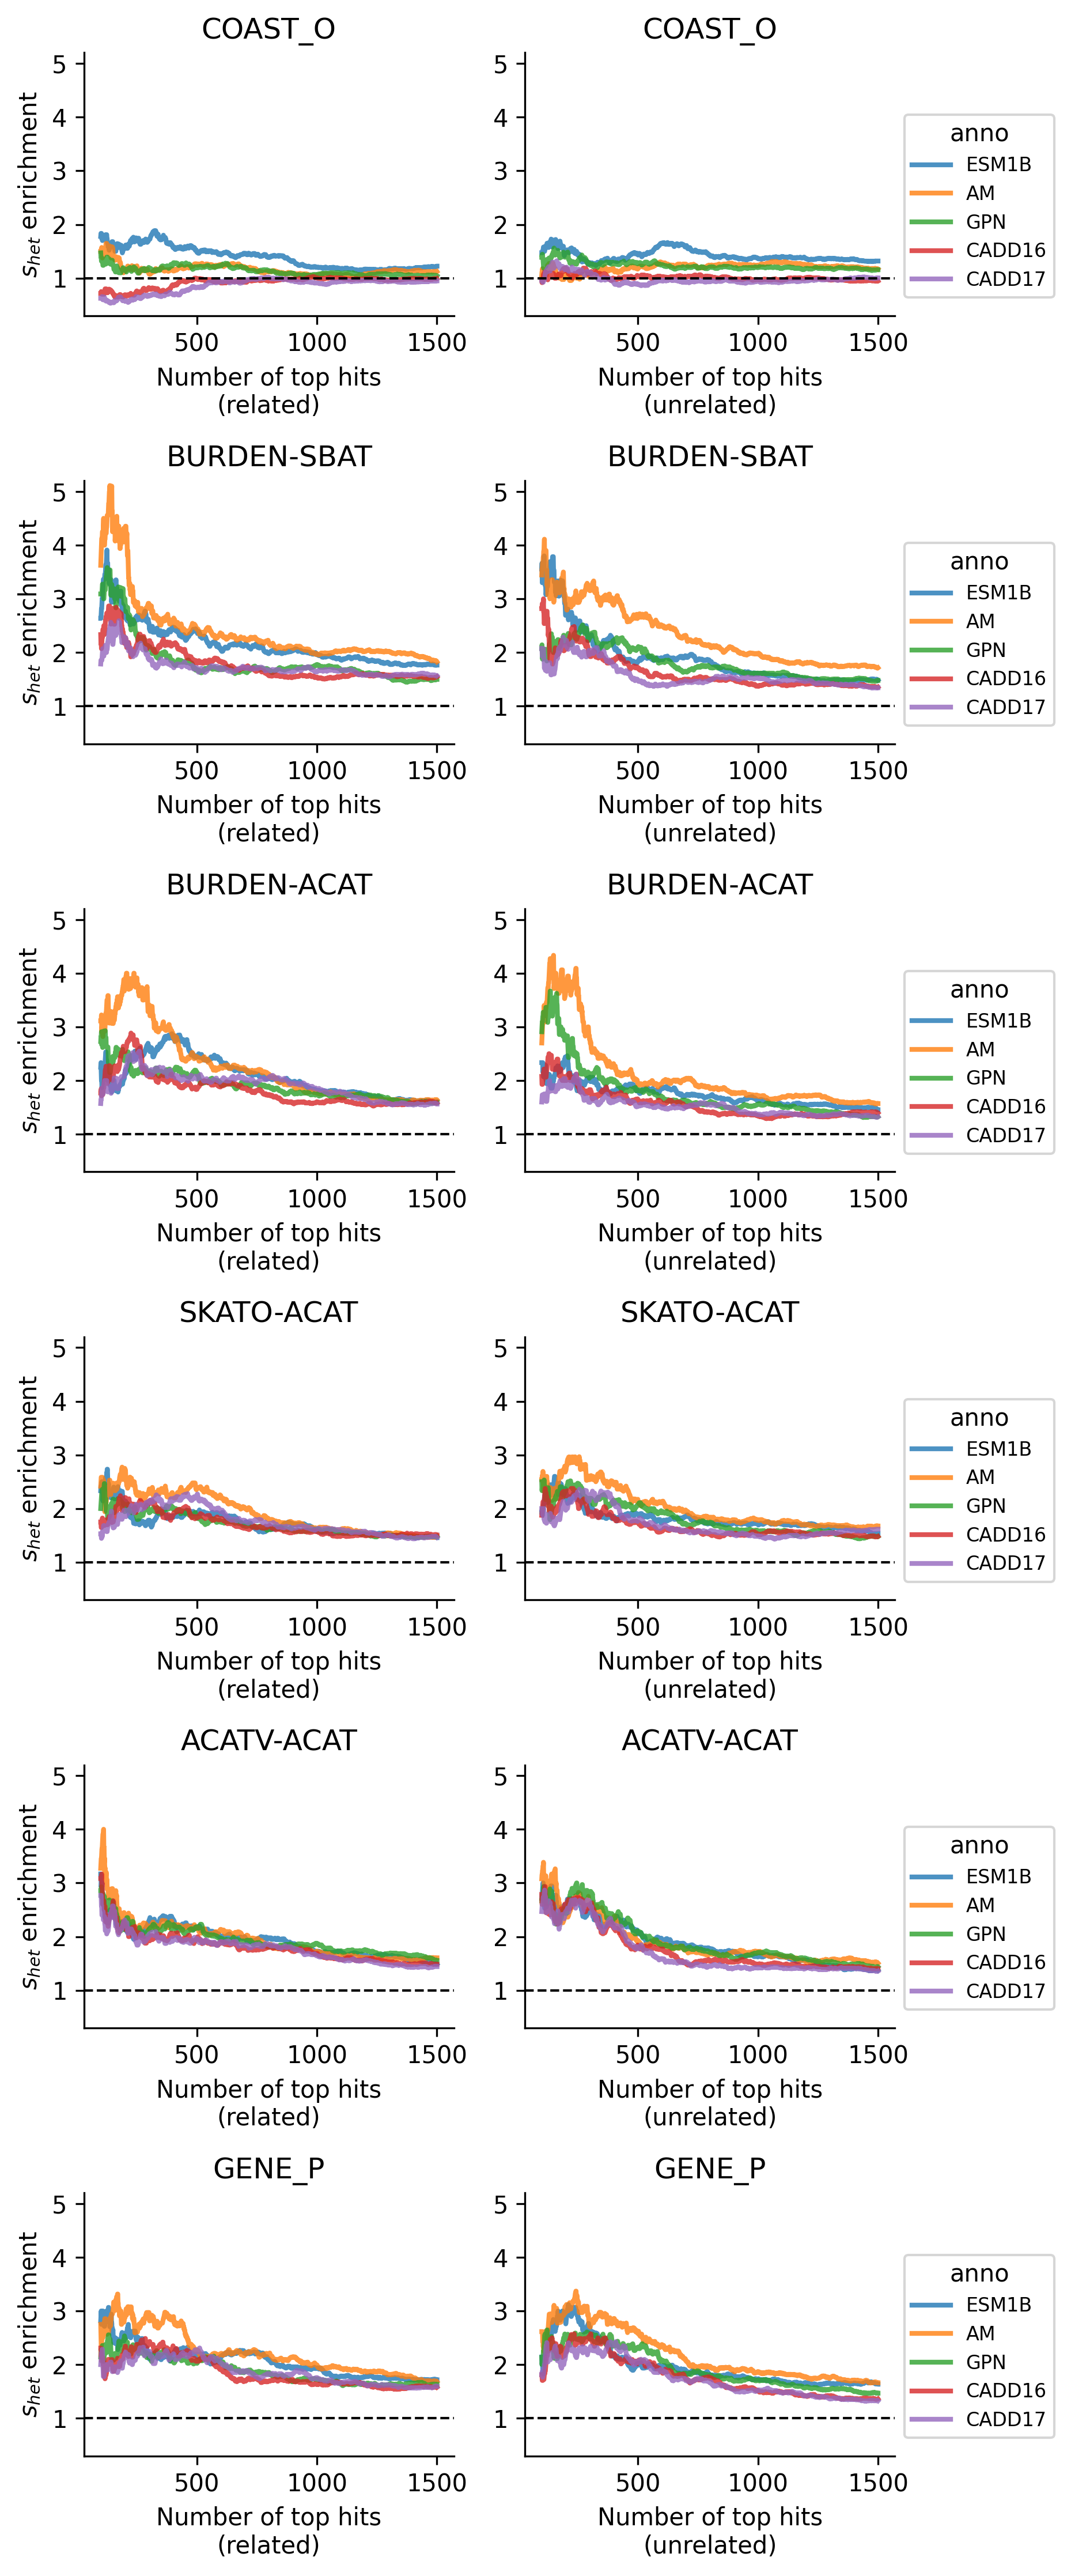

In [56]:
fig, axs = plt.subplots(6, 2, figsize=(6.3, 15))

for i,pop in enumerate(cumul_enrich2.index.get_level_values('pop_sample').unique()):
    for j,test in enumerate(TEST_ORDER2):
        ax = axs[j,i]
        sns.lineplot(
            ax = ax,
            data = cumul_enrich2.query(
                '(pop_sample == @pop) & (test_keys == @test) & (100 <= top_k) & (top_k <= 1500)'
            ).reset_index(),
            x = 'top_k',
            y = 's_het_enrich',
            hue = 'anno',
            hue_order = ANNO_ORDER,
            linewidth = 2,
            alpha = 0.8,
            legend = (i > 0),
        )
        ax.set_title(test);
        ax.set_xlabel('{0}\n({1})'.format('Number of top hits', pop));
        ax.set_ylabel(r'$s_{het}$' + ' enrichment');
        ax.set_ylim(0.3, 5.2);
        ax.axhline(1, linewidth=1, linestyle='dashed', color='k');
        if i == 1:
            ax.set_ylabel(None)
            sns.move_legend(ax, loc = 'upper left', bbox_to_anchor = (1.0, 0.8), fontsize = 8);

fig.tight_layout()
sns.despine();

#### ANOVA

In [57]:
enrich['num_hits'] = enrich['No. of gene-trait pairs (p < 0.0001)']
enrich['enrich'] = enrich['LoF-Intolerant Enrichment ({})'.format(r'$s_{het}$')]
enrich['Annotation'] = enrich['anno']
enrich['Test'] = enrich['test_keys']

d1 = enrich.query('mask == "del" & pop_sample == "unrelated"')
d2 = enrich.query('mask == "bdm" & pop_sample == "unrelated"')

for name,d in zip(['primary','secondary'], [d1,d2]):
    for y in ['enrich','num_hits']:
        print(name, y)
        aa = sm.stats.anova_lm(smf.ols(y + ' ~ Annotation + Test', data = d).fit(), typ=2)
        display(aa)
        
        print(aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True))
        
        for x in ['anno','test_keys']:
            tk = sm.stats.multicomp.pairwise_tukeyhsd(d[y], d[x], alpha = 0.05).summary()
            display(tk)
            print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

primary enrich


,sum_sq,df,F,PR(>F)
Annotation,17.650385,4.0,15.763863,0.000101
Test,1.637752,3.0,1.950272,0.175410
Residual,3.359022,12.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 17.650 & 4 & 15.764 & 1.0e-04 \\
Test & 1.638 & 3 & 1.950 & 1.8e-01 \\
Residual & 3.359 & 12 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-0.3138,0.9357,-1.5741,0.9464,False
AM,CADD17,-0.195,0.9883,-1.4553,1.0652,False
AM,ESM1B,-0.5694,0.6397,-1.8296,0.6908,False
AM,GPN,2.0333,0.0013,0.7731,3.2935,True
CADD16,CADD17,0.1188,0.9982,-1.1414,1.379,False
CADD16,ESM1B,-0.2556,0.9685,-1.5158,1.0047,False
CADD16,GPN,2.3471,0.0003,1.0869,3.6074,True
CADD17,ESM1B,-0.3744,0.8858,-1.6346,0.8859,False
CADD17,GPN,2.2283,0.0005,0.9681,3.4885,True
ESM1B,GPN,2.6027,0.0001,1.3425,3.8629,True


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &      -0.3138      &     0.9357     &    -1.5741     &     0.9464     &      False       \\
       AM       &      CADD17     &       -0.195      &     0.9883     &    -1.4553     &     1.0652     &      False       \\
       AM       &      ESM1B      &      -0.5694      &     0.6397     &    -1.8296     &     0.6908     &      False       \\
       AM       &       GPN       &       2.0333      &     0.0013     &     0.7731     &     3.2935     &       True       \\
     CADD16     &      CADD17     &       0.1188      &     0.9982     &    -1.1414     &     1.379      &      False       \\
     CADD16     &      ESM1B      &      -0.2556      &     0.9685     &    -1.5158     &     1.0047     &      False       \\
     CADD16     &       GPN       &       2.3471     

...

\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 3030.000 & 4 & 5.138 & 5.2e-03 \\
Test & 314259.200 & 5 & 426.288 & 1.3e-19 \\
Residual & 2948.800 & 20 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-20.8333,0.9976,-211.8303,170.1636,False
AM,CADD17,-28.3333,0.992,-219.3303,162.6636,False
AM,ESM1B,-8.3333,0.9999,-199.3303,182.6636,False
AM,GPN,-20.0,0.9979,-210.9969,170.9969,False
CADD16,CADD17,-7.5,1.0,-198.4969,183.4969,False
CADD16,ESM1B,12.5,0.9997,-178.4969,203.4969,False
CADD16,GPN,0.8333,1.0,-190.1636,191.8303,False
CADD17,ESM1B,20.0,0.9979,-170.9969,210.9969,False
CADD17,GPN,8.3333,0.9999,-182.6636,199.3303,False
ESM1B,GPN,-11.6667,0.9998,-202.6636,179.3303,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &      -20.8333     &     0.9976     &   -211.8303    &    170.1636    &      False       \\
       AM       &      CADD17     &      -28.3333     &     0.992      &   -219.3303    &    162.6636    &      False       \\
       AM       &      ESM1B      &      -8.3333      &     0.9999     &   -199.3303    &    182.6636    &      False       \\
       AM       &       GPN       &       -20.0       &     0.9979     &   -210.9969    &    170.9969    &      False       \\
     CADD16     &      CADD17     &        -7.5       &      1.0       &   -198.4969    &    183.4969    &      False       \\
     CADD16     &      ESM1B      &        12.5       &     0.9997     &   -178.4969    &    203.4969    &      False       \\
     CADD16     &       GPN       &       0.8333     

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV-ACAT,BURDEN-ACAT,-111.4,0.0,-142.2646,-80.5354,True
ACATV-ACAT,BURDEN-SBAT,-114.8,0.0,-145.6646,-83.9354,True
ACATV-ACAT,COAST_O,-242.8,0.0,-273.6646,-211.9354,True
ACATV-ACAT,GENE_P,36.4,0.0143,5.5354,67.2646,True
ACATV-ACAT,SKATO-ACAT,45.0,0.0018,14.1354,75.8646,True
BURDEN-ACAT,BURDEN-SBAT,-3.4,0.9993,-34.2646,27.4646,False
BURDEN-ACAT,COAST_O,-131.4,0.0,-162.2646,-100.5354,True
BURDEN-ACAT,GENE_P,147.8,0.0,116.9354,178.6646,True
BURDEN-ACAT,SKATO-ACAT,156.4,0.0,125.5354,187.2646,True
BURDEN-SBAT,COAST_O,-128.0,0.0,-158.8646,-97.1354,True


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
   ACATV-ACAT   &   BURDEN-ACAT   &       -111.4      &      0.0       &   -142.2646    &    -80.5354    &       True       \\
   ACATV-ACAT   &   BURDEN-SBAT   &       -114.8      &      0.0       &   -145.6646    &    -83.9354    &       True       \\
   ACATV-ACAT   &     COAST\_O    &       -242.8      &      0.0       &   -273.6646    &   -211.9354    &       True       \\
   ACATV-ACAT   &     GENE\_P     &        36.4       &     0.0143     &     5.5354     &    67.2646     &       True       \\
   ACATV-ACAT   &    SKATO-ACAT   &        45.0       &     0.0018     &    14.1354     &    75.8646     &       True       \\
  BURDEN-ACAT   &   BURDEN-SBAT   &        -3.4       &     0.9993     &    -34.2646    &    27.4646     &      False       \\
  BURDEN-ACAT   &     COAST\_O    &       -131.4     

#### ANOVA + Robust

In [58]:
enrich['num_hits'] = enrich['No. of gene-trait pairs (p < 0.0001)']
enrich['enrich'] = enrich['LoF-Intolerant Enrichment ({})'.format(r'$s_{het}$')]
enrich['Annotation'] = enrich['anno']
enrich['Test'] = enrich['test_keys']

d1 = enrich.query('mask == "del" & pop_sample == "unrelated"')
d2 = enrich.query('mask == "bdm" & pop_sample == "unrelated"')

for name,d in zip(['primary','secondary'], [d1,d2]):
    for y in ['enrich','num_hits']:
        print(name, y)
        aa = sm.stats.anova_lm(smf.ols(y + ' ~ Annotation + Test', data = d).fit(), typ=2, robust = 'hc3')
        display(aa)
        
        print(aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True))
        
        for x in ['anno','test_keys']:
            tk = sm.stats.multicomp.pairwise_tukeyhsd(d[y], d[x], alpha = 0.05).summary()
            display(tk)
            print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

primary enrich


,sum_sq,df,F,PR(>F)
Annotation,4.376238,4.0,3.908494,0.029467
Test,1.088316,3.0,1.295992,0.320729
Residual,3.359022,12.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 4.376 & 4 & 3.908 & 2.9e-02 \\
Test & 1.088 & 3 & 1.296 & 3.2e-01 \\
Residual & 3.359 & 12 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-0.3138,0.9357,-1.5741,0.9464,False
AM,CADD17,-0.195,0.9883,-1.4553,1.0652,False
AM,ESM1B,-0.5694,0.6397,-1.8296,0.6908,False
AM,GPN,2.0333,0.0013,0.7731,3.2935,True
CADD16,CADD17,0.1188,0.9982,-1.1414,1.379,False
CADD16,ESM1B,-0.2556,0.9685,-1.5158,1.0047,False
CADD16,GPN,2.3471,0.0003,1.0869,3.6074,True
CADD17,ESM1B,-0.3744,0.8858,-1.6346,0.8859,False
CADD17,GPN,2.2283,0.0005,0.9681,3.4885,True
ESM1B,GPN,2.6027,0.0001,1.3425,3.8629,True


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &      -0.3138      &     0.9357     &    -1.5741     &     0.9464     &      False       \\
       AM       &      CADD17     &       -0.195      &     0.9883     &    -1.4553     &     1.0652     &      False       \\
       AM       &      ESM1B      &      -0.5694      &     0.6397     &    -1.8296     &     0.6908     &      False       \\
       AM       &       GPN       &       2.0333      &     0.0013     &     0.7731     &     3.2935     &       True       \\
     CADD16     &      CADD17     &       0.1188      &     0.9982     &    -1.1414     &     1.379      &      False       \\
     CADD16     &      ESM1B      &      -0.2556      &     0.9685     &    -1.5158     &     1.0047     &      False       \\
     CADD16     &       GPN       &       2.3471     

...

\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
Annotation & 2260.441 & 4 & 3.833 & 1.8e-02 \\
Test & 203757.875 & 5 & 276.394 & 9.7e-18 \\
Residual & 2948.800 & 20 & nan & nan \\
\bottomrule
\end{tabular}



group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-20.8333,0.9976,-211.8303,170.1636,False
AM,CADD17,-28.3333,0.992,-219.3303,162.6636,False
AM,ESM1B,-8.3333,0.9999,-199.3303,182.6636,False
AM,GPN,-20.0,0.9979,-210.9969,170.9969,False
CADD16,CADD17,-7.5,1.0,-198.4969,183.4969,False
CADD16,ESM1B,12.5,0.9997,-178.4969,203.4969,False
CADD16,GPN,0.8333,1.0,-190.1636,191.8303,False
CADD17,ESM1B,20.0,0.9979,-170.9969,210.9969,False
CADD17,GPN,8.3333,0.9999,-182.6636,199.3303,False
ESM1B,GPN,-11.6667,0.9998,-202.6636,179.3303,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &      -20.8333     &     0.9976     &   -211.8303    &    170.1636    &      False       \\
       AM       &      CADD17     &      -28.3333     &     0.992      &   -219.3303    &    162.6636    &      False       \\
       AM       &      ESM1B      &      -8.3333      &     0.9999     &   -199.3303    &    182.6636    &      False       \\
       AM       &       GPN       &       -20.0       &     0.9979     &   -210.9969    &    170.9969    &      False       \\
     CADD16     &      CADD17     &        -7.5       &      1.0       &   -198.4969    &    183.4969    &      False       \\
     CADD16     &      ESM1B      &        12.5       &     0.9997     &   -178.4969    &    203.4969    &      False       \\
     CADD16     &       GPN       &       0.8333     

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV-ACAT,BURDEN-ACAT,-111.4,0.0,-142.2646,-80.5354,True
ACATV-ACAT,BURDEN-SBAT,-114.8,0.0,-145.6646,-83.9354,True
ACATV-ACAT,COAST_O,-242.8,0.0,-273.6646,-211.9354,True
ACATV-ACAT,GENE_P,36.4,0.0143,5.5354,67.2646,True
ACATV-ACAT,SKATO-ACAT,45.0,0.0018,14.1354,75.8646,True
BURDEN-ACAT,BURDEN-SBAT,-3.4,0.9993,-34.2646,27.4646,False
BURDEN-ACAT,COAST_O,-131.4,0.0,-162.2646,-100.5354,True
BURDEN-ACAT,GENE_P,147.8,0.0,116.9354,178.6646,True
BURDEN-ACAT,SKATO-ACAT,156.4,0.0,125.5354,187.2646,True
BURDEN-SBAT,COAST_O,-128.0,0.0,-158.8646,-97.1354,True


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
   ACATV-ACAT   &   BURDEN-ACAT   &       -111.4      &      0.0       &   -142.2646    &    -80.5354    &       True       \\
   ACATV-ACAT   &   BURDEN-SBAT   &       -114.8      &      0.0       &   -145.6646    &    -83.9354    &       True       \\
   ACATV-ACAT   &     COAST\_O    &       -242.8      &      0.0       &   -273.6646    &   -211.9354    &       True       \\
   ACATV-ACAT   &     GENE\_P     &        36.4       &     0.0143     &     5.5354     &    67.2646     &       True       \\
   ACATV-ACAT   &    SKATO-ACAT   &        45.0       &     0.0018     &    14.1354     &    75.8646     &       True       \\
  BURDEN-ACAT   &   BURDEN-SBAT   &        -3.4       &     0.9993     &    -34.2646    &    27.4646     &      False       \\
  BURDEN-ACAT   &     COAST\_O    &       -131.4     

### Paired trait replication

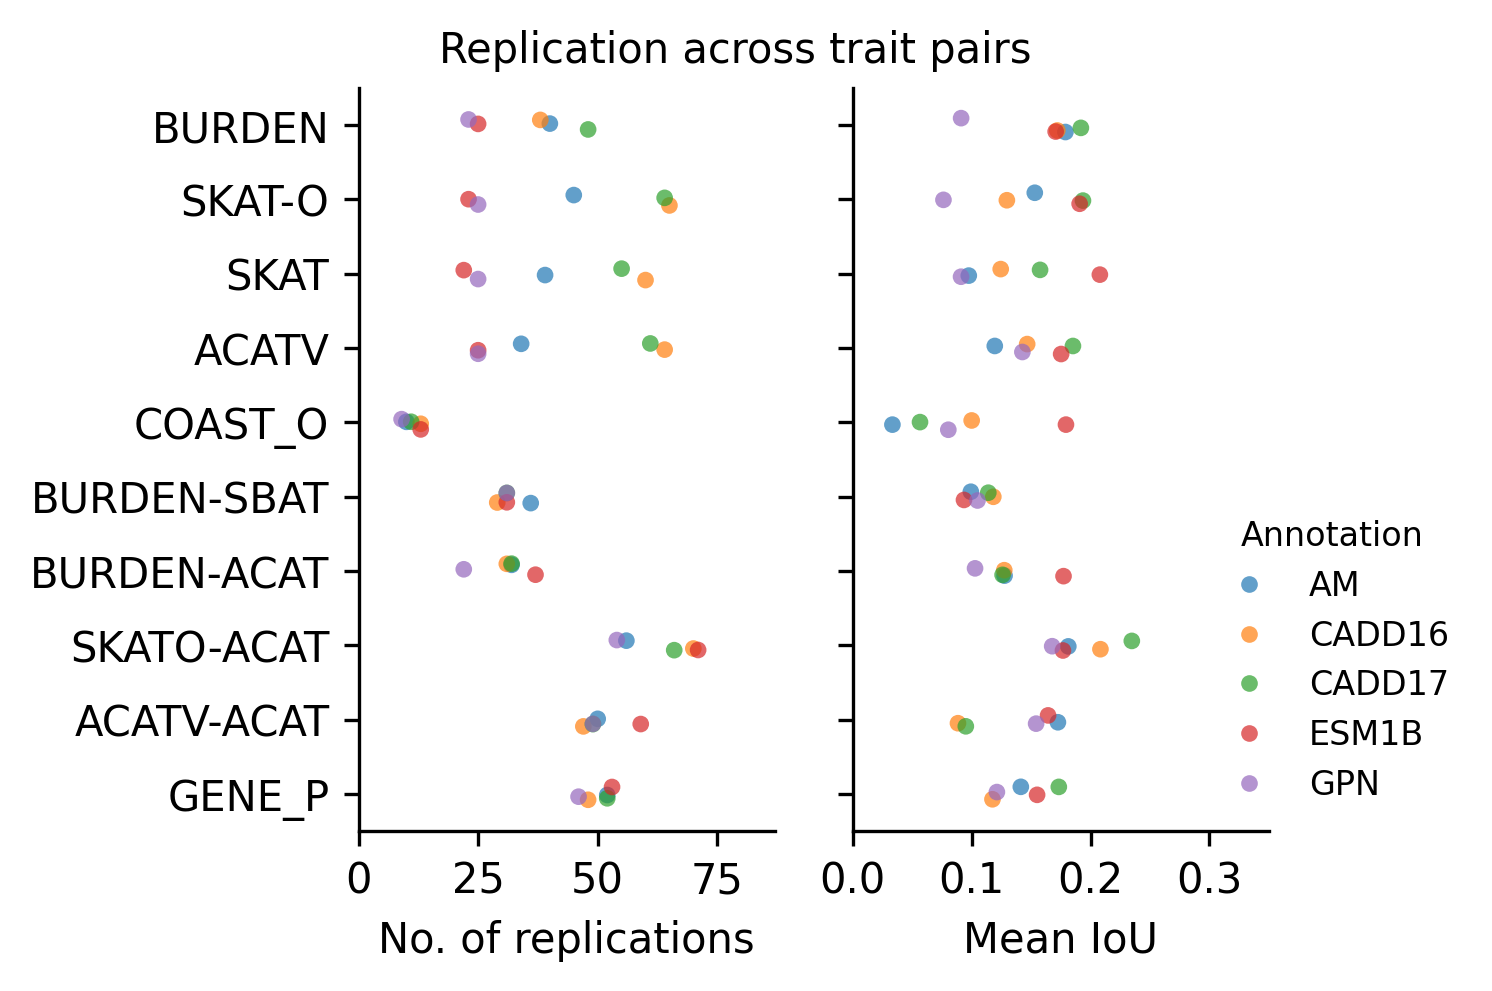

In [59]:
fig, axs = plt.subplots(1, 2, figsize=(5, 3.5))

ax = axs[0]
sns.stripplot(
    data = traits,
    ax = ax,
    x = 'total',
    y = 'test_keys',
    hue = 'anno',
    order = TEST_ORDER,
    s = 4,
    alpha = 0.7,
    legend = None,
);
ax.set_xlabel('No. of replications');
ax.set_ylabel(None);
ax.set_xlim(0, 87);
ax.set_xticks([0, 25,50,75]);


ax = axs[1]
sns.stripplot(
    data = traits,
    ax = ax,
    x = 'iou',
    y = 'test_keys',
    hue = 'anno',
    order = TEST_ORDER,
    s = 4,
    alpha = 0.7,
);
ax.set_xlabel('Mean IoU');
ax.set_ylabel(None);
ax.set_xlim(0, 0.35);
ax.set_xticks([0, 0.1, 0.2, 0.3]);
ax.set_yticks(ax.get_yticks(), labels=['' for _ in ax.get_yticks()]);
ax.legend(frameon=0, title='Annotation', fontsize=8, title_fontsize=8, bbox_to_anchor=(0.8, 0.0), loc='lower left');

fig.suptitle('Replication across trait pairs', fontsize=10, y=0.93);
fig.tight_layout();
sns.despine();

fig.savefig('png/supplement/trait_rep.png');

#### ANOVA

In [60]:
for stat in ['total', 'iou']:
    
    for name, query in {
        'all':'mask.notnull()', 
        'primary':'mask == "del"', 
        'secondary':'mask == "bdm"'
    }.items():

        aa = sm.stats.anova_lm(
            smf.ols(
                stat + ' ~ anno + test_keys', 
                data = traits.query(query)
            ).fit(), 
            typ=2
        )
        
        display(stat, name, aa)
        
        print(aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True))
        
        if name != 'all':
            for cat in ['anno','test_keys']:
                tk = sm.stats.multicomp.pairwise_tukeyhsd(
                    endog = traits.query(query)[stat], 
                    groups = traits.query(query)[cat],
                    alpha=0.05
                ).summary()
                
                display(cat, tk)
                
                print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

'total'

'all'

,sum_sq,df,F,PR(>F)
anno,1898.08,4.0,5.040459,2.490876e-03
test_keys,9012.48,9.0,10.636956,8.115143e-08
Residual,3389.12,36.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
anno & 1898.080 & 4 & 5.040 & 2.5e-03 \\
test_keys & 9012.480 & 9 & 10.637 & 8.1e-08 \\
Residual & 3389.120 & 36 & nan & nan \\
\bottomrule
\end{tabular}



'total'

...

group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,0.0007,1.0,-0.0783,0.0798,False
AM,CADD17,0.0074,0.9987,-0.0717,0.0864,False
AM,ESM1B,0.0318,0.7618,-0.0472,0.1108,False
AM,GPN,-0.004,0.9999,-0.0831,0.075,False
CADD16,CADD17,0.0066,0.9991,-0.0724,0.0856,False
CADD16,ESM1B,0.031,0.7767,-0.048,0.1101,False
CADD16,GPN,-0.0048,0.9998,-0.0838,0.0743,False
CADD17,ESM1B,0.0244,0.8912,-0.0546,0.1035,False
CADD17,GPN,-0.0114,0.9929,-0.0904,0.0676,False
ESM1B,GPN,-0.0358,0.675,-0.1149,0.0432,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &       0.0007      &      1.0       &    -0.0783     &     0.0798     &      False       \\
       AM       &      CADD17     &       0.0074      &     0.9987     &    -0.0717     &     0.0864     &      False       \\
       AM       &      ESM1B      &       0.0318      &     0.7618     &    -0.0472     &     0.1108     &      False       \\
       AM       &       GPN       &       -0.004      &     0.9999     &    -0.0831     &     0.075      &      False       \\
     CADD16     &      CADD17     &       0.0066      &     0.9991     &    -0.0724     &     0.0856     &      False       \\
     CADD16     &      ESM1B      &       0.031       &     0.7767     &     -0.048     &     0.1101     &      False       \\
     CADD16     &       GPN       &      -0.0048     

'test_keys'

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV-ACAT,BURDEN-ACAT,-0.0027,1.0,-0.0688,0.0635,False
ACATV-ACAT,BURDEN-SBAT,-0.0289,0.754,-0.0951,0.0372,False
ACATV-ACAT,COAST_O,-0.045,0.3189,-0.1112,0.0212,False
ACATV-ACAT,GENE_P,0.0068,0.9995,-0.0594,0.0729,False
ACATV-ACAT,SKATO-ACAT,0.0588,0.1015,-0.0073,0.125,False
BURDEN-ACAT,BURDEN-SBAT,-0.0263,0.8196,-0.0924,0.0399,False
BURDEN-ACAT,COAST_O,-0.0423,0.3828,-0.1085,0.0238,False
BURDEN-ACAT,GENE_P,0.0094,0.9976,-0.0567,0.0756,False
BURDEN-ACAT,SKATO-ACAT,0.0615,0.0789,-0.0046,0.1277,False
BURDEN-SBAT,COAST_O,-0.0161,0.973,-0.0822,0.0501,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
   ACATV-ACAT   &   BURDEN-ACAT   &      -0.0027      &      1.0       &    -0.0688     &     0.0635     &      False       \\
   ACATV-ACAT   &   BURDEN-SBAT   &      -0.0289      &     0.754      &    -0.0951     &     0.0372     &      False       \\
   ACATV-ACAT   &     COAST\_O    &       -0.045      &     0.3189     &    -0.1112     &     0.0212     &      False       \\
   ACATV-ACAT   &     GENE\_P     &       0.0068      &     0.9995     &    -0.0594     &     0.0729     &      False       \\
   ACATV-ACAT   &    SKATO-ACAT   &       0.0588      &     0.1015     &    -0.0073     &     0.125      &      False       \\
  BURDEN-ACAT   &   BURDEN-SBAT   &      -0.0263      &     0.8196     &    -0.0924     &     0.0399     &      False       \\
  BURDEN-ACAT   &     COAST\_O    &      -0.0423     

#### ANOVA + Robust

In [61]:
for stat in ['total', 'iou']:
    
    for name, query in {
        'all':'mask.notnull()', 
        'primary':'mask == "del"', 
        'secondary':'mask == "bdm"'
    }.items():

        aa = sm.stats.anova_lm(
            smf.ols(
                stat + ' ~ anno + test_keys', 
                data = traits.query(query)
            ).fit(), 
            typ=2,
            robust = 'hc3',
        )
        
        display(stat, name, aa)
        
        print(aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True))
        
        if name != 'all':
            for cat in ['anno','test_keys']:
                tk = sm.stats.multicomp.pairwise_tukeyhsd(
                    endog = traits.query(query)[stat], 
                    groups = traits.query(query)[cat],
                    alpha=0.05,
                ).summary()
                
                display(cat, tk)
                
                print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

'total'

'all'

,sum_sq,df,F,PR(>F)
anno,1568.719893,4.0,4.165824,7.113406e-03
test_keys,11823.703319,9.0,13.954895,2.552326e-09
Residual,3389.120000,36.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
anno & 1568.720 & 4 & 4.166 & 7.1e-03 \\
test_keys & 11823.703 & 9 & 13.955 & 2.6e-09 \\
Residual & 3389.120 & 36 & nan & nan \\
\bottomrule
\end{tabular}



'total'

...

group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,0.0007,1.0,-0.0783,0.0798,False
AM,CADD17,0.0074,0.9987,-0.0717,0.0864,False
AM,ESM1B,0.0318,0.7618,-0.0472,0.1108,False
AM,GPN,-0.004,0.9999,-0.0831,0.075,False
CADD16,CADD17,0.0066,0.9991,-0.0724,0.0856,False
CADD16,ESM1B,0.031,0.7767,-0.048,0.1101,False
CADD16,GPN,-0.0048,0.9998,-0.0838,0.0743,False
CADD17,ESM1B,0.0244,0.8912,-0.0546,0.1035,False
CADD17,GPN,-0.0114,0.9929,-0.0904,0.0676,False
ESM1B,GPN,-0.0358,0.675,-0.1149,0.0432,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &       0.0007      &      1.0       &    -0.0783     &     0.0798     &      False       \\
       AM       &      CADD17     &       0.0074      &     0.9987     &    -0.0717     &     0.0864     &      False       \\
       AM       &      ESM1B      &       0.0318      &     0.7618     &    -0.0472     &     0.1108     &      False       \\
       AM       &       GPN       &       -0.004      &     0.9999     &    -0.0831     &     0.075      &      False       \\
     CADD16     &      CADD17     &       0.0066      &     0.9991     &    -0.0724     &     0.0856     &      False       \\
     CADD16     &      ESM1B      &       0.031       &     0.7767     &     -0.048     &     0.1101     &      False       \\
     CADD16     &       GPN       &      -0.0048     

'test_keys'

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV-ACAT,BURDEN-ACAT,-0.0027,1.0,-0.0688,0.0635,False
ACATV-ACAT,BURDEN-SBAT,-0.0289,0.754,-0.0951,0.0372,False
ACATV-ACAT,COAST_O,-0.045,0.3189,-0.1112,0.0212,False
ACATV-ACAT,GENE_P,0.0068,0.9995,-0.0594,0.0729,False
ACATV-ACAT,SKATO-ACAT,0.0588,0.1015,-0.0073,0.125,False
BURDEN-ACAT,BURDEN-SBAT,-0.0263,0.8196,-0.0924,0.0399,False
BURDEN-ACAT,COAST_O,-0.0423,0.3828,-0.1085,0.0238,False
BURDEN-ACAT,GENE_P,0.0094,0.9976,-0.0567,0.0756,False
BURDEN-ACAT,SKATO-ACAT,0.0615,0.0789,-0.0046,0.1277,False
BURDEN-SBAT,COAST_O,-0.0161,0.973,-0.0822,0.0501,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
   ACATV-ACAT   &   BURDEN-ACAT   &      -0.0027      &      1.0       &    -0.0688     &     0.0635     &      False       \\
   ACATV-ACAT   &   BURDEN-SBAT   &      -0.0289      &     0.754      &    -0.0951     &     0.0372     &      False       \\
   ACATV-ACAT   &     COAST\_O    &       -0.045      &     0.3189     &    -0.1112     &     0.0212     &      False       \\
   ACATV-ACAT   &     GENE\_P     &       0.0068      &     0.9995     &    -0.0594     &     0.0729     &      False       \\
   ACATV-ACAT   &    SKATO-ACAT   &       0.0588      &     0.1015     &    -0.0073     &     0.125      &      False       \\
  BURDEN-ACAT   &   BURDEN-SBAT   &      -0.0263      &     0.8196     &    -0.0924     &     0.0399     &      False       \\
  BURDEN-ACAT   &     COAST\_O    &      -0.0423     

### LoF replication

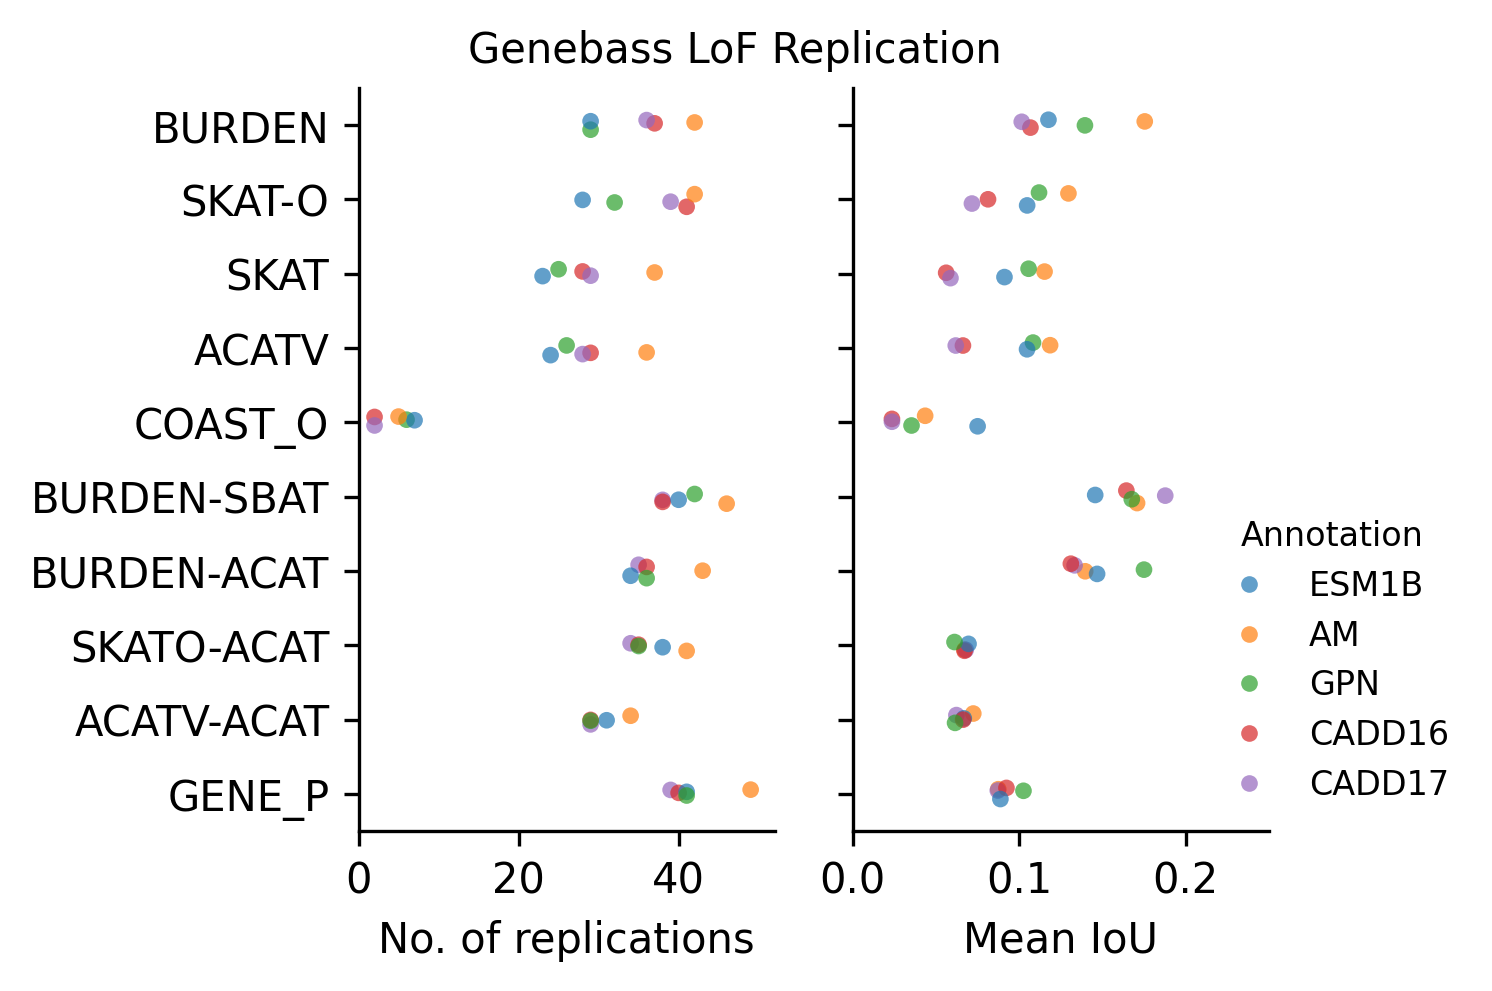

In [62]:
fig, axs = plt.subplots(1, 2, figsize=(5, 3.5))

ax = axs[0]
sns.stripplot(
    data = reps,
    ax = ax,
    x = 'total',
    y = 'test_keys',
    hue = 'anno',
    hue_order = ANNO_ORDER,
    order = TEST_ORDER,
    s = 4,
    alpha = 0.7,
    legend = None,
);
ax.set_xlabel('No. of replications');
ax.set_ylabel(None);
ax.set_xlim(0, 52);


ax = axs[1]
sns.stripplot(
    data = reps,
    ax = ax,
    x = 'iou',
    y = 'test_keys',
    hue = 'anno',
    hue_order = ANNO_ORDER,
    order = TEST_ORDER,
    s = 4,
    alpha = 0.7,
);
ax.set_xlabel('Mean IoU');
ax.set_ylabel(None);
ax.set_xlim(0, 0.25);
ax.set_yticks(ax.get_yticks(), labels=['' for _ in ax.get_yticks()]);
ax.legend(frameon=0, title='Annotation', fontsize=8, title_fontsize=8, bbox_to_anchor=(0.8, 0.0), loc='lower left');

fig.suptitle('Genebass LoF Replication', fontsize=10, y=0.93);
fig.tight_layout();
sns.despine();

fig.savefig('png/supplement/lof_rep.png');

#### ANOVA

In [63]:
for stat in ['total', 'iou']:
    
    for name, query in {
        'all':'mask.notnull()', 
        'primary':'mask == "del"', 
        'secondary':'mask == "bdm"'
    }.items():
        
        aa = sm.stats.anova_lm(
            smf.ols(
                stat + ' ~ anno + test_keys', 
                data = reps.query(query)
            ).fit(), 
            typ=2
        )
        
        display(stat, name, aa)
        
        print(aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True))
        
        if name != 'all':
            for cat in ['anno','test_keys']:
                tk = sm.stats.multicomp.pairwise_tukeyhsd(
                    endog = reps.query(query)[stat], 
                    groups = reps.query(query)[cat],
                    alpha=0.05
                ).summary()
                
                display(cat, tk)
                
                print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

'total'

'all'

,sum_sq,df,F,PR(>F)
anno,415.2,4.0,12.850069,1.349404e-06
test_keys,5182.5,9.0,71.286107,3.039679e-20
Residual,290.8,36.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
anno & 415.200 & 4 & 12.850 & 1.3e-06 \\
test_keys & 5182.500 & 9 & 71.286 & 3.0e-20 \\
Residual & 290.800 & 36 & nan & nan \\
\bottomrule
\end{tabular}



'total'

...

group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-0.006,0.9996,-0.0931,0.081,False
AM,CADD17,-0.0032,1.0,-0.0902,0.0839,False
AM,ESM1B,0.0019,1.0,-0.0851,0.089,False
AM,GPN,0.0037,0.9999,-0.0834,0.0907,False
CADD16,CADD17,0.0029,1.0,-0.0842,0.0899,False
CADD16,ESM1B,0.008,0.9988,-0.0791,0.095,False
CADD16,GPN,0.0097,0.9973,-0.0773,0.0968,False
CADD17,ESM1B,0.0051,0.9998,-0.082,0.0921,False
CADD17,GPN,0.0069,0.9993,-0.0802,0.0939,False
ESM1B,GPN,0.0018,1.0,-0.0853,0.0888,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &       -0.006      &     0.9996     &    -0.0931     &     0.081      &      False       \\
       AM       &      CADD17     &      -0.0032      &      1.0       &    -0.0902     &     0.0839     &      False       \\
       AM       &      ESM1B      &       0.0019      &      1.0       &    -0.0851     &     0.089      &      False       \\
       AM       &       GPN       &       0.0037      &     0.9999     &    -0.0834     &     0.0907     &      False       \\
     CADD16     &      CADD17     &       0.0029      &      1.0       &    -0.0842     &     0.0899     &      False       \\
     CADD16     &      ESM1B      &       0.008       &     0.9988     &    -0.0791     &     0.095      &      False       \\
     CADD16     &       GPN       &       0.0097     

'test_keys'

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV-ACAT,BURDEN-ACAT,0.0793,0.0,0.0533,0.1054,True
ACATV-ACAT,BURDEN-SBAT,0.1014,0.0,0.0754,0.1275,True
ACATV-ACAT,COAST_O,-0.0256,0.0552,-0.0517,0.0004,False
ACATV-ACAT,GENE_P,0.0258,0.0531,-0.0002,0.0518,False
ACATV-ACAT,SKATO-ACAT,0.0008,1.0,-0.0253,0.0268,False
BURDEN-ACAT,BURDEN-SBAT,0.0221,0.1297,-0.0039,0.0481,False
BURDEN-ACAT,COAST_O,-0.105,0.0,-0.131,-0.0789,True
BURDEN-ACAT,GENE_P,-0.0535,0.0,-0.0796,-0.0275,True
BURDEN-ACAT,SKATO-ACAT,-0.0786,0.0,-0.1046,-0.0525,True
BURDEN-SBAT,COAST_O,-0.1271,0.0,-0.1531,-0.101,True


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
   ACATV-ACAT   &   BURDEN-ACAT   &       0.0793      &      0.0       &     0.0533     &     0.1054     &       True       \\
   ACATV-ACAT   &   BURDEN-SBAT   &       0.1014      &      0.0       &     0.0754     &     0.1275     &       True       \\
   ACATV-ACAT   &     COAST\_O    &      -0.0256      &     0.0552     &    -0.0517     &     0.0004     &      False       \\
   ACATV-ACAT   &     GENE\_P     &       0.0258      &     0.0531     &    -0.0002     &     0.0518     &      False       \\
   ACATV-ACAT   &    SKATO-ACAT   &       0.0008      &      1.0       &    -0.0253     &     0.0268     &      False       \\
  BURDEN-ACAT   &   BURDEN-SBAT   &       0.0221      &     0.1297     &    -0.0039     &     0.0481     &      False       \\
  BURDEN-ACAT   &     COAST\_O    &       -0.105     

#### ANOVA + Robust

In [64]:
for stat in ['total', 'iou']:
    
    for name, query in {
        'all':'mask.notnull()', 
        'primary':'mask == "del"', 
        'secondary':'mask == "bdm"'
    }.items():
        
        aa = sm.stats.anova_lm(
            smf.ols(
                stat + ' ~ anno + test_keys', 
                data = reps.query(query)
            ).fit(), 
            typ=2,
            robust = 'hc3',
        )
        
        display(stat, name, aa)
        
        print(aa.style.format(
            formatter={
                "sum_sq": "{:.3f}",
                "F": "{:.3f}",
                "PR(>F)": "{:.1e}",
                "df": "{:.0f}",
            }
        ).to_latex(siunitx=True, hrules=True))
        
        if name != 'all':
            for cat in ['anno','test_keys']:
                tk = sm.stats.multicomp.pairwise_tukeyhsd(
                    endog = reps.query(query)[stat], 
                    groups = reps.query(query)[cat],
                    alpha=0.05,
                ).summary()
                
                display(cat, tk)
                
                print(tk.as_latex_tabular(fmt_dict={"p-adj":'%.2e'}, siunitx=True, hrules=True))

'total'

'all'

,sum_sq,df,F,PR(>F)
anno,333.923206,4.0,10.334625,1.118143e-05
test_keys,3047.831103,9.0,41.923399,1.971086e-16
Residual,290.800000,36.0,NaN,NaN


\begin{tabular}{lSSSS}
\toprule
{} & {sum_sq} & {df} & {F} & {PR(>F)} \\
\midrule
anno & 333.923 & 4 & 10.335 & 1.1e-05 \\
test_keys & 3047.831 & 9 & 41.923 & 2.0e-16 \\
Residual & 290.800 & 36 & nan & nan \\
\bottomrule
\end{tabular}



'total'

...

group1,group2,meandiff,p-adj,lower,upper,reject
AM,CADD16,-0.006,0.9996,-0.0931,0.081,False
AM,CADD17,-0.0032,1.0,-0.0902,0.0839,False
AM,ESM1B,0.0019,1.0,-0.0851,0.089,False
AM,GPN,0.0037,0.9999,-0.0834,0.0907,False
CADD16,CADD17,0.0029,1.0,-0.0842,0.0899,False
CADD16,ESM1B,0.008,0.9988,-0.0791,0.095,False
CADD16,GPN,0.0097,0.9973,-0.0773,0.0968,False
CADD17,ESM1B,0.0051,0.9998,-0.082,0.0921,False
CADD17,GPN,0.0069,0.9993,-0.0802,0.0939,False
ESM1B,GPN,0.0018,1.0,-0.0853,0.0888,False


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
       AM       &      CADD16     &       -0.006      &     0.9996     &    -0.0931     &     0.081      &      False       \\
       AM       &      CADD17     &      -0.0032      &      1.0       &    -0.0902     &     0.0839     &      False       \\
       AM       &      ESM1B      &       0.0019      &      1.0       &    -0.0851     &     0.089      &      False       \\
       AM       &       GPN       &       0.0037      &     0.9999     &    -0.0834     &     0.0907     &      False       \\
     CADD16     &      CADD17     &       0.0029      &      1.0       &    -0.0842     &     0.0899     &      False       \\
     CADD16     &      ESM1B      &       0.008       &     0.9988     &    -0.0791     &     0.095      &      False       \\
     CADD16     &       GPN       &       0.0097     

'test_keys'

group1,group2,meandiff,p-adj,lower,upper,reject
ACATV-ACAT,BURDEN-ACAT,0.0793,0.0,0.0533,0.1054,True
ACATV-ACAT,BURDEN-SBAT,0.1014,0.0,0.0754,0.1275,True
ACATV-ACAT,COAST_O,-0.0256,0.0552,-0.0517,0.0004,False
ACATV-ACAT,GENE_P,0.0258,0.0531,-0.0002,0.0518,False
ACATV-ACAT,SKATO-ACAT,0.0008,1.0,-0.0253,0.0268,False
BURDEN-ACAT,BURDEN-SBAT,0.0221,0.1297,-0.0039,0.0481,False
BURDEN-ACAT,COAST_O,-0.105,0.0,-0.131,-0.0789,True
BURDEN-ACAT,GENE_P,-0.0535,0.0,-0.0796,-0.0275,True
BURDEN-ACAT,SKATO-ACAT,-0.0786,0.0,-0.1046,-0.0525,True
BURDEN-SBAT,COAST_O,-0.1271,0.0,-0.1531,-0.101,True


\begin{center}
\begin{tabular}{ccccccc}
\toprule
\textbf{group1} & \textbf{group2} & \textbf{meandiff} & \textbf{p-adj} & \textbf{lower} & \textbf{upper} & \textbf{reject}  \\
\midrule
   ACATV-ACAT   &   BURDEN-ACAT   &       0.0793      &      0.0       &     0.0533     &     0.1054     &       True       \\
   ACATV-ACAT   &   BURDEN-SBAT   &       0.1014      &      0.0       &     0.0754     &     0.1275     &       True       \\
   ACATV-ACAT   &     COAST\_O    &      -0.0256      &     0.0552     &    -0.0517     &     0.0004     &      False       \\
   ACATV-ACAT   &     GENE\_P     &       0.0258      &     0.0531     &    -0.0002     &     0.0518     &      False       \\
   ACATV-ACAT   &    SKATO-ACAT   &       0.0008      &      1.0       &    -0.0253     &     0.0268     &      False       \\
  BURDEN-ACAT   &   BURDEN-SBAT   &       0.0221      &     0.1297     &    -0.0039     &     0.0481     &      False       \\
  BURDEN-ACAT   &     COAST\_O    &       -0.105     

### Figure 4

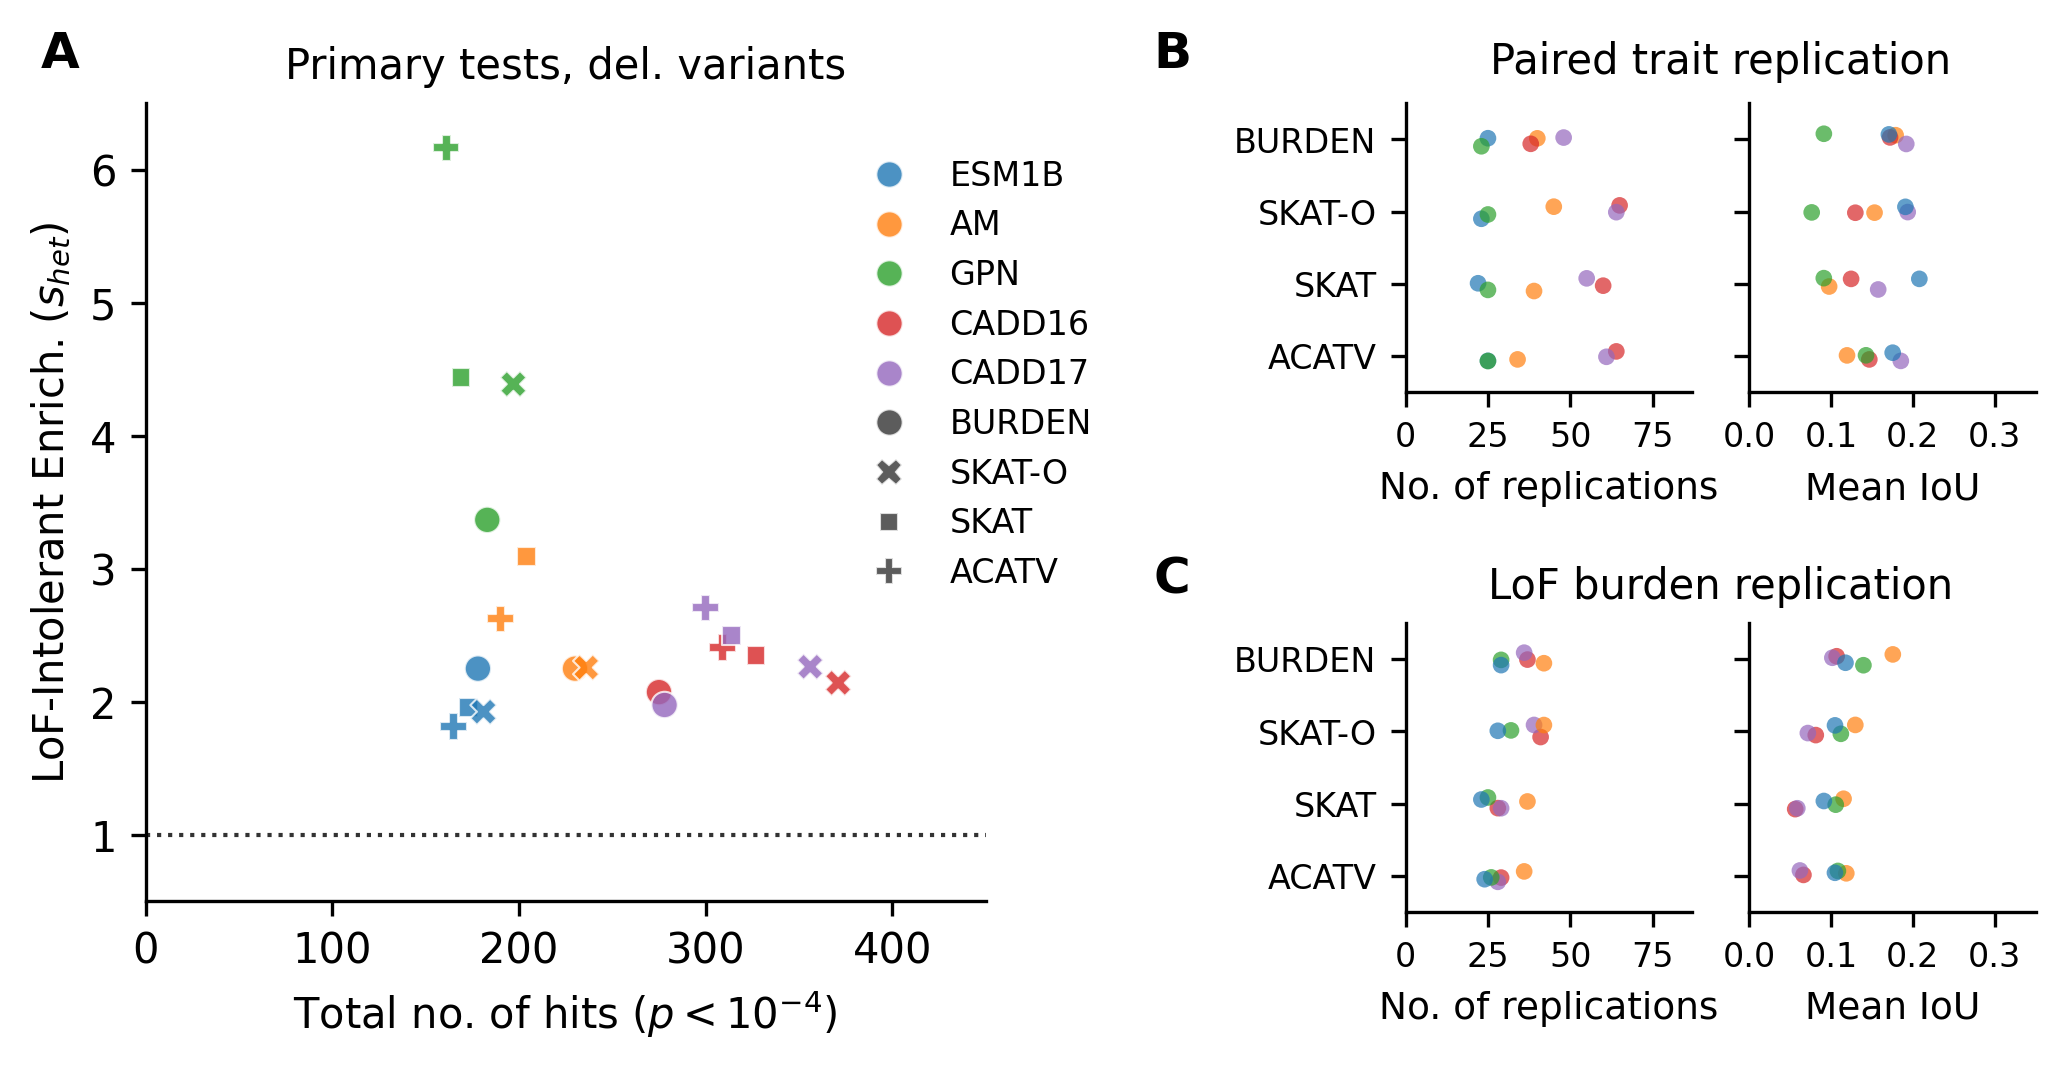

In [65]:
fig = plt.figure(figsize=(7, 3.5));

grid_l = gs.GridSpec(1, 1, figure=fig, left=0.0, right=0.4, bottom=0.12, top=0.88)
grid_r = gs.GridSpec(2, 2, figure=fig, left=0.6, hspace=0.8)

ax = fig.add_subplot(grid_l[0,0])

sns.scatterplot(
    ax = ax,
    data = enrich.query('(pop_sample == "unrelated") & (mask == "del")'),
    x = 'No. of gene-trait pairs (p < 0.0001)',
    y = 'LoF-Intolerant Enrichment ({})'.format(r'$s_{het}$'),
    hue = 'anno', 
    hue_order = ANNO_ORDER,
    style = 'test_keys',
    style_order = TEST_ORDER1,
    alpha = 0.8, 
    legend = True,
    s = 40,
);

ax.set_xlabel('Total no. of hits ({})'.format(r'$p < 10^{-4}$'));
ax.set_ylabel(ax.get_ylabel().replace('Enrichment', 'Enrich.'));
ax.set_ylim(0.5, 6.5);
ax.set_xlim(0, 450); ax.set_xticks([0, 100, 200, 300, 400]);
ax.axhline(1, linestyle='dotted', color='k', linewidth=1, alpha=0.8);
ax.set_title('Primary tests, del. variants', fontsize=10);
    
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[1:6] + handles[7:], labels=labels[1:6] + labels[7:], frameon=0)
sns.move_legend(
    ax, 
    loc = 'center left', 
    bbox_to_anchor = (0.81, 0.66), 
    fontsize = 8, 
    frameon = 0,
);

for i,df in enumerate([traits, reps]):
    for j,stat in enumerate(['total','iou']):
        ax = fig.add_subplot(grid_r[i, j])
    
        sns.stripplot(
            data = df.query('mask == "del"'),
            ax = ax,
            x = stat,
            y = 'test_keys',
            hue = 'anno',
            order = TEST_ORDER1,
            hue_order = ANNO_ORDER,
            s = 4,
            alpha = 0.7,
            legend = None,#(stat == 'iou'),
        );
        ax.set_ylabel(None);
        ax.tick_params(axis='both', which='major', labelsize=8)
        if stat == 'total':
            ax.set_xlabel('No. of replications', fontsize=9);# if i == 1 else None);
            ax.set_xlim(0, 87);
            ax.set_xticks(np.arange(0, 87, 25), labels=['{:.0f}'.format(l) if i >= 0 else '' for l in np.arange(0, 87, 25)]); 
        elif stat == 'iou':
            ax.set_xlabel('Mean IoU', fontsize=9);# if i == 1 else None);
            ax.set_xlim(0, 0.35);
            ax.set_xticks(np.arange(0, 0.35, 0.1), labels=['{:.1f}'.format(l) if i >= 0 else '' for l in np.arange(0, 0.35, 0.1)]);
            ax.set_yticks(ax.get_yticks(), labels=['' for _ in ax.get_yticks()]);
            if False:
                ax.legend(
                    frameon=0, 
                    title='Annotation', 
                    fontsize=8, 
                    title_fontsize=8, 
                    bbox_to_anchor=(0.65, 0.5), 
                    loc='center left'
                );

fig.text(0.75, 0.9, 'Paired trait replication', ha='center', va='bottom', fontsize=10);
fig.text(0.75, 0.4, 'LoF burden replication', ha='center', va='bottom', fontsize=10);

fig.text(-0.05, 0.95, 'A', ha='left', va='top', fontsize=12, fontweight='bold')
fig.text(0.48, 0.95, 'B', ha='left', va='top', fontsize=12, fontweight='bold')
fig.text(0.48, 0.45, 'C', ha='left', va='top', fontsize=12, fontweight='bold')

sns.despine();
fig.savefig('png/Fig4.png', bbox_inches='tight');

### Figure 5

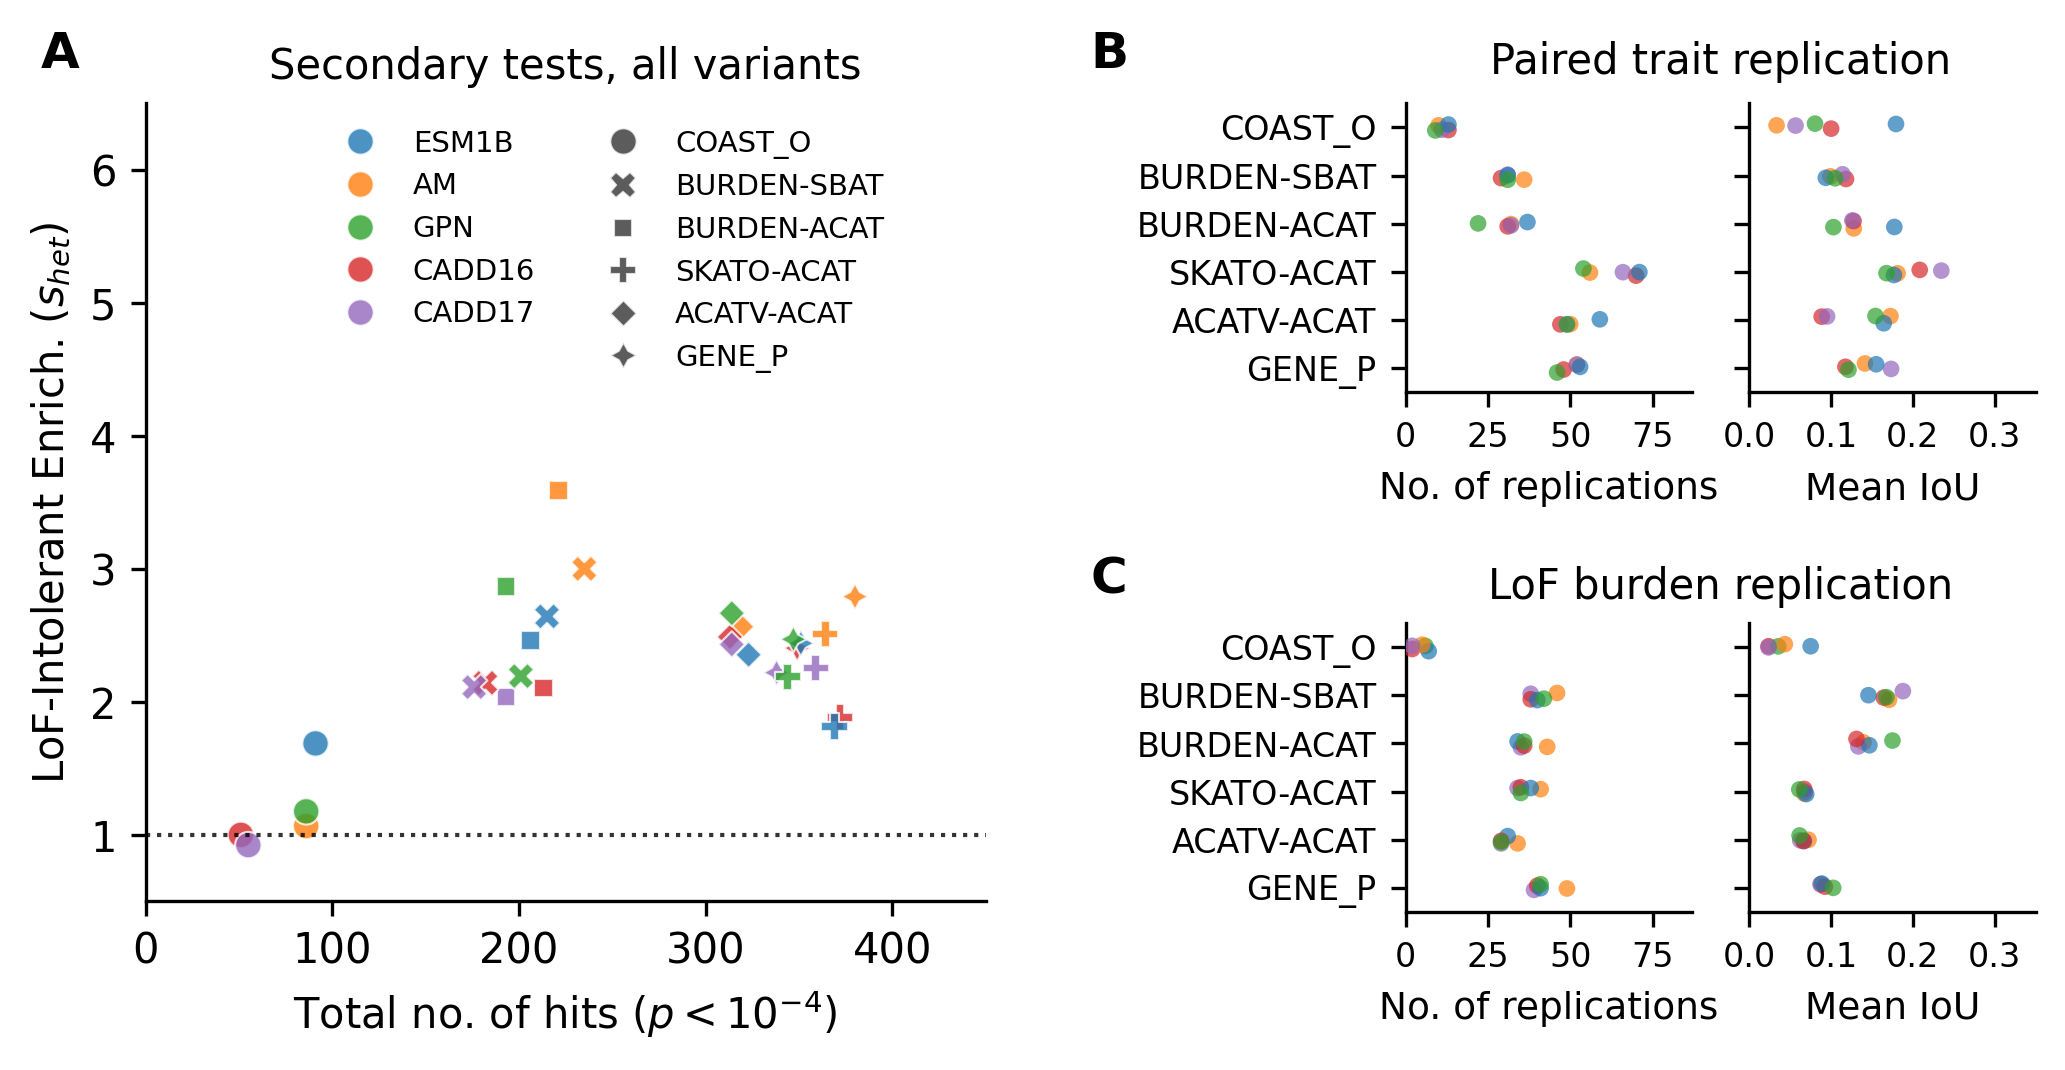

In [66]:
fig = plt.figure(figsize=(7, 3.5));

grid_l = gs.GridSpec(1, 1, figure=fig, left=0.0, right=0.4, bottom=0.12, top=0.88)
grid_r = gs.GridSpec(2, 2, figure=fig, left=0.6, hspace=0.8)

ax = fig.add_subplot(grid_l[0,0])

sns.scatterplot(
    ax = ax,
    data = enrich.query('(pop_sample == "unrelated") & (mask == "bdm")'),
    x = 'No. of gene-trait pairs (p < 0.0001)',
    y = 'LoF-Intolerant Enrichment ({})'.format(r'$s_{het}$'),
    hue = 'anno', 
    hue_order = ANNO_ORDER,
    style = 'test_keys',
    style_order = TEST_ORDER2,
    alpha = 0.8, 
    legend = True,
    s = 40,
);

ax.set_xlabel('Total no. of hits ({})'.format(r'$p < 10^{-4}$'));
ax.set_ylabel(ax.get_ylabel().replace('Enrichment', 'Enrich.'));
ax.set_ylim(0.5, 6.5);
ax.set_xlim(0, 450); ax.set_xticks([0, 100, 200, 300, 400]);
ax.axhline(1, linestyle='dotted', color='k', linewidth=1, alpha=0.8);
ax.set_title('Secondary tests, all variants', fontsize=10);
    
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[1:7] + handles[7:], labels=labels[1:6] + [''] + labels[7:])
sns.move_legend(
    ax, 
    loc = 'upper center', 
    bbox_to_anchor = (0.55, 1.0), 
    fontsize = 7, 
    frameon = 0,
    ncol = 2,
);

for i,df in enumerate([traits, reps]):
    for j,stat in enumerate(['total','iou']):
        ax = fig.add_subplot(grid_r[i, j])
    
        sns.stripplot(
            data = df.query('mask == "bdm"'),
            ax = ax,
            x = stat,
            y = 'test_keys',
            hue = 'anno',
            order = TEST_ORDER2,
            hue_order = ANNO_ORDER,
            s = 4,
            alpha = 0.7,
            legend = None,
        );
        ax.set_ylabel(None);
        ax.tick_params(axis='both', which='major', labelsize=8)
        if stat == 'total':
            ax.set_xlabel('No. of replications', fontsize=9);
            ax.set_xlim(0, 87);
            ax.set_xticks(np.arange(0, 87, 25), labels=['{:.0f}'.format(l) if i >= 0 else '' for l in np.arange(0, 87, 25)]); 
        elif stat == 'iou':
            ax.set_xlabel('Mean IoU', fontsize=9);
            ax.set_xlim(0, 0.35);
            ax.set_xticks(np.arange(0, 0.35, 0.1), labels=['{:.1f}'.format(l) if i >= 0 else '' for l in np.arange(0, 0.35, 0.1)]);
            ax.set_yticks(ax.get_yticks(), labels=['' for _ in ax.get_yticks()]);
            if False:
                ax.legend(
                    frameon=0, 
                    title='Annotation', 
                    fontsize=8, 
                    title_fontsize=8, 
                    bbox_to_anchor=(0.65, 0.5), 
                    loc='center left'
                );

fig.text(0.75, 0.9, 'Paired trait replication', ha='center', va='bottom', fontsize=10);
fig.text(0.75, 0.4, 'LoF burden replication', ha='center', va='bottom', fontsize=10);

fig.text(-0.05, 0.95, 'A', ha='left', va='top', fontsize=12, fontweight='bold')
fig.text(0.45, 0.95, 'B', ha='left', va='top', fontsize=12, fontweight='bold')
fig.text(0.45, 0.45, 'C', ha='left', va='top', fontsize=12, fontweight='bold')

sns.despine();
fig.savefig('png/Fig5.png', bbox_inches='tight');

# Paired trait replication histogram

In [67]:
q = sumstats.query(
    '(mask == "del" | mask == "bdm") & LOG10P >= 4 & pop_sample == "unrelated"'
).groupby(
    ['test_keys','anno','mask','pheno']
)['gene_id'].agg(set).reset_index()

q

,test_keys,anno,mask,pheno,gene_id
0,ACATV,AM,del,bmi,"{ENSG00000182050, ENSG00000129968, ENSG0000010..."
1,ACATV,AM,del,ch-L,{ENSG00000165072}
2,ACATV,AM,del,ch-R,"{ENSG00000146966, ENSG00000173480}"
3,ACATV,AM,del,crf-L,"{ENSG00000146966, ENSG00000165072, ENSG0000017..."
4,ACATV,AM,del,crf-R,"{ENSG00000146966, ENSG00000100599, ENSG0000002..."
...,...,...,...,...,...
683,SKATO-ACAT,GPN,bdm,iop-G-L,"{ENSG00000165072, ENSG00000119041, ENSG0000011..."
684,SKATO-ACAT,GPN,bdm,iop-G-R,"{ENSG00000236699, ENSG00000131844, ENSG0000012..."
685,SKATO-ACAT,GPN,bdm,iop-L,"{ENSG00000119041, ENSG00000171819}"
686,SKATO-ACAT,GPN,bdm,iop-R,"{ENSG00000131844, ENSG00000172006, ENSG0000017..."


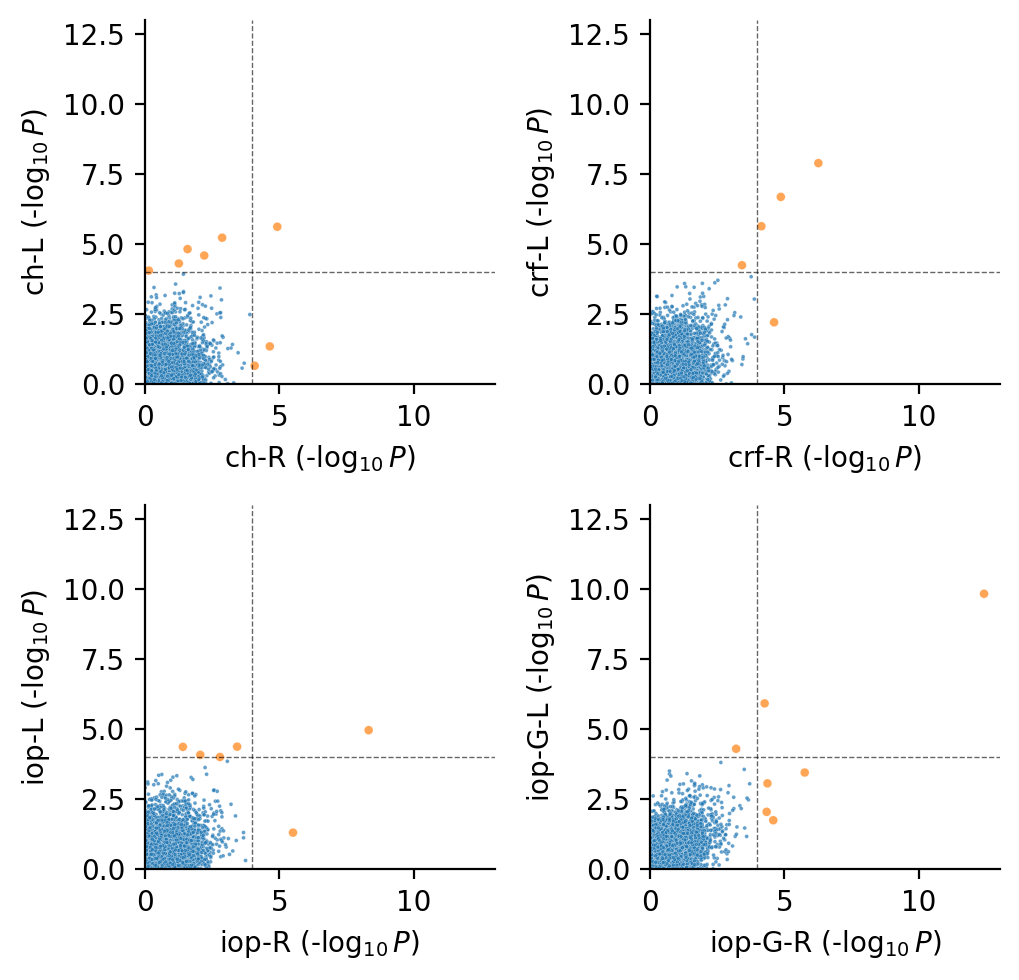

In [68]:
fig, axs = plt.subplots(2, 2, figsize=(5.2, 5), dpi=200)

for ax,pair in zip(axs.flat, [k for k in pheno_pairs.keys() if '-R' in k[0]]):
    rl = sumstats.query(
        'mask == "del" & pop_sample == "unrelated" & test_keys == "BURDEN" & anno == "AM" & pheno.isin(@pair) & gene_id.str.contains("ENSG")'
    ).pivot(
        index = 'gene_id',
        columns = 'pheno', 
        values = 'LOG10P',
    )
    rl['sig'] = (rl > 4).any(axis=1)
    
    sns.scatterplot(
        data = rl,
        ax = ax,
        x = pair[0],
        y = pair[1],
        size = 'sig',
        hue = 'sig',
        sizes = (10, 2), 
        alpha = 0.7,
        legend = 0,
    )
    
    ax.set_xlabel('{0} (-{1})'.format(pair[0], r'$\log_{10}P$'));
    ax.set_ylabel('{0} (-{1})'.format(pair[1], r'$\log_{10}P$'));
    ax.set_xlim(0, 13);
    ax.set_ylim(0, 13);
    ax.axhline(4, linewidth=0.5, linestyle='dashed', alpha=0.6, color='k');
    ax.axvline(4, linewidth=0.5, linestyle='dashed', alpha=0.6, color='k');
    
sns.despine();
fig.tight_layout();

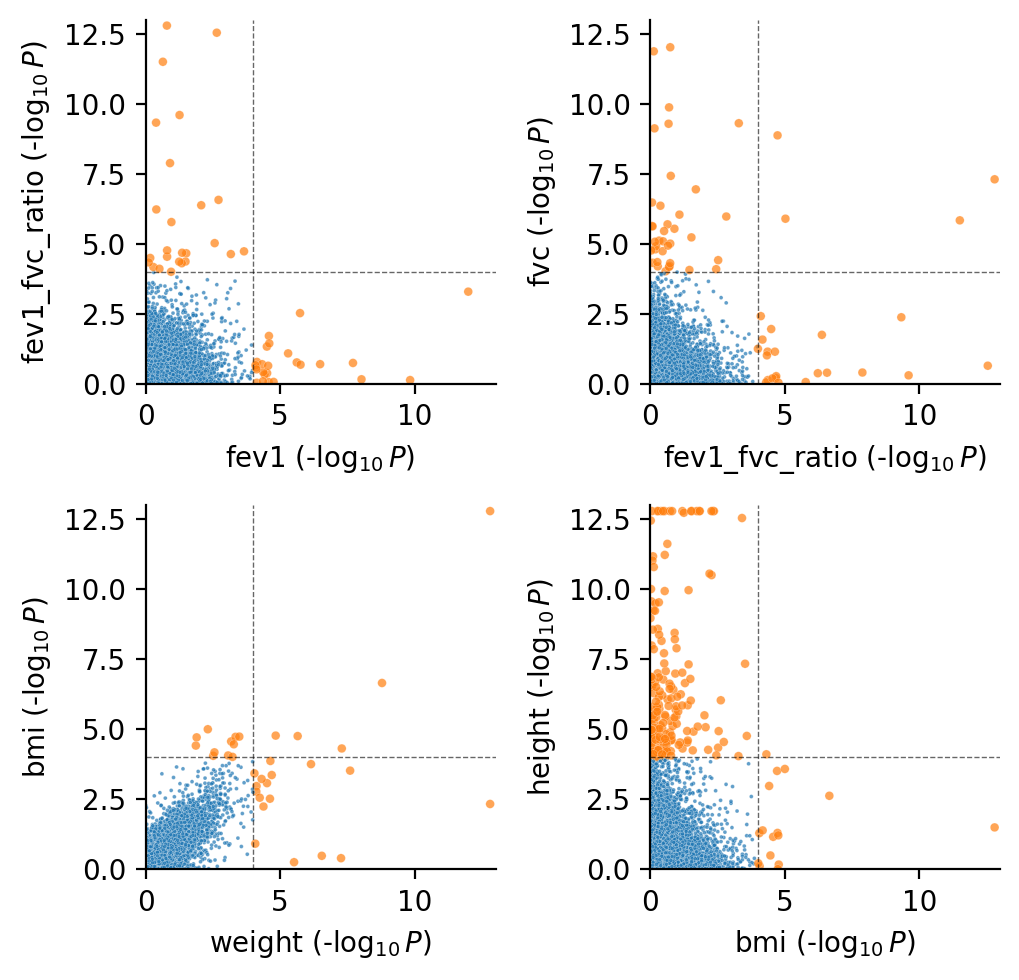

In [69]:
fig, axs = plt.subplots(2, 2, figsize=(5.2, 5), dpi=200)

for ax,pair in zip(axs.flat, [k for k in pheno_pairs.keys() if '-R' not in k[0]]):
    rl = sumstats.query(
        'mask == "del" & pop_sample == "unrelated" & test_keys == "SKAT-O" & anno == "CADD16" & pheno.isin(@pair) & gene_id.str.contains("ENSG")'
    ).pivot(
        index = 'gene_id',
        columns = 'pheno', 
        values = 'LOG10P',
    )
    rl['sig'] = (rl > 4).any(axis=1)
    
    sns.scatterplot(
        data = rl.clip(upper = 12.8),
        ax = ax,
        x = pair[0],
        y = pair[1],
        size = 'sig',
        hue = 'sig',
        sizes = (10, 2), 
        alpha = 0.7,
        legend = 0,
    )
    
    ax.set_xlabel('{0} (-{1})'.format(pair[0], r'$\log_{10}P$'));
    ax.set_ylabel('{0} (-{1})'.format(pair[1], r'$\log_{10}P$'));
    ax.set_xlim(0, 13);
    ax.set_ylim(0, 13);
    ax.axhline(4, linewidth=0.5, linestyle='dashed', alpha=0.6, color='k');
    ax.axvline(4, linewidth=0.5, linestyle='dashed', alpha=0.6, color='k');
    
sns.despine();
fig.tight_layout();

In [70]:
print('completed in {}s'.format(time.time() - t0));

completed in 1094.9325940608978s
